<div style="padding:44px 48px;border-radius:26px;background:radial-gradient(circle at 78% 18%,#5e4d91 0,#202a58 35%,#080d20 78%);border:1px solid #8792c8;box-shadow:0 18px 58px rgba(3,7,23,.42)">
  <h1 style="margin:0;color:#f7f1dc;font-size:46px;letter-spacing:.02em;font-weight:760">The Moon Counts Melons</h1>
</div>

In [1]:
from pathlib import Path
import hashlib, importlib.metadata, tarfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
from IPython.display import HTML, display

NAVY="#080d20"; PANEL="#111936"; INK="#f7f1dc"; MUTED="#b5bfdf"
MOON="#f0c86b"; RAIN="#68d6e7"; VIOLET="#b99aea"; CLAY="#df806c"; GREEN="#78c98a"
plt.rcParams.update({
    "figure.facecolor":NAVY,"axes.facecolor":PANEL,"savefig.facecolor":NAVY,
    "text.color":INK,"axes.labelcolor":MUTED,"axes.edgecolor":"#59668f",
    "xtick.color":MUTED,"ytick.color":MUTED,"axes.titleweight":"bold",
    "axes.titlesize":14,"font.size":11,"grid.color":"#3d496e","grid.alpha":.42,
})
print("kaggle-environments", importlib.metadata.version("kaggle-environments"))

kaggle-environments 1.29.3


## A strong agent can still lose to its shadow

The terminal repair in the previous version was already perfect against the refreshed public families, yet its symmetric matchups remained seat-sensitive. That is a distinct failure mode: two near-identical farms release the same premium inventory into one shared market, so a narrow execution-order edge can decide the game.

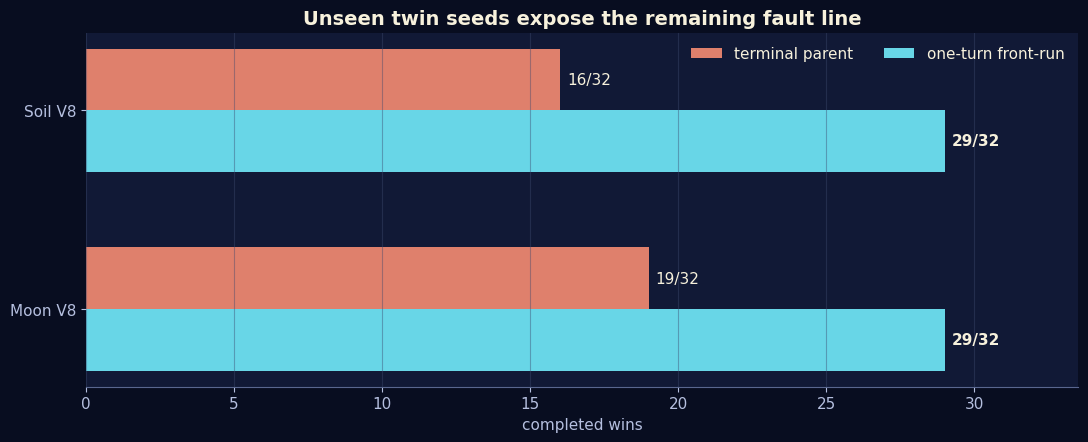

In [2]:
twins=pd.DataFrame({
    "opponent":["Moon V8","Soil V8"],
    "parent":[19,16],"moon_v9":[29,29],"games":[32,32],
})
y=np.arange(len(twins)); h=.31
fig,ax=plt.subplots(figsize=(12.8,4.6))
p=ax.barh(y+h/2,twins.parent,height=h,color=CLAY,label="terminal parent")
c=ax.barh(y-h/2,twins.moon_v9,height=h,color=RAIN,label="one-turn front-run")
ax.bar_label(p,labels=[f"{x}/32" for x in twins.parent],padding=5,color=INK)
ax.bar_label(c,labels=[f"{x}/32" for x in twins.moon_v9],padding=5,color=INK,weight="bold")
ax.set_yticks(y,twins.opponent); ax.set_xlim(0,33.5)
ax.set(title="Unseen twin seeds expose the remaining fault line",xlabel="completed wins")
ax.legend(frameon=False,ncol=2); ax.grid(axis="x"); ax.spines[["top","right","left"]].set_visible(False)
plt.show()

## The signal is public and allowed to disappear

At sparse checkpoints, the agent compares only public farm geometry, workers, unlocked land, and crop/animal counts. Close farms raise clone confidence; visible divergence erases it quickly. The worst retained twin seed below is useful precisely because the signal vanishes: the rule stops intervening instead of forcing an anti-mirror story onto an ordinary opponent.

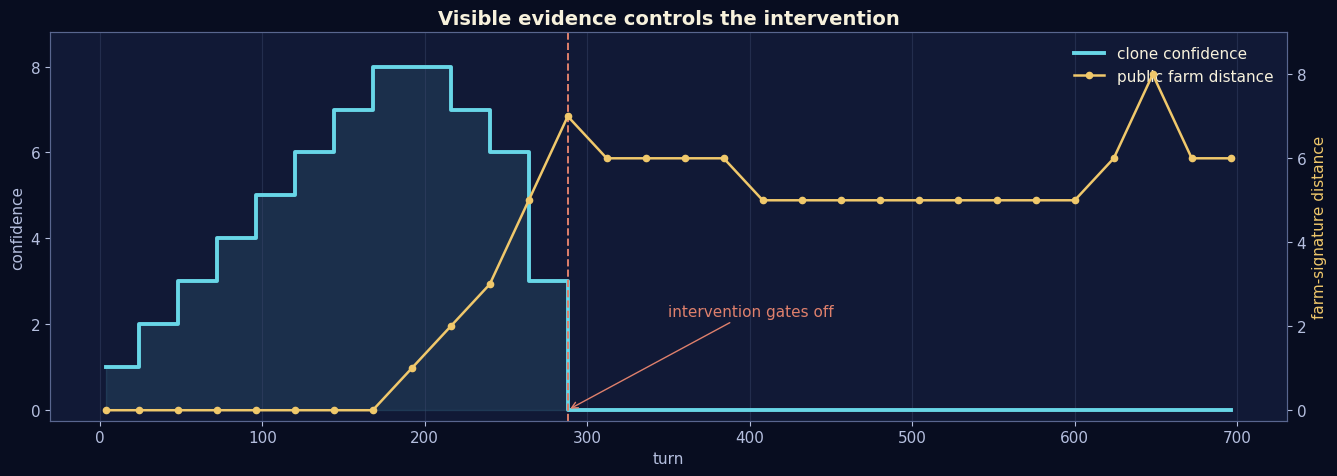

In [3]:
checkpoints=np.array([4,24,48,72,96,120,144,168,192,216,240,264,288,312,336,360,384,408,432,456,480,504,528,552,576,600,624,648,672,696])
distance=np.array([0,0,0,0,0,0,0,0,1,2,3,5,7,6,6,6,6,5,5,5,5,5,5,5,5,5,6,8,6,6])
confidence=np.array([1,2,3,4,5,6,7,8,8,7,6,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0])
fig,ax=plt.subplots(figsize=(13.5,4.9)); twin=ax.twinx()
confidence_line,=ax.step(checkpoints,confidence,where="post",lw=2.8,color=RAIN,label="clone confidence")
ax.fill_between(checkpoints,0,confidence,step="post",color=RAIN,alpha=.12)
distance_line,=twin.plot(checkpoints,distance,"o-",ms=4.5,lw=1.8,color=MOON,label="public farm distance")
ax.axvline(288,color=CLAY,ls="--",lw=1.4)
ax.annotate("intervention gates off",xy=(288,0),xytext=(350,2.2),color=CLAY,
            arrowprops={"arrowstyle":"->","color":CLAY})
ax.set(title="Visible evidence controls the intervention",xlabel="turn",ylabel="confidence",ylim=(-.25,8.8))
twin.set_ylabel("farm-signature distance",color=MOON); twin.set_ylim(-.25,9)
ax.legend([confidence_line,distance_line],["clone confidence","public farm distance"],frameon=False,loc="upper right")
ax.grid(axis="x"); plt.tight_layout(); plt.show()

## One turn is the ridge

Looking farther ahead sounds stronger, but the data says otherwise. Two turns raised the mirror margin without adding a win and tripled the collateral against the closest non-clone. Three turns lost a twin game. The released rule therefore looks ahead exactly once.

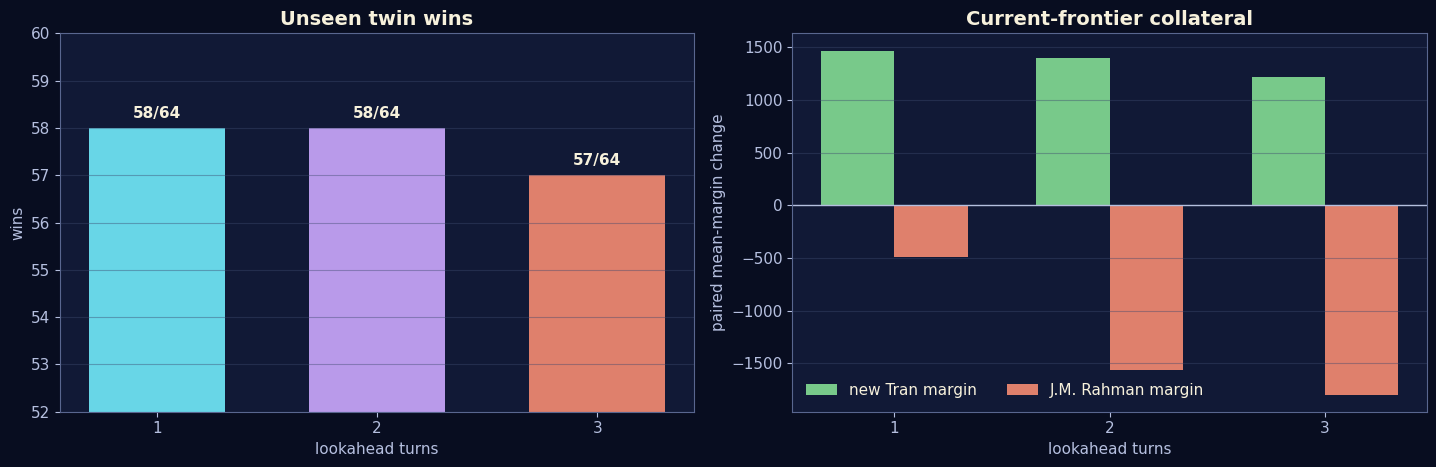

In [4]:
horizon=pd.DataFrame({
    "turns":[1,2,3],"twin_wins":[58,58,57],
    "jmr_delta":[-489,-1563,-1798],"tran_delta":[1471,1398,1223],
})
fig,(ax0,ax1)=plt.subplots(1,2,figsize=(14.5,4.8))
bars=ax0.bar(horizon.turns,horizon.twin_wins,color=[RAIN,VIOLET,CLAY],width=.62)
ax0.bar_label(bars,labels=[f"{x}/64" for x in horizon.twin_wins],padding=5,color=INK,weight="bold")
ax0.set(title="Unseen twin wins",xlabel="lookahead turns",ylabel="wins",ylim=(52,60)); ax0.set_xticks(horizon.turns); ax0.grid(axis="y")
x=np.arange(3); w=.34
ax1.bar(x-w/2,horizon.tran_delta,width=w,color=GREEN,label="new Tran margin")
ax1.bar(x+w/2,horizon.jmr_delta,width=w,color=CLAY,label="J.M. Rahman margin")
ax1.axhline(0,color=MUTED,lw=1); ax1.set_xticks(x,horizon.turns)
ax1.set(title="Current-frontier collateral",xlabel="lookahead turns",ylabel="paired mean-margin change")
ax1.legend(frameon=False,ncol=2); ax1.grid(axis="y")
plt.tight_layout(); plt.show()

## What changed in the paired games

Every candidate game used the same seed, seat, and opponent as its parent. Sixty of sixty-four twin margins improved, four were unchanged, and none regressed. Twenty-three parent losses crossed zero. The remaining six losses are retained rather than hidden; their farms had already diverged or produced premium inventory only on the sale turn.

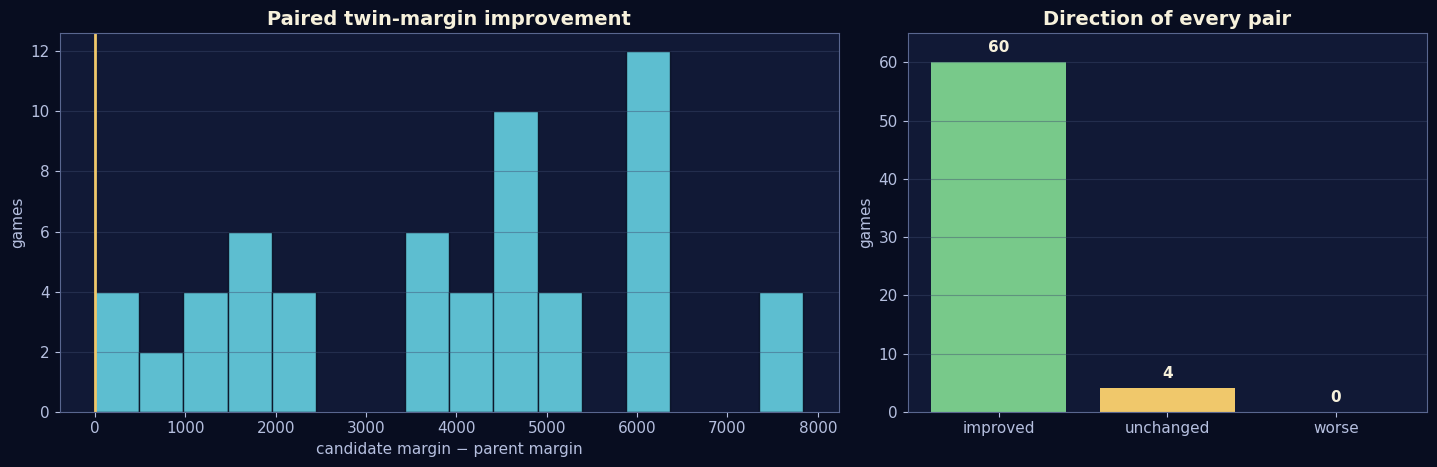

In [5]:
TWIN_DELTAS = np.array([4000.0, 3763.0, 4570.0, 4391.0, 7822.0, 7822.0, 1576.0, 1576.0, 1009.0, 279.0, 3815.0, 3763.0, 6027.0, 6027.0, 2098.0, 1854.0, 5994.0, 5994.0, 2130.0, 630.0, 4594.0, 4594.0, 4641.0, 4609.0, 0.0, 0.0, 1065.0, 467.0, 5064.0, 5086.0, 5913.0, 5913.0, 3938.0, 3702.0, 4570.0, 4391.0, 7838.0, 7838.0, 1576.0, 1576.0, 1009.0, 279.0, 3813.0, 3767.0, 6027.0, 6027.0, 2098.0, 1854.0, 5994.0, 5994.0, 2130.0, 632.0, 4594.0, 4594.0, 4643.0, 4608.0, 0.0, 0.0, 1065.0, 467.0, 5064.0, 5086.0, 5913.0, 5913.0], dtype=float)

fig,(ax0,ax1)=plt.subplots(1,2,figsize=(14.5,4.8),gridspec_kw={"width_ratios":[1.2,.8]})
bins=np.linspace(0,max(TWIN_DELTAS.max(),1),17)
ax0.hist(TWIN_DELTAS[TWIN_DELTAS>0],bins=bins,color=RAIN,alpha=.88,edgecolor=NAVY)
ax0.axvline(0,color=MOON,lw=2); ax0.set(title="Paired twin-margin improvement",xlabel="candidate margin − parent margin",ylabel="games")
ax0.grid(axis="y")
counts=pd.Series({"improved":int((TWIN_DELTAS>0).sum()),"unchanged":int((TWIN_DELTAS==0).sum()),"worse":int((TWIN_DELTAS<0).sum())})
bars=ax1.bar(counts.index,counts.values,color=[GREEN,MOON,CLAY])
ax1.bar_label(bars,padding=5,color=INK,weight="bold"); ax1.set(title="Direction of every pair",ylabel="games",ylim=(0,65)); ax1.grid(axis="y")
plt.tight_layout(); plt.show()
display(HTML("<div style='padding:16px 20px;border:1px solid #596896;border-radius:15px;background:linear-gradient(135deg,#111936,#252650);color:#f7f1dc'><b style='color:#68d6e7'>23 losses became wins</b><br>with zero paired twin-margin regressions</div>"))

## Independent gates before the freeze

Mirror skill is not permission to damage the base policy. Current leaders, public notebook agents, diverse strategy families, historical seeds, and a later blind frontier refresh remain separate gates. The weakest completed margin in each non-twin gate stayed positive.

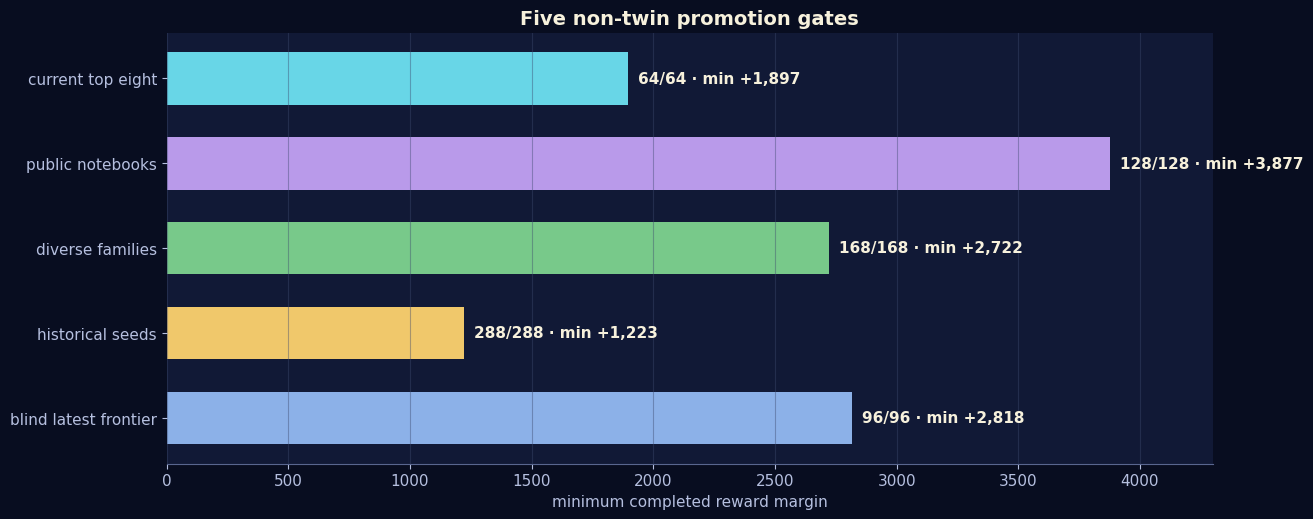

In [6]:
gates=pd.DataFrame({
    "gate":["current top eight","public notebooks","diverse families","historical seeds","blind latest frontier"],
    "wins":[64,128,168,288,96],"games":[64,128,168,288,96],
    "min_margin":[1897,3877,2722,1223,2818],
})
fig,ax=plt.subplots(figsize=(13.5,5.6))
bars=ax.barh(gates.gate,gates.min_margin,color=[RAIN,VIOLET,GREEN,MOON,"#8cb1e8"],height=.62)
ax.bar_label(bars,labels=[f"{w}/{g} · min +{m:,}" for w,g,m in zip(gates.wins,gates.games,gates.min_margin)],padding=7,color=INK,weight="bold")
ax.set(title="Five non-twin promotion gates",xlabel="minimum completed reward margin",xlim=(0,4300)); ax.invert_yaxis()
ax.grid(axis="x"); ax.spines[["top","right","left"]].set_visible(False); plt.show()

## The live frontier after the rule was fixed

A read-only refresh found Ueddy at rank one and forty-five new public replays. The candidate had not seen the six newest tapes when it was frozen. It won all ninety-six blind and exact-seed cross games; Lucien remained the narrow, informative matchup.

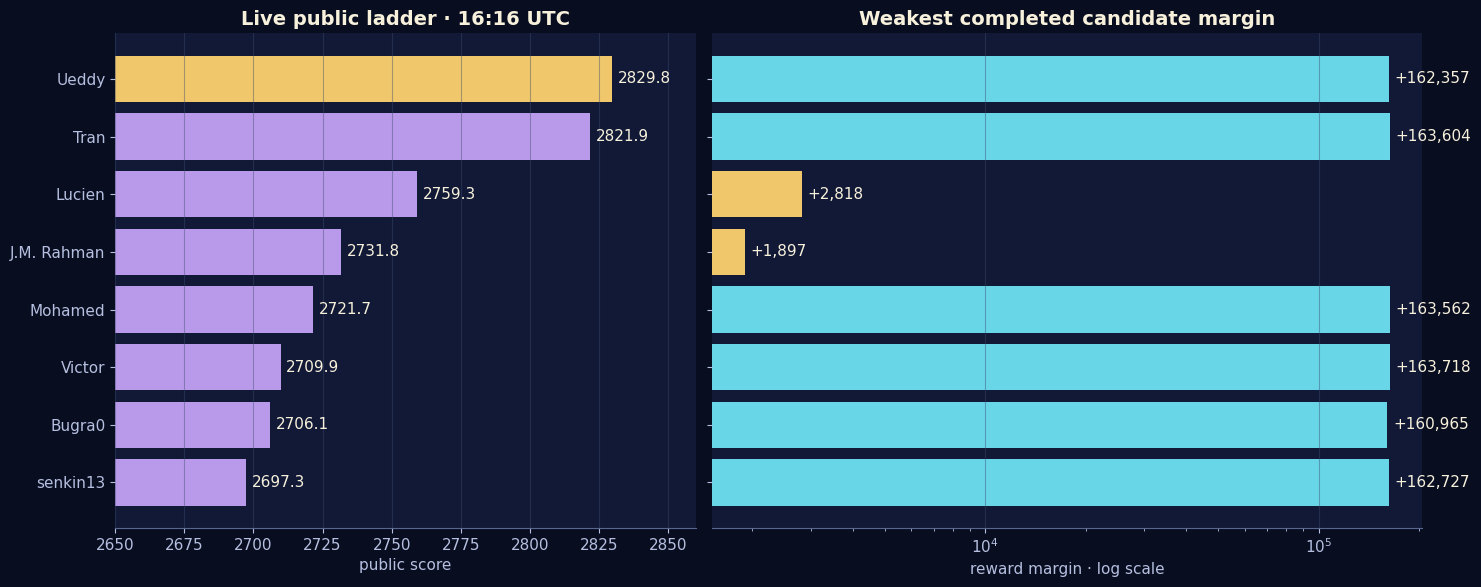

In [7]:
frontier=pd.DataFrame({
    "team":["Ueddy","Tran","Lucien","J.M. Rahman","Mohamed","Victor","Bugra0","senkin13"],
    "public_score":[2829.8,2821.9,2759.3,2731.8,2721.7,2709.9,2706.1,2697.3],
    "blind_min_margin":[162357,163604,2818,1897,163562,163718,160965,162727],
}).sort_values("public_score")
y=np.arange(len(frontier))
fig,(ax0,ax1)=plt.subplots(1,2,figsize=(15,6),gridspec_kw={"width_ratios":[.9,1.1]})
b=ax0.barh(y,frontier.public_score,color=[MOON if x==frontier.public_score.max() else VIOLET for x in frontier.public_score])
ax0.bar_label(b,labels=[f"{x:.1f}" for x in frontier.public_score],padding=4,color=INK)
ax0.set_yticks(y,frontier.team); ax0.set_xlim(2650,2860); ax0.set(title="Live public ladder · 16:16 UTC",xlabel="public score")
ax0.grid(axis="x"); ax0.spines[["top","right","left"]].set_visible(False)
b=ax1.barh(y,frontier.blind_min_margin,color=[MOON if x<5000 else RAIN for x in frontier.blind_min_margin])
ax1.bar_label(b,labels=[f"+{x:,}" for x in frontier.blind_min_margin],padding=4,color=INK)
ax1.set_yticks(y,[""]*len(y)); ax1.set_xscale("log"); ax1.set(title="Weakest completed candidate margin",xlabel="reward margin · log scale")
ax1.grid(axis="x"); ax1.spines[["top","right","left"]].set_visible(False)
plt.tight_layout(); plt.show()

## Freeze first, then ask the frontier

The source digest below was fixed before the final episode refresh. Only completed public episodes created after that timestamp were eligible for this holdout. No parameter changed after their identities, seats, or seeds became visible.

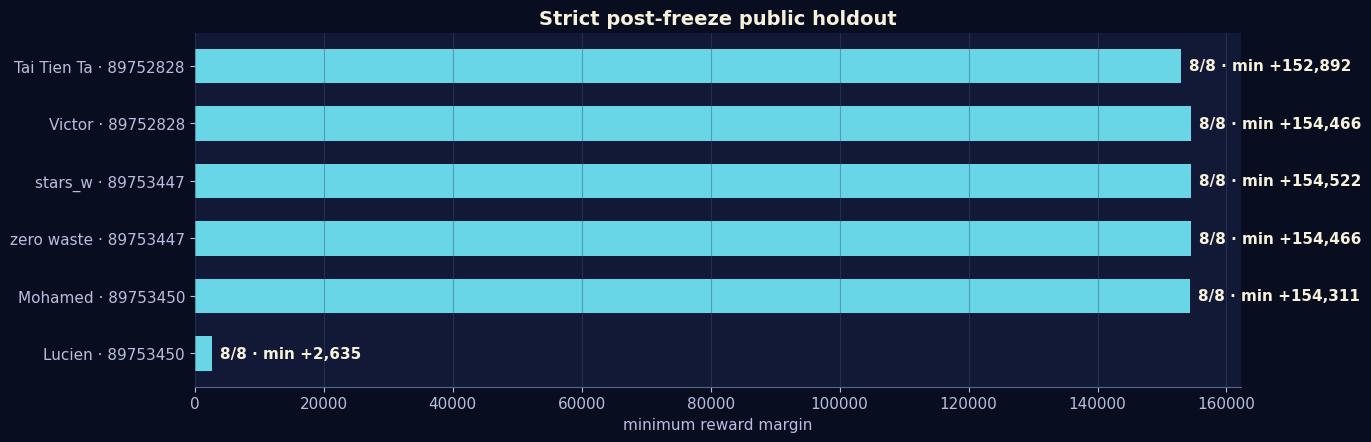

In [8]:
STRICT_ROWS = pd.DataFrame([{'opponent': 'Tai Tien Ta · 89752828', 'wins': 8, 'games': 8, 'min_margin': 152892.0}, {'opponent': 'Victor · 89752828', 'wins': 8, 'games': 8, 'min_margin': 154466.0}, {'opponent': 'stars_w · 89753447', 'wins': 8, 'games': 8, 'min_margin': 154522.0}, {'opponent': 'zero waste · 89753447', 'wins': 8, 'games': 8, 'min_margin': 154466.0}, {'opponent': 'Mohamed · 89753450', 'wins': 8, 'games': 8, 'min_margin': 154311.0}, {'opponent': 'Lucien · 89753450', 'wins': 8, 'games': 8, 'min_margin': 2635.0}])
STRICT_FREEZE_UTC = '2026-08-03 16:15:00 UTC'
STRICT_REFRESH_UTC = '2026-08-03T16:29:22.230577+00:00'

y=np.arange(len(STRICT_ROWS)); fig,ax=plt.subplots(figsize=(13.5,max(4.6,1.0+len(STRICT_ROWS)*.58)))
bars=ax.barh(y,STRICT_ROWS["min_margin"],color=[RAIN if x>0 else CLAY for x in STRICT_ROWS.min_margin],height=.6)
ax.bar_label(bars,labels=[f"{w}/{g} · min {m:+,.0f}" for w,g,m in zip(STRICT_ROWS.wins,STRICT_ROWS.games,STRICT_ROWS.min_margin)],padding=6,color=INK,weight="bold")
ax.set_yticks(y,STRICT_ROWS.opponent); ax.invert_yaxis(); ax.set(title="Strict post-freeze public holdout",xlabel="minimum reward margin")
ax.grid(axis="x"); ax.spines[["top","right","left"]].set_visible(False); plt.show()
display(HTML(f"<div style='padding:17px 21px;border:1px solid #596896;border-radius:15px;background:linear-gradient(135deg,#111936,#252650);color:#f7f1dc'><b style='color:#68d6e7'>Temporal boundary verified</b><br>freeze {STRICT_FREEZE_UTC}<br>refresh {STRICT_REFRESH_UTC}</div>"))

## The intervention is deliberately small

The parent policy still chooses movement, labor, purchases, and ordinary sales. Moon V9 observes a near-clone, looks one turn ahead in its own frozen schedule, and may move one already-owned premium sale forward. It never reads opponent-private inventory or replay identity.

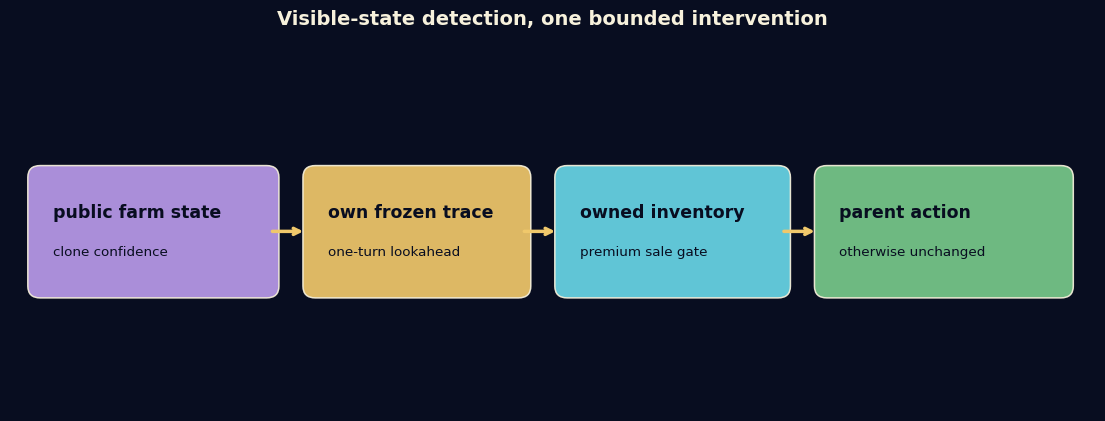

In [9]:
fig,ax=plt.subplots(figsize=(14,4.8)); ax.set_xlim(0,14); ax.set_ylim(0,5); ax.axis("off")
boxes=[
    (.35,1.65,3.0,1.55,"public farm state","clone confidence",VIOLET),
    (3.9,1.65,2.7,1.55,"own frozen trace","one-turn lookahead",MOON),
    (7.15,1.65,2.8,1.55,"owned inventory","premium sale gate",RAIN),
    (10.5,1.65,3.1,1.55,"parent action","otherwise unchanged",GREEN),
]
for x,y,w,h,title,sub,color in boxes:
    ax.add_patch(FancyBboxPatch((x,y),w,h,boxstyle="round,pad=.12,rounding_size=.16",facecolor=color,alpha=.92,edgecolor=INK,lw=1.1))
    ax.text(x+.2,y+h*.62,title,color=NAVY,weight="bold",fontsize=12.5)
    ax.text(x+.2,y+h*.29,sub,color=NAVY,fontsize=9.7)
for left,right in [(3.35,3.82),(6.6,7.07),(9.95,10.42)]:
    ax.annotate("",xy=(right,2.43),xytext=(left,2.43),arrowprops={"arrowstyle":"->","lw":2.5,"color":MOON})
ax.set_title("Visible-state detection, one bounded intervention",pad=12); plt.show()

## Write the exact frozen agent

The notebook stops unless the embedded source reproduces the pre-holdout digest byte for byte.

In [10]:
AGENT_SOURCE = '"""Fixed public Tran H Hoang policy from episode 89674601, seat 0."""\nimport copy\n\nTRACE_ACTIONS = [{\'farmer\': [\'PASS\'], \'hands\': [], \'market\': [[\'HIRE\'], [\'HIRE\'], [\'BUY_ANIMAL\', \'COW\', 1], [\'BUY_SEED\', \'MELON\', 6], [\'BUY_SEED\', \'WHEAT\', 6], [\'SELL\', \'WHEAT\', 1], [\'SELL\', \'WHEAT\', 3], [\'SELL\', \'WHEAT\', 1]]}, {\'farmer\': [\'BUILD_PASTURE\'], \'hands\': [[\'WEST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 6], [\'HIRE\'], [\'BUY_ANIMAL\', \'COW\', 1], [\'BUY_SEED\', \'WHEAT\', 5]]}, {\'farmer\': [\'PICKUP\', \'COW\', 1], \'hands\': [[\'NORTH\'], [\'NORTH\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2], [\'BUY_ANIMAL\', \'COW\', 1]]}, {\'farmer\': [\'PLACE\', \'COW\'], \'hands\': [[\'BUILD_PASTURE\'], [\'NORTH\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2], [\'BUY_ANIMAL\', \'SHEEP\', 1]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'SOUTH\'], [\'BUILD_PASTURE\'], [\'BUILD_PASTURE\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 3], [\'HIRE\']]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'PICKUP\', \'COW\', 2], [\'NORTH\'], [\'EAST\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'WHEAT\', 1]]}, {\'farmer\': [\'PICKUP\', \'SHEEP\', 1], \'hands\': [[\'CARE\'], [\'NORTH\'], [\'CARE\'], [\'CARE\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 6]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'NORTH\'], [\'PLANT\', \'MELON\'], [\'NORTH\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'PLACE\', \'COW\'], [\'WATER\'], [\'NORTH\'], [\'PASS\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2], [\'BUY_SEED\', \'MELON\', 1]]}, {\'farmer\': [\'PLACE\', \'SHEEP\'], \'hands\': [[\'CARE\'], [\'WEST\'], [\'SOUTH\'], [\'PASS\']], \'market\': [[\'SELL\', \'WHEAT\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 3]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'SOUTH\'], [\'PLANT\', \'MELON\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 2], [\'SELL\', \'WHEAT\', 2]]}, {\'farmer\': [\'CARE\'], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'WATER\'], [\'NORTH\'], [\'SOUTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'NORTH\'], [\'WEST\'], [\'WEST\'], [\'PASS\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2], [\'SELL\', \'WHEAT\', 1]]}, {\'farmer\': [\'PLANT\', \'WHEAT\'], \'hands\': [[\'FEED\'], [\'PLANT\', \'MELON\'], [\'PLANT\', \'MELON\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'WATER\'], \'hands\': [[\'SOUTH\'], [\'WATER\'], [\'WATER\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 3], [\'SELL\', \'WHEAT\', 1]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'WEST\'], [\'WEST\'], [\'WEST\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'PLANT\', \'WHEAT\'], \'hands\': [[\'PLACE\', \'COW\'], [\'PLANT\', \'MELON\'], [\'PLANT\', \'MELON\'], [\'PLANT\', \'WHEAT\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 3], [\'SELL\', \'WHEAT\', 2]]}, {\'farmer\': [\'WATER\'], \'hands\': [[\'FEED\'], [\'WATER\'], [\'WATER\'], [\'WATER\']], \'market\': []}, {\'farmer\': [\'WEST\'], \'hands\': [[\'CARE\'], [\'WEST\'], [\'EAST\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 4], [\'SELL\', \'WHEAT\', 3]]}, {\'farmer\': [\'PLANT\', \'WHEAT\'], \'hands\': [[\'WEST\'], [\'PLANT\', \'MELON\'], [\'EAST\'], [\'PLANT\', \'WHEAT\']], \'market\': []}, {\'farmer\': [\'WATER\'], \'hands\': [[\'WEST\'], [\'WATER\'], [\'PLANT\', \'WHEAT\'], [\'WATER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 4], [\'SELL\', \'WHEAT\', 2]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'WEST\'], [\'SOUTH\'], [\'WATER\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'PLANT\', \'WHEAT\'], \'hands\': [[\'PLANT\', \'WHEAT\'], [\'PLANT\', \'WHEAT\'], [\'SOUTH\'], [\'PLANT\', \'WHEAT\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 4]]}, {\'farmer\': [\'WATER\'], \'hands\': [[\'WATER\'], [\'WATER\'], [\'SOUTH\'], [\'WATER\']], \'market\': [[\'SELL\', \'WHEAT\', 1]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 4], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WEST\'], [\'NORTH\']], \'market\': [[\'SELL\', \'WHEAT\', 2], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 3], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'NORTH\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'CARE\'], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'CARE\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'EAST\'], [\'WEST\'], [\'NORTH\'], [\'PASS\']], \'market\': [[\'SELL\', \'WHEAT\', 4]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'NORTH\'], [\'DROP\'], [\'WEST\'], [\'NORTH\'], [\'PASS\']], \'market\': [[\'SELL\', \'FERTILIZER\', 4]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WATER\'], [\'PASS\'], [\'WEST\'], [\'WATER\'], [\'PASS\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'WEST\'], [\'PASS\'], [\'WEST\'], [\'WEST\'], [\'PASS\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WATER\'], [\'PASS\'], [\'PLANT\', \'WHEAT\'], [\'WATER\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'WEST\'], [\'PASS\'], [\'WATER\'], [\'WEST\'], [\'PASS\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'WATER\'], [\'PASS\'], [\'NORTH\'], [\'WATER\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'WEST\'], \'hands\': [[\'WEST\'], [\'PASS\'], [\'WATER\'], [\'WEST\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WATER\'], [\'PASS\'], [\'NORTH\'], [\'WATER\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'EAST\'], \'hands\': [[\'SOUTH\'], [\'PASS\'], [\'WATER\'], [\'SOUTH\'], [\'PASS\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'WATER\'], [\'PASS\'], [\'SOUTH\'], [\'SOUTH\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'PASS\'], \'hands\': [[\'EAST\'], [\'PASS\'], [\'SOUTH\'], [\'SOUTH\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'PASS\'], \'hands\': [[\'WATER\'], [\'PASS\'], [\'SOUTH\'], [\'WATER\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'PASS\'], \'hands\': [[\'EAST\'], [\'PASS\'], [\'WATER\'], [\'EAST\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'PASS\'], \'hands\': [[\'WATER\'], [\'PASS\'], [\'SOUTH\'], [\'WATER\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'PASS\'], \'hands\': [[\'SOUTH\'], [\'PASS\'], [\'WATER\'], [\'SOUTH\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'PASS\'], \'hands\': [[\'SOUTH\'], [\'PASS\'], [\'EAST\'], [\'EAST\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'PASS\'], \'hands\': [[\'EAST\'], [\'PASS\'], [\'EAST\'], [\'EAST\'], [\'PASS\']], \'market\': [[\'SELL\', \'FERTILIZER\', 1]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [], \'market\': [[\'SELL\', \'FERTILIZER\', 2], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WEST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 4], [\'HIRE\'], [\'HIRE\'], [\'BUY_SEED\', \'MELON\', 1]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'NORTH\']], \'market\': [[\'SELL\', \'WHEAT\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 9], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'NORTH\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'CARE\'], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'CARE\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'NORTH\'], [\'WEST\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 1], \'hands\': [[\'WEST\'], [\'WEST\'], [\'WATER\'], [\'WATER\'], [\'WATER\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'WEST\'], [\'PLANT\', \'MELON\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WATER\'], [\'WATER\'], [\'WATER\'], [\'WEST\'], [\'WATER\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'WEST\'], [\'WEST\'], [\'WEST\'], [\'WEST\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WATER\'], [\'WATER\'], [\'SOUTH\'], [\'WATER\'], [\'WATER\']], \'market\': []}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'WEST\'], [\'EAST\'], [\'WATER\'], [\'WEST\'], [\'SOUTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'WATER\'], [\'EAST\'], [\'NORTH\'], [\'WATER\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'WEST\'], \'hands\': [[\'SOUTH\'], [\'EAST\'], [\'WATER\'], [\'NORTH\'], [\'EAST\']], \'market\': [[\'SELL\', \'FERTILIZER\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'SOUTH\'], [\'EAST\'], [\'WEST\'], [\'WATER\'], [\'EAST\']], \'market\': [[\'SELL\', \'WHEAT\', 7]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'EAST\'], [\'DROP\'], [\'WATER\'], [\'EAST\'], [\'EAST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'EAST\'], [\'PASS\'], [\'WEST\'], [\'SOUTH\'], [\'PASS\']], \'market\': [[\'SELL\', \'CARROT\', 1]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'EAST\'], [\'PASS\'], [\'WATER\'], [\'EAST\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'PASS\'], \'hands\': [[\'EAST\'], [\'PASS\'], [\'SOUTH\'], [\'WATER\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'PASS\'], \'hands\': [[\'DROP\'], [\'PASS\'], [\'SOUTH\'], [\'SOUTH\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'PASS\'], \'hands\': [[\'PASS\'], [\'PASS\'], [\'SOUTH\'], [\'SOUTH\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'PASS\'], \'hands\': [[\'PASS\'], [\'PASS\'], [\'SOUTH\'], [\'SOUTH\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'PASS\'], \'hands\': [[\'PASS\'], [\'PASS\'], [\'EAST\'], [\'EAST\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [], \'market\': [[\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WEST\'], [\'NORTH\']], \'market\': [[\'HIRE\'], [\'BUY_PRODUCT\', \'WHEAT\', 4], [\'HIRE\'], [\'SELL\', \'FERTILIZER\', 4], [\'SELL\', \'WHEAT\', 4]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'NORTH\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'CARE\'], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'WEST\']], \'market\': [[\'SELL\', \'MELON\', 6], [\'SELL\', \'WHEAT\', 2]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'CARE\'], [\'NORTH\']], \'market\': [[\'SELL\', \'MELON\', 5]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'EAST\'], [\'NORTH\'], [\'WEST\'], [\'WEST\']], \'market\': [[\'SELL\', \'WHEAT\', 4]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 1], \'hands\': [[\'WEST\'], [\'DROP\'], [\'WATER\'], [\'WATER\'], [\'WATER\']], \'market\': [[\'SELL\', \'FERTILIZER\', 8]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'WEST\'], [\'PASS\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WATER\'], [\'PASS\'], [\'WATER\'], [\'WEST\'], [\'WATER\']], \'market\': [[\'SELL\', \'WHEAT\', 5]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'WEST\'], [\'PASS\'], [\'WEST\'], [\'WEST\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WATER\'], [\'WEST\'], [\'SOUTH\'], [\'WATER\'], [\'WATER\']], \'market\': []}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'WEST\'], [\'EAST\'], [\'WATER\'], [\'WEST\'], [\'SOUTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'WATER\'], [\'PASS\'], [\'NORTH\'], [\'WATER\'], [\'WATER\']], \'market\': []}, {\'farmer\': [\'WEST\'], \'hands\': [[\'SOUTH\'], [\'PASS\'], [\'WATER\'], [\'NORTH\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'FEED\'], \'hands\': [[\'SOUTH\'], [\'PASS\'], [\'WEST\'], [\'WATER\'], [\'WATER\']], \'market\': []}, {\'farmer\': [\'EAST\'], \'hands\': [[\'EAST\'], [\'PASS\'], [\'WATER\'], [\'EAST\'], [\'EAST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'EAST\'], [\'PASS\'], [\'WEST\'], [\'SOUTH\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'PASS\'], \'hands\': [[\'EAST\'], [\'PASS\'], [\'WATER\'], [\'EAST\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'PASS\'], \'hands\': [[\'EAST\'], [\'PASS\'], [\'SOUTH\'], [\'WATER\'], [\'PASS\']], \'market\': [[\'SELL\', \'FERTILIZER\', 8]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'DROP\'], [\'PASS\'], [\'SOUTH\'], [\'SOUTH\'], [\'PASS\']], \'market\': [[\'SELL\', \'FERTILIZER\', 1]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'PASS\'], [\'PASS\'], [\'SOUTH\'], [\'SOUTH\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'PASS\'], \'hands\': [[\'PASS\'], [\'PASS\'], [\'SOUTH\'], [\'SOUTH\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'PASS\'], \'hands\': [[\'PASS\'], [\'PASS\'], [\'EAST\'], [\'EAST\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [], \'market\': [[\'SELL\', \'FERTILIZER\', 1], [\'SELL\', \'WHEAT\', 4], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WEST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 4], [\'HIRE\'], [\'HIRE\'], [\'SELL\', \'WHEAT\', 2]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'NORTH\']], \'market\': [[\'SELL\', \'MELON\', 4], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'NORTH\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'CARE\'], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'CARE\'], [\'WEST\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\'], [\'WEST\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 1], \'hands\': [[\'WEST\'], [\'WEST\'], [\'HARVEST\'], [\'HARVEST\'], [\'HARVEST\'], [\'WATER\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'WEST\'], [\'WEST\'], [\'SOUTH\'], [\'SOUTH\'], [\'NORTH\'], [\'WEST\']], \'market\': [[\'BUY_SEED\', \'MELON\', 3], [\'BUY_SEED\', \'WHEAT\', 3]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'HARVEST\'], [\'HARVEST\'], [\'FEED\'], [\'SOUTH\'], [\'WATER\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'WEST\'], \'hands\': [[\'PLANT\', \'WHEAT\'], [\'PLANT\', \'MELON\'], [\'NORTH\'], [\'FEED\'], [\'NORTH\'], [\'HARVEST\']], \'market\': [[\'BUY_SEED\', \'STRAWBERRY\', 2], [\'BUY_SEED\', \'WHEAT\', 2]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'WATER\'], [\'WATER\'], [\'PLANT\', \'STRAWBERRY\'], [\'WEST\'], [\'WEST\'], [\'PLANT\', \'STRAWBERRY\']], \'market\': [[\'BUY_SEED\', \'WHEAT\', 1]]}, {\'farmer\': [\'PLANT\', \'WHEAT\'], \'hands\': [[\'NORTH\'], [\'WEST\'], [\'WATER\'], [\'WEST\'], [\'HARVEST\'], [\'WATER\']], \'market\': []}, {\'farmer\': [\'WATER\'], \'hands\': [[\'WEST\'], [\'HARVEST\'], [\'SOUTH\'], [\'WEST\'], [\'PLANT\', \'WHEAT\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'WATER\'], [\'PLANT\', \'WHEAT\'], [\'WEST\'], [\'HARVEST\'], [\'WEST\'], [\'WATER\']], \'market\': []}, {\'farmer\': [\'WEST\'], \'hands\': [[\'WEST\'], [\'WATER\'], [\'PLANT\', \'WHEAT\'], [\'PLANT\', \'WHEAT\'], [\'HARVEST\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'WATER\'], \'hands\': [[\'PLANT\', \'MELON\'], [\'SOUTH\'], [\'WATER\'], [\'WATER\'], [\'NORTH\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'EAST\'], \'hands\': [[\'WATER\'], [\'EAST\'], [\'NORTH\'], [\'EAST\'], [\'WATER\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'EAST\'], \'hands\': [[\'SOUTH\'], [\'EAST\'], [\'WATER\'], [\'EAST\'], [\'EAST\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'EAST\'], \'hands\': [[\'SOUTH\'], [\'EAST\'], [\'NORTH\'], [\'EAST\'], [\'WATER\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'PASS\'], \'hands\': [[\'SOUTH\'], [\'EAST\'], [\'WATER\'], [\'EAST\'], [\'EAST\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'PASS\'], \'hands\': [[\'EAST\'], [\'DROP\'], [\'WEST\'], [\'PASS\'], [\'SOUTH\'], [\'PASS\']], \'market\': [[\'SELL\', \'FERTILIZER\', 2]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'EAST\'], [\'PASS\'], [\'WATER\'], [\'PASS\'], [\'WATER\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'PASS\'], \'hands\': [[\'EAST\'], [\'PASS\'], [\'SOUTH\'], [\'PASS\'], [\'SOUTH\'], [\'PASS\']], \'market\': [[\'SELL\', \'WHEAT\', 3]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [], \'market\': [[\'SELL\', \'WHEAT\', 31], [\'SELL\', \'FERTILIZER\', 2], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WEST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 4], [\'HIRE\'], [\'HIRE\'], [\'BUY_ANIMAL\', \'COW\', 1]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 3], [\'HIRE\'], [\'HIRE\'], [\'BUY_ANIMAL\', \'SHEEP\', 1]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'NORTH\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 3]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'CARE\'], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'WEST\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'BUILD_PASTURE\'], [\'WEST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'CARE\'], [\'EAST\'], [\'COLLECT_FERTILIZER\'], [\'SOUTH\'], [\'BUILD_PASTURE\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'WEST\'], [\'PICKUP\', \'COW\', 1], [\'WEST\'], [\'EAST\'], [\'NORTH\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'WEST\'], [\'PICKUP\', \'SHEEP\', 1], [\'WEST\'], [\'PASS\'], [\'WATER\'], [\'WATER\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 1], \'hands\': [[\'WEST\'], [\'NORTH\'], [\'WEST\'], [\'PASS\'], [\'NORTH\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'WEST\'], [\'WEST\'], [\'WEST\'], [\'PASS\'], [\'WATER\'], [\'WATER\']], \'market\': []}, {\'farmer\': [\'FEED\'], \'hands\': [[\'HARVEST\'], [\'PLACE\', \'COW\'], [\'WATER\'], [\'PASS\'], [\'NORTH\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'SOUTH\'], [\'CARE\'], [\'NORTH\'], [\'PASS\'], [\'WATER\'], [\'WATER\']], \'market\': []}, {\'farmer\': [\'FEED\'], \'hands\': [[\'EAST\'], [\'SOUTH\'], [\'WATER\'], [\'PASS\'], [\'WEST\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'SOUTH\'], [\'WEST\'], [\'NORTH\'], [\'PASS\'], [\'WATER\'], [\'WATER\']], \'market\': [[\'SELL\', \'WHEAT\', 1]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'EAST\'], [\'PLACE\', \'SHEEP\'], [\'WATER\'], [\'PASS\'], [\'SOUTH\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'FEED\'], \'hands\': [[\'FEED\'], [\'CARE\'], [\'SOUTH\'], [\'PASS\'], [\'WATER\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'WEST\'], [\'EAST\'], [\'SOUTH\'], [\'PASS\'], [\'SOUTH\'], [\'SOUTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WATER\'], [\'EAST\'], [\'SOUTH\'], [\'PASS\'], [\'WATER\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'EAST\'], \'hands\': [[\'WEST\'], [\'DROP\'], [\'WATER\'], [\'PASS\'], [\'SOUTH\'], [\'EAST\']], \'market\': [[\'SELL\', \'FERTILIZER\', 2], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'WATER\'], [\'PASS\'], [\'SOUTH\'], [\'PASS\'], [\'EAST\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'PASS\'], \'hands\': [[\'EAST\'], [\'PASS\'], [\'EAST\'], [\'PASS\'], [\'EAST\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'PASS\'], \'hands\': [[\'EAST\'], [\'PASS\'], [\'EAST\'], [\'PASS\'], [\'EAST\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'PASS\'], \'hands\': [[\'EAST\'], [\'PASS\'], [\'EAST\'], [\'PASS\'], [\'PASS\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [], \'market\': [[\'SELL\', \'WHEAT\', 6], [\'SELL\', \'FERTILIZER\', 2], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WEST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 7], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'CARE\'], [\'WEST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 3], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\'], [\'WEST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 4]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'NORTH\'], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'CARE\'], [\'NORTH\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'FEED\'], [\'NORTH\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'WEST\'], \'hands\': [[\'NORTH\'], [\'HARVEST\'], [\'CARE\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'FEED\'], [\'NORTH\'], [\'WEST\'], [\'CARE\'], [\'SOUTH\'], [\'WATER\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'SOUTH\'], [\'WEST\'], [\'WATER\'], [\'COLLECT_FERTILIZER\'], [\'SOUTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WEST\'], [\'WATER\'], [\'WEST\'], [\'SOUTH\'], [\'WEST\'], [\'WATER\']], \'market\': []}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'WEST\'], [\'SOUTH\'], [\'WATER\'], [\'WEST\'], [\'WEST\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'WATER\'], [\'SOUTH\'], [\'NORTH\'], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'WATER\']], \'market\': []}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WEST\'], [\'SOUTH\'], [\'WATER\'], [\'WEST\'], [\'EAST\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'WEST\'], \'hands\': [[\'WEST\'], [\'EAST\'], [\'WEST\'], [\'WEST\'], [\'EAST\'], [\'WATER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'WATER\'], \'hands\': [[\'WATER\'], [\'DROP\'], [\'WATER\'], [\'WATER\'], [\'DROP\'], [\'WEST\']], \'market\': [[\'SELL\', \'WOOL\', 6], [\'SELL\', \'FERTILIZER\', 2]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'SOUTH\'], [\'PASS\'], [\'NORTH\'], [\'EAST\'], [\'PASS\'], [\'WATER\']], \'market\': [[\'BUY_ANIMAL\', \'COW\', 1]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'EAST\'], [\'PASS\'], [\'WEST\'], [\'NORTH\'], [\'PASS\'], [\'SOUTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'NORTH\'], [\'PASS\'], [\'WATER\'], [\'NORTH\'], [\'PASS\'], [\'WEST\']], \'market\': [[\'SELL\', \'WHEAT\', 1]]}, {\'farmer\': [\'BUILD_PASTURE\'], \'hands\': [[\'WATER\'], [\'PASS\'], [\'SOUTH\'], [\'WATER\'], [\'PASS\'], [\'SOUTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'WHEAT\', 6], [\'SELL\', \'WHEAT\', 1]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'SOUTH\'], [\'PICKUP\', \'COW\', 1], [\'SOUTH\'], [\'SOUTH\'], [\'PASS\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'WATER\'], \'hands\': [[\'EAST\'], [\'PASS\'], [\'SOUTH\'], [\'SOUTH\'], [\'PASS\'], [\'SOUTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'EAST\'], [\'PASS\'], [\'SOUTH\'], [\'EAST\'], [\'PASS\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'EAST\'], [\'PASS\'], [\'EAST\'], [\'EAST\'], [\'PASS\'], [\'EAST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'DROP\'], [\'PASS\'], [\'EAST\'], [\'EAST\'], [\'PASS\'], [\'EAST\']], \'market\': [[\'SELL\', \'FERTILIZER\', 1], [\'SELL\', \'WHEAT\', 1]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [], \'market\': [[\'SELL\', \'FERTILIZER\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WEST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 7], [\'HIRE\'], [\'HIRE\'], [\'BUY_LAND\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'COW\', 1], [\'WEST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_SEED\', \'STRAWBERRY\', 4], [\'BUY_SEED\', \'WHEAT\', 5], [\'SELL\', \'WHEAT\', 10]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 5], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'NORTH\'], [\'NORTH\'], [\'CARE\'], [\'CARE\'], [\'WEST\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'FEED\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'WEST\'], \'hands\': [[\'NORTH\'], [\'NORTH\'], [\'CARE\'], [\'NORTH\'], [\'CARE\'], [\'CARE\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'FERTILIZER\', 2]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'FEED\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'PLANT\', \'MELON\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'NORTH\'], [\'WEST\'], [\'WATER\'], [\'NORTH\'], [\'WATER\'], [\'WEST\'], [\'WATER\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WEST\'], [\'WEST\'], [\'WEST\'], [\'SOUTH\'], [\'WEST\'], [\'WEST\'], [\'NORTH\'], [\'WATER\']], \'market\': []}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'WATER\'], [\'WATER\'], [\'NORTH\'], [\'SOUTH\'], [\'WEST\'], [\'WATER\'], [\'PLANT\', \'STRAWBERRY\'], [\'EAST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'NORTH\'], [\'WEST\'], [\'WATER\'], [\'EAST\'], [\'WATER\'], [\'EAST\'], [\'WATER\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WATER\'], [\'WEST\'], [\'NORTH\'], [\'DROP\'], [\'EAST\'], [\'WATER\'], [\'EAST\'], [\'PLANT\', \'STRAWBERRY\']], \'market\': [[\'SELL\', \'FERTILIZER\', 2]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'WEST\'], [\'PLACE\', \'COW\'], [\'WATER\'], [\'PASS\'], [\'WATER\'], [\'EAST\'], [\'WATER\'], [\'EAST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'WHEAT\', 9], [\'SELL\', \'WHEAT\', 1]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'WEST\'], [\'CARE\'], [\'SOUTH\'], [\'PASS\'], [\'NORTH\'], [\'EAST\'], [\'EAST\'], [\'PLANT\', \'STRAWBERRY\']], \'market\': [[\'SELL\', \'WHEAT\', 2]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'WATER\'], [\'NORTH\'], [\'WEST\'], [\'PASS\'], [\'WATER\'], [\'EAST\'], [\'WATER\'], [\'EAST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'WEST\'], [\'WATER\'], [\'WATER\'], [\'PASS\'], [\'SOUTH\'], [\'DROP\'], [\'SOUTH\'], [\'PLANT\', \'STRAWBERRY\']], \'market\': [[\'SELL\', \'FERTILIZER\', 1], [\'SELL\', \'WHEAT\', 1]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'WATER\'], [\'SOUTH\'], [\'EAST\'], [\'PASS\'], [\'SOUTH\'], [\'PASS\'], [\'PLANT\', \'WHEAT\'], [\'WATER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'SOUTH\'], [\'SOUTH\'], [\'EAST\'], [\'PASS\'], [\'EAST\'], [\'PASS\'], [\'WATER\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'FEED\'], \'hands\': [[\'SOUTH\'], [\'SOUTH\'], [\'EAST\'], [\'PASS\'], [\'EAST\'], [\'PASS\'], [\'WEST\'], [\'PLANT\', \'WHEAT\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'WHEAT\', 1]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'SOUTH\'], [\'EAST\'], [\'WATER\'], [\'PASS\'], [\'EAST\'], [\'PASS\'], [\'PLANT\', \'WHEAT\'], [\'WATER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'SOUTH\'], [\'EAST\'], [\'SOUTH\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'WATER\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'EAST\'], [\'EAST\'], [\'SOUTH\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'SOUTH\'], [\'PLANT\', \'WHEAT\']], \'market\': [[\'SELL\', \'WHEAT\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'WHEAT\', 8]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'EAST\'], [\'EAST\'], [\'SOUTH\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'SOUTH\'], [\'WATER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'WHEAT\', 8], [\'SELL\', \'WHEAT\', 5]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [], \'market\': [[\'SELL\', \'FERTILIZER\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WEST\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 6], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_SEED\', \'STRAWBERRY\', 2]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'HARVEST\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'CARE\'], [\'DROP\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'SELL\', \'MILK\', 8], [\'BUY_PRODUCT\', \'WHEAT\', 5], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'NORTH\'], [\'NORTH\'], [\'WEST\'], [\'HARVEST\'], [\'NORTH\'], [\'HARVEST\'], [\'NORTH\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'BUY_ANIMAL\', \'SHEEP\', 1], [\'BUY_SEED\', \'STRAWBERRY\', 4]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'FEED\'], [\'CARE\'], [\'CARE\'], [\'SOUTH\'], [\'PLANT\', \'STRAWBERRY\'], [\'EAST\'], [\'COLLECT_FERTILIZER\'], [\'EAST\'], [\'WEST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'NORTH\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'DROP\'], [\'WATER\'], [\'DROP\'], [\'NORTH\'], [\'BUILD_PASTURE\'], [\'CARE\'], [\'WEST\']], \'market\': [[\'SELL\', \'MILK\', 12], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'FEED\'], [\'CARE\'], [\'WEST\'], [\'PICKUP\', \'SHEEP\', 1], [\'WEST\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'WEST\'], [\'COLLECT_FERTILIZER\']], \'market\': [[\'BUY_ANIMAL\', \'SHEEP\', 1], [\'BUY_SEED\', \'STRAWBERRY\', 1]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'WEST\'], [\'WEST\'], [\'CARE\'], [\'EAST\'], [\'WEST\'], [\'EAST\'], [\'NORTH\'], [\'WEST\'], [\'HARVEST\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 3], [\'BUY_ANIMAL\', \'SHEEP\', 1]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'WEST\'], [\'HARVEST\'], [\'COLLECT_FERTILIZER\'], [\'PLACE\', \'SHEEP\'], [\'NORTH\'], [\'BUILD_PASTURE\'], [\'NORTH\'], [\'EAST\'], [\'SOUTH\'], [\'WATER\']], \'market\': [[\'BUY_ANIMAL\', \'SHEEP\', 1], [\'BUY_SEED\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'HARVEST\'], [\'PLANT\', \'WHEAT\'], [\'WEST\'], [\'CARE\'], [\'WATER\'], [\'EAST\'], [\'WATER\'], [\'PICKUP\', \'SHEEP\', 1], [\'FEED\'], [\'WEST\']], \'market\': [[\'BUY_SEED\', \'WHEAT\', 1]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'PLANT\', \'STRAWBERRY\'], [\'WATER\'], [\'WATER\'], [\'EAST\'], [\'WEST\'], [\'BUILD_PASTURE\'], [\'WEST\'], [\'NORTH\'], [\'SOUTH\'], [\'WEST\']], \'market\': [[\'BUY_SEED\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WATER\'], [\'NORTH\'], [\'WEST\'], [\'BUILD_PASTURE\'], [\'WATER\'], [\'SOUTH\'], [\'WATER\'], [\'EAST\'], [\'EAST\'], [\'HARVEST\']], \'market\': [[\'BUY_SEED\', \'STRAWBERRY\', 1]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'WEST\'], [\'WEST\'], [\'HARVEST\'], [\'NORTH\'], [\'WEST\'], [\'WEST\'], [\'WEST\'], [\'PLACE\', \'SHEEP\'], [\'PICKUP\', \'SHEEP\', 2], [\'PLANT\', \'WHEAT\']], \'market\': [[\'BUY_SEED\', \'WHEAT\', 1]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'WEST\'], [\'WEST\'], [\'PLANT\', \'WHEAT\'], [\'NORTH\'], [\'HARVEST\'], [\'NORTH\'], [\'WATER\'], [\'CARE\'], [\'EAST\'], [\'WATER\']], \'market\': [[\'BUY_SEED\', \'WHEAT\', 1]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'FEED\'], [\'CARE\'], [\'WATER\'], [\'EAST\'], [\'PLANT\', \'STRAWBERRY\'], [\'SOUTH\'], [\'WEST\'], [\'SOUTH\'], [\'FEED\'], [\'NORTH\']], \'market\': [[\'BUY_SEED\', \'WHEAT\', 1]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'EAST\'], [\'PLANT\', \'STRAWBERRY\'], [\'WATER\'], [\'EAST\'], [\'WATER\'], [\'PASS\'], [\'EAST\'], [\'NORTH\']], \'market\': [[\'BUY_SEED\', \'STRAWBERRY\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'WATER\'], [\'SOUTH\'], [\'NORTH\'], [\'SOUTH\'], [\'PASS\'], [\'PLACE\', \'SHEEP\'], [\'SOUTH\']], \'market\': [[\'BUY_SEED\', \'STRAWBERRY\', 1]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'WATER\'], [\'WATER\'], [\'WATER\'], [\'EAST\'], [\'WATER\'], [\'SOUTH\'], [\'SOUTH\'], [\'PASS\'], [\'FEED\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'PLANT\', \'STRAWBERRY\'], [\'SOUTH\'], [\'CARE\'], [\'SOUTH\'], [\'PASS\'], [\'NORTH\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'EAST\'], \'hands\': [[\'SOUTH\'], [\'SOUTH\'], [\'EAST\'], [\'WATER\'], [\'SOUTH\'], [\'WEST\'], [\'SOUTH\'], [\'PASS\'], [\'PLACE\', \'SHEEP\'], [\'EAST\']], \'market\': [[\'BUY_SEED\', \'STRAWBERRY\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'SOUTH\'], [\'SOUTH\'], [\'EAST\'], [\'NORTH\'], [\'EAST\'], [\'PASS\'], [\'EAST\'], [\'PASS\'], [\'CARE\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'EAST\'], [\'SOUTH\'], [\'EAST\'], [\'PLANT\', \'STRAWBERRY\'], [\'EAST\'], [\'PASS\'], [\'EAST\'], [\'PASS\'], [\'EAST\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'PLANT\', \'STRAWBERRY\'], \'hands\': [[\'EAST\'], [\'EAST\'], [\'DROP\'], [\'WATER\'], [\'EAST\'], [\'PASS\'], [\'EAST\'], [\'PASS\'], [\'PLANT\', \'STRAWBERRY\'], [\'EAST\']], \'market\': [[\'SELL\', \'FERTILIZER\', 3]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [], \'market\': [[\'SELL\', \'WHEAT\', 17], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_SEED\', \'STRAWBERRY\', 2]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'CARE\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 11], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'PICKUP\', \'WHEAT\', 2], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'SELL\', \'WHEAT\', 9], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'FERTILIZER\', 3], [\'NORTH\'], [\'PICKUP\', \'FERTILIZER\', 1], [\'NORTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'CARE\'], [\'PICKUP\', \'WHEAT\', 2], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'EAST\'], [\'CARE\'], [\'NORTH\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'FEED\'], [\'NORTH\'], [\'EAST\'], [\'NORTH\'], [\'WEST\'], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'CARE\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'WATER\'], [\'PICKUP\', \'WHEAT\', 1], [\'NORTH\'], [\'HARVEST\'], [\'DIG\'], [\'CARE\'], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'WHEAT\', 3]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 1], \'hands\': [[\'NORTH\'], [\'WEST\'], [\'FEED\'], [\'NORTH\'], [\'PLANT\', \'STRAWBERRY\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'EAST\'], [\'WEST\'], [\'NORTH\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'EAST\'], \'hands\': [[\'WATER\'], [\'FEED\'], [\'NORTH\'], [\'WATER\'], [\'WATER\'], [\'NORTH\'], [\'WEST\'], [\'DIG\'], [\'FERTILIZE\'], [\'EAST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'EAST\'], [\'NORTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'NORTH\'], [\'WATER\'], [\'WEST\'], [\'PLANT\', \'STRAWBERRY\'], [\'SOUTH\'], [\'EAST\'], [\'EAST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 3]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'WATER\'], [\'FEED\'], [\'SOUTH\'], [\'SOUTH\'], [\'WATER\'], [\'EAST\'], [\'WEST\'], [\'WATER\'], [\'CARE\'], [\'FERTILIZE\'], [\'DIG\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'EAST\'], [\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'EAST\'], [\'EAST\'], [\'FERTILIZE\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'PLANT\', \'STRAWBERRY\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'WATER\'], [\'WEST\'], [\'NORTH\'], [\'DROP\'], [\'WATER\'], [\'EAST\'], [\'SOUTH\'], [\'NORTH\'], [\'WEST\'], [\'WEST\'], [\'WATER\']], \'market\': [[\'SELL\', \'WOOL\', 4], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'EAST\'], [\'FEED\'], [\'NORTH\'], [\'NORTH\'], [\'EAST\'], [\'EAST\'], [\'FERTILIZE\'], [\'SOUTH\'], [\'WATER\'], [\'WEST\'], [\'NORTH\']], \'market\': [[\'BUY_ANIMAL\', \'COW\', 1], [\'BUY_SEED\', \'STRAWBERRY\', 2], [\'SELL\', \'FERTILIZER\', 3]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'WATER\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'EAST\'], [\'EAST\'], [\'NORTH\'], [\'SOUTH\'], [\'NORTH\'], [\'WATER\'], [\'EAST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 6]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'EAST\'], [\'NORTH\'], [\'WEST\'], [\'SOUTH\'], [\'WATER\'], [\'WATER\'], [\'NORTH\'], [\'SOUTH\'], [\'NORTH\'], [\'NORTH\'], [\'PLANT\', \'STRAWBERRY\']], \'market\': []}, {\'farmer\': [\'WEST\'], \'hands\': [[\'SOUTH\'], [\'WEST\'], [\'WEST\'], [\'NORTH\'], [\'WEST\'], [\'SOUTH\'], [\'CARE\'], [\'BUILD_PASTURE\'], [\'WEST\'], [\'WATER\'], [\'WATER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'WEST\'], [\'WEST\'], [\'WATER\'], [\'EAST\'], [\'SOUTH\'], [\'SOUTH\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'NORTH\'], [\'WEST\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'COW\', 1], \'hands\': [[\'WATER\'], [\'FEED\'], [\'WEST\'], [\'WATER\'], [\'WATER\'], [\'SOUTH\'], [\'NORTH\'], [\'WEST\'], [\'NORTH\'], [\'WATER\'], [\'PLANT\', \'STRAWBERRY\']], \'market\': []}, {\'farmer\': [\'EAST\'], \'hands\': [[\'SOUTH\'], [\'NORTH\'], [\'NORTH\'], [\'SOUTH\'], [\'WEST\'], [\'SOUTH\'], [\'EAST\'], [\'DROP\'], [\'WATER\'], [\'SOUTH\'], [\'WATER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 9], [\'SELL\', \'FERTILIZER\', 3]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'WEST\'], [\'WATER\'], [\'WATER\'], [\'SOUTH\'], [\'SOUTH\'], [\'WEST\'], [\'WATER\'], [\'PASS\'], [\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'EAST\'], \'hands\': [[\'WATER\'], [\'SOUTH\'], [\'SOUTH\'], [\'PASS\'], [\'SOUTH\'], [\'WEST\'], [\'SOUTH\'], [\'PASS\'], [\'SOUTH\'], [\'WATER\'], [\'WEST\']], \'market\': [[\'SELL\', \'FERTILIZER\', 2]]}, {\'farmer\': [\'PLACE\', \'COW\'], \'hands\': [[\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'PASS\'], [\'WEST\'], [\'WEST\'], [\'WATER\'], [\'PASS\'], [\'SOUTH\'], [\'SOUTH\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [], \'market\': [[\'SELL\', \'FERTILIZER\', 7], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'CARE\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 12], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'PICKUP\', \'WHEAT\', 2], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'SELL\', \'WHEAT\', 12], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'WHEAT\', 2], [\'EAST\'], [\'CARE\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 10], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'CARE\'], [\'PICKUP\', \'WHEAT\', 2], [\'HARVEST\'], [\'COLLECT_FERTILIZER\'], [\'CARE\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'PICKUP\', \'WHEAT\', 2], [\'EAST\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'CARE\'], [\'HARVEST\'], [\'WEST\'], [\'CARE\'], [\'WEST\'], [\'EAST\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'WEST\'], [\'PICKUP\', \'WHEAT\', 2], [\'FEED\'], [\'FEED\'], [\'EAST\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'NORTH\'], [\'HARVEST\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'CARE\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'WEST\'], [\'WEST\'], [\'EAST\'], [\'NORTH\'], [\'CARE\'], [\'NORTH\'], [\'CARE\'], [\'CARE\'], [\'WEST\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 1], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'FEED\'], [\'FEED\'], [\'FEED\'], [\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'NORTH\'], [\'CARE\'], [\'SOUTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'EAST\'], \'hands\': [[\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'EAST\'], [\'WEST\'], [\'WATER\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'NORTH\'], [\'WATER\']], \'market\': []}, {\'farmer\': [\'EAST\'], \'hands\': [[\'WEST\'], [\'FEED\'], [\'NORTH\'], [\'WEST\'], [\'EAST\'], [\'WEST\'], [\'NORTH\'], [\'WATER\'], [\'NORTH\'], [\'NORTH\'], [\'EAST\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'EAST\'], \'hands\': [[\'WATER\'], [\'EAST\'], [\'NORTH\'], [\'WATER\'], [\'PLANT\', \'STRAWBERRY\'], [\'WEST\'], [\'NORTH\'], [\'HARVEST\'], [\'WEST\'], [\'WEST\'], [\'FERTILIZE\'], [\'WATER\']], \'market\': []}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WEST\'], [\'EAST\'], [\'NORTH\'], [\'HARVEST\'], [\'WATER\'], [\'WEST\'], [\'WATER\'], [\'SOUTH\'], [\'NORTH\'], [\'NORTH\'], [\'EAST\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'WATER\'], [\'FEED\'], [\'WEST\'], [\'SOUTH\'], [\'NORTH\'], [\'CARE\'], [\'HARVEST\'], [\'SOUTH\'], [\'SOUTH\'], [\'NORTH\'], [\'EAST\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'WEST\'], \'hands\': [[\'SOUTH\'], [\'SOUTH\'], [\'WEST\'], [\'SOUTH\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'SOUTH\'], [\'SOUTH\'], [\'NORTH\'], [\'WATER\'], [\'WATER\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WATER\'], [\'WEST\'], [\'PLANT\', \'STRAWBERRY\'], [\'SOUTH\'], [\'NORTH\'], [\'NORTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'HARVEST\'], [\'NORTH\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'EAST\'], [\'WEST\'], [\'WATER\'], [\'EAST\'], [\'NORTH\'], [\'WATER\'], [\'SOUTH\'], [\'DROP\'], [\'NORTH\'], [\'SOUTH\'], [\'WATER\'], [\'WEST\']], \'market\': [[\'SELL\', \'MELON\', 6]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'WATER\'], [\'WEST\'], [\'WEST\'], [\'DROP\'], [\'WEST\'], [\'NORTH\'], [\'EAST\'], [\'PASS\'], [\'NORTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'WATER\']], \'market\': [[\'SELL\', \'MELON\', 6], [\'BUY_PRODUCT\', \'WHEAT\', 11], [\'BUY_ANIMAL\', \'COW\', 1], [\'BUY_SEED\', \'MELON\', 3]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'EAST\'], [\'FEED\'], [\'WATER\'], [\'PASS\'], [\'WATER\'], [\'WATER\'], [\'EAST\'], [\'PASS\'], [\'NORTH\'], [\'SOUTH\'], [\'WEST\'], [\'EAST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'BUY_ANIMAL\', \'COW\', 1]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'NORTH\'], [\'NORTH\'], [\'HARVEST\'], [\'PASS\'], [\'WEST\'], [\'HARVEST\'], [\'DROP\'], [\'PASS\'], [\'WATER\'], [\'SOUTH\'], [\'SOUTH\'], [\'WATER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 4], [\'SELL\', \'MELON\', 16]]}, {\'farmer\': [\'BUILD_PASTURE\'], \'hands\': [[\'NORTH\'], [\'NORTH\'], [\'SOUTH\'], [\'PASS\'], [\'WATER\'], [\'SOUTH\'], [\'PASS\'], [\'PASS\'], [\'HARVEST\'], [\'EAST\'], [\'SOUTH\'], [\'SOUTH\']], \'market\': [[\'BUY_LAND\']]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'NORTH\'], [\'WEST\'], [\'SOUTH\'], [\'PICKUP\', \'COW\', 1], [\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'PASS\'], [\'SOUTH\'], [\'EAST\'], [\'SOUTH\'], [\'WEST\']], \'market\': [[\'BUY_SEED\', \'STRAWBERRY\', 3]]}, {\'farmer\': [\'PLANT\', \'STRAWBERRY\'], \'hands\': [[\'PLANT\', \'STRAWBERRY\'], [\'WEST\'], [\'SOUTH\'], [\'PASS\'], [\'EAST\'], [\'SOUTH\'], [\'BUILD_PASTURE\'], [\'PASS\'], [\'SOUTH\'], [\'DROP\'], [\'PLANT\', \'WHEAT\'], [\'WATER\']], \'market\': [[\'SELL\', \'MELON\', 11], [\'SELL\', \'FERTILIZER\', 3]]}, {\'farmer\': [\'WATER\'], \'hands\': [[\'WATER\'], [\'FEED\'], [\'SOUTH\'], [\'PICKUP\', \'COW\', 1], [\'WATER\'], [\'SOUTH\'], [\'PASS\'], [\'PASS\'], [\'SOUTH\'], [\'PASS\'], [\'WATER\'], [\'SOUTH\']], \'market\': [[\'BUY_SEED\', \'MELON\', 2]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [], \'market\': [[\'SELL\', \'MELON\', 27], [\'BUY_PRODUCT\', \'WHEAT\', 2], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'SELL\', \'FERTILIZER\', 12]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'CARE\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 13], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'PICKUP\', \'WHEAT\', 2], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 3], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'WHEAT\', 2], [\'NORTH\'], [\'PICKUP\', \'COW\', 2], [\'NORTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 9], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'CARE\'], [\'PICKUP\', \'WHEAT\', 2], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\'], [\'SOUTH\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'NORTH\'], [\'WEST\'], [\'NORTH\'], [\'PLACE\', \'COW\'], [\'CARE\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'EAST\'], [\'EAST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2], [\'SELL\', \'STRAWBERRY\', 4]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'WATER\'], [\'PICKUP\', \'WHEAT\', 2], [\'FEED\'], [\'FEED\'], [\'EAST\'], [\'CARE\'], [\'NORTH\'], [\'EAST\'], [\'NORTH\'], [\'NORTH\'], [\'CARE\'], [\'CARE\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'WEST\'], [\'EAST\'], [\'NORTH\'], [\'CARE\'], [\'WATER\'], [\'NORTH\'], [\'CARE\'], [\'EAST\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'WEST\'], [\'FEED\'], [\'FEED\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\'], [\'WATER\'], [\'SOUTH\'], [\'WATER\'], [\'EAST\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'WEST\'], [\'NORTH\'], [\'SOUTH\'], [\'NORTH\'], [\'HARVEST\'], [\'NORTH\'], [\'WEST\'], [\'EAST\'], [\'WEST\'], [\'EAST\'], [\'CARE\'], [\'WATER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'WATER\'], [\'FEED\'], [\'SOUTH\'], [\'FEED\'], [\'PLANT\', \'MELON\'], [\'WEST\'], [\'WEST\'], [\'WATER\'], [\'CARE\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'FEED\'], \'hands\': [[\'NORTH\'], [\'EAST\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'WATER\'], [\'PLACE\', \'COW\'], [\'WATER\'], [\'EAST\'], [\'SOUTH\'], [\'EAST\'], [\'EAST\'], [\'WATER\']], \'market\': [[\'BUY_SEED\', \'STRAWBERRY\', 1]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'WEST\'], [\'FEED\'], [\'WEST\'], [\'WEST\'], [\'SOUTH\'], [\'CARE\'], [\'WEST\'], [\'WATER\'], [\'WEST\'], [\'EAST\'], [\'FERTILIZE\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'WEST\'], \'hands\': [[\'WATER\'], [\'SOUTH\'], [\'HARVEST\'], [\'WATER\'], [\'WEST\'], [\'SOUTH\'], [\'CARE\'], [\'NORTH\'], [\'CARE\'], [\'EAST\'], [\'NORTH\'], [\'WATER\']], \'market\': []}, {\'farmer\': [\'WEST\'], \'hands\': [[\'NORTH\'], [\'FEED\'], [\'EAST\'], [\'WEST\'], [\'WEST\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'HARVEST\'], [\'COLLECT_FERTILIZER\'], [\'HARVEST\'], [\'NORTH\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'FEED\'], \'hands\': [[\'PLANT\', \'STRAWBERRY\'], [\'EAST\'], [\'EAST\'], [\'WATER\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'PLANT\', \'WHEAT\'], [\'WEST\'], [\'PLANT\', \'MELON\'], [\'NORTH\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'WATER\'], [\'FEED\'], [\'DROP\'], [\'WEST\'], [\'FEED\'], [\'NORTH\'], [\'WATER\'], [\'WATER\'], [\'WATER\'], [\'WATER\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'SELL\', \'WOOL\', 6], [\'BUY_SEED\', \'STRAWBERRY\', 2]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'WEST\'], [\'EAST\'], [\'SOUTH\'], [\'WATER\'], [\'NORTH\'], [\'PLANT\', \'STRAWBERRY\'], [\'SOUTH\'], [\'NORTH\'], [\'WEST\'], [\'NORTH\'], [\'WATER\'], [\'HARVEST\']], \'market\': []}, {\'farmer\': [\'WEST\'], \'hands\': [[\'PLANT\', \'STRAWBERRY\'], [\'WATER\'], [\'PASS\'], [\'SOUTH\'], [\'NORTH\'], [\'WATER\'], [\'SOUTH\'], [\'PLANT\', \'WHEAT\'], [\'WATER\'], [\'WATER\'], [\'SOUTH\'], [\'SOUTH\']], \'market\': [[\'BUY_SEED\', \'STRAWBERRY\', 1]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'WATER\'], [\'EAST\'], [\'SOUTH\'], [\'SOUTH\'], [\'WEST\'], [\'EAST\'], [\'SOUTH\'], [\'WATER\'], [\'EAST\'], [\'WEST\'], [\'WATER\'], [\'SOUTH\']], \'market\': [[\'BUY_SEED\', \'STRAWBERRY\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'SOUTH\'], [\'WATER\'], [\'NORTH\'], [\'PLANT\', \'STRAWBERRY\'], [\'PLANT\', \'STRAWBERRY\'], [\'WATER\'], [\'SOUTH\'], [\'SOUTH\'], [\'EAST\'], [\'WATER\'], [\'SOUTH\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'FERTILIZER\', 1]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'SOUTH\'], [\'WEST\'], [\'PASS\'], [\'WATER\'], [\'WATER\'], [\'EAST\'], [\'SOUTH\'], [\'SOUTH\'], [\'EAST\'], [\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\']], \'market\': [[\'BUY_SEED\', \'STRAWBERRY\', 2]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'SOUTH\'], [\'WEST\'], [\'PASS\'], [\'EAST\'], [\'SOUTH\'], [\'WATER\'], [\'PLANT\', \'STRAWBERRY\'], [\'SOUTH\'], [\'EAST\'], [\'WEST\'], [\'SOUTH\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'EAST\'], \'hands\': [[\'SOUTH\'], [\'WEST\'], [\'PASS\'], [\'SOUTH\'], [\'WATER\'], [\'SOUTH\'], [\'WATER\'], [\'SOUTH\'], [\'DROP\'], [\'WATER\'], [\'WEST\'], [\'WEST\']], \'market\': [[\'BUY_SEED\', \'STRAWBERRY\', 1]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [], \'market\': [[\'SELL\', \'FERTILIZER\', 15], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'CARE\'], [\'CARE\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 22], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 9], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'WEST\'], [\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'WHEAT\', 2], [\'NORTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 10], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'WHEAT\', 2], [\'CARE\'], [\'CARE\'], [\'HARVEST\'], [\'COLLECT_FERTILIZER\'], [\'EAST\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'SELL\', \'STRAWBERRY\', 6]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'NORTH\'], [\'WEST\'], [\'EAST\'], [\'COLLECT_FERTILIZER\'], [\'SOUTH\'], [\'NORTH\'], [\'CARE\'], [\'CARE\'], [\'NORTH\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'FEED\'], [\'FEED\'], [\'FEED\'], [\'EAST\'], [\'FEED\'], [\'HARVEST\'], [\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'CARE\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'SELL\', \'MILK\', 12]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'NORTH\'], [\'HARVEST\'], [\'NORTH\'], [\'CARE\'], [\'NORTH\'], [\'WEST\'], [\'EAST\'], [\'NORTH\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'HARVEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'MILK\', 20]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'FEED\'], [\'NORTH\'], [\'FEED\'], [\'COLLECT_FERTILIZER\'], [\'EAST\'], [\'FEED\'], [\'CARE\'], [\'CARE\'], [\'WEST\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'WEST\']], \'market\': [[\'SELL\', \'WHEAT\', 49]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WEST\'], [\'CARE\'], [\'SOUTH\'], [\'NORTH\'], [\'EAST\'], [\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'WATER\'], [\'WEST\'], [\'SOUTH\'], [\'CARE\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2], [\'SELL\', \'WHEAT\', 38]]}, {\'farmer\': [\'CARE\'], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'WEST\'], [\'NORTH\'], [\'FEED\'], [\'EAST\'], [\'EAST\'], [\'WEST\'], [\'WEST\'], [\'HARVEST\'], [\'WEST\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'FERTILIZER\', 2]]}, {\'farmer\': [\'COLLECT_FERTILIZER\'], \'hands\': [[\'WEST\'], [\'FEED\'], [\'WEST\'], [\'EAST\'], [\'NORTH\'], [\'SOUTH\'], [\'WATER\'], [\'WEST\'], [\'WEST\'], [\'NORTH\'], [\'WEST\'], [\'WEST\']], \'market\': [[\'SELL\', \'WHEAT\', 56]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'WEST\'], [\'WEST\'], [\'SOUTH\'], [\'EAST\'], [\'FEED\'], [\'EAST\'], [\'NORTH\'], [\'WEST\'], [\'WEST\'], [\'WEST\'], [\'WEST\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'WATER\'], \'hands\': [[\'SOUTH\'], [\'WEST\'], [\'WEST\'], [\'EAST\'], [\'SOUTH\'], [\'WEST\'], [\'NORTH\'], [\'CARE\'], [\'WATER\'], [\'WEST\'], [\'WATER\'], [\'WEST\']], \'market\': [[\'SELL\', \'MILK\', 9]]}, {\'farmer\': [\'HARVEST\'], \'hands\': [[\'SOUTH\'], [\'WATER\'], [\'WEST\'], [\'FERTILIZE\'], [\'EAST\'], [\'DROP\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'FEED\'], [\'WEST\'], [\'HARVEST\']], \'market\': [[\'SELL\', \'MILK\', 6], [\'SELL\', \'WHEAT\', 35]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'PLANT\', \'STRAWBERRY\'], [\'SOUTH\'], [\'PLANT\', \'STRAWBERRY\'], [\'NORTH\'], [\'FEED\'], [\'PASS\'], [\'WATER\'], [\'SOUTH\'], [\'WATER\'], [\'SOUTH\'], [\'PLANT\', \'STRAWBERRY\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'EAST\'], \'hands\': [[\'WATER\'], [\'SOUTH\'], [\'WATER\'], [\'FERTILIZE\'], [\'NORTH\'], [\'PASS\'], [\'NORTH\'], [\'WATER\'], [\'EAST\'], [\'SOUTH\'], [\'SOUTH\'], [\'HARVEST\']], \'market\': [[\'BUY_SEED\', \'STRAWBERRY\', 3]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'EAST\'], [\'EAST\'], [\'SOUTH\'], [\'WATER\'], [\'WATER\'], [\'PASS\'], [\'WATER\'], [\'SOUTH\'], [\'WATER\'], [\'PLANT\', \'STRAWBERRY\'], [\'SOUTH\'], [\'EAST\']], \'market\': [[\'SELL\', \'FERTILIZER\', 12]]}, {\'farmer\': [\'DROP\'], \'hands\': [[\'SOUTH\'], [\'EAST\'], [\'PLANT\', \'STRAWBERRY\'], [\'SOUTH\'], [\'NORTH\'], [\'PASS\'], [\'WEST\'], [\'WATER\'], [\'EAST\'], [\'SOUTH\'], [\'SOUTH\'], [\'EAST\']], \'market\': [[\'SELL\', \'MELON\', 12], [\'BUY_SEED\', \'STRAWBERRY\', 1], [\'SELL\', \'WHEAT\', 22], [\'SELL\', \'TOMATO\', 4]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'SOUTH\'], [\'EAST\'], [\'WATER\'], [\'WATER\'], [\'WATER\'], [\'PASS\'], [\'WATER\'], [\'SOUTH\'], [\'WATER\'], [\'SOUTH\'], [\'SOUTH\'], [\'EAST\']], \'market\': [[\'BUY_SEED\', \'STRAWBERRY\', 1], [\'SELL\', \'WHEAT\', 4]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'PLANT\', \'STRAWBERRY\'], [\'DROP\'], [\'SOUTH\'], [\'SOUTH\'], [\'NORTH\'], [\'PASS\'], [\'WEST\'], [\'WATER\'], [\'EAST\'], [\'WATER\'], [\'PLANT\', \'MELON\'], [\'EAST\']], \'market\': [[\'SELL\', \'MILK\', 2], [\'SELL\', \'FERTILIZER\', 20]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'WATER\'], [\'PASS\'], [\'PLANT\', \'WHEAT\'], [\'WATER\'], [\'WATER\'], [\'PASS\'], [\'WATER\'], [\'EAST\'], [\'WATER\'], [\'SOUTH\'], [\'WATER\'], [\'DROP\']], \'market\': [[\'SELL\', \'WOOL\', 5], [\'BUY_SEED\', \'STRAWBERRY\', 2]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'SOUTH\'], [\'PASS\'], [\'WATER\'], [\'WEST\'], [\'WEST\'], [\'PASS\'], [\'WEST\'], [\'EAST\'], [\'EAST\'], [\'EAST\'], [\'SOUTH\'], [\'PASS\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 10]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'PLANT\', \'STRAWBERRY\'], [\'PASS\'], [\'SOUTH\'], [\'WATER\'], [\'WATER\'], [\'PASS\'], [\'WATER\'], [\'EAST\'], [\'WATER\'], [\'FERTILIZE\'], [\'PLANT\', \'STRAWBERRY\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 10], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'BUY_SEED\', \'STRAWBERRY\', 2], [\'SELL\', \'FERTILIZER\', 11]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'CARE\'], [\'CARE\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 4], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 9], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'WEST\'], [\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'WHEAT\', 2], [\'NORTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 4], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'WHEAT\', 2], [\'CARE\'], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 5]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'WEST\'], [\'EAST\'], [\'SOUTH\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'FEED\'], [\'NORTH\'], [\'CARE\'], [\'EAST\'], [\'NORTH\'], [\'EAST\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'FEED\'], [\'FEED\'], [\'FEED\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'WATER\'], [\'NORTH\'], [\'CARE\'], [\'NORTH\'], [\'CARE\'], [\'CARE\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'NORTH\'], [\'EAST\'], [\'NORTH\'], [\'FEED\'], [\'NORTH\'], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 3]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WEST\'], [\'FEED\'], [\'EAST\'], [\'WATER\'], [\'WEST\'], [\'NORTH\'], [\'WATER\'], [\'WEST\'], [\'EAST\'], [\'NORTH\'], [\'EAST\'], [\'HARVEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'CARE\'], \'hands\': [[\'FEED\'], [\'WEST\'], [\'EAST\'], [\'WEST\'], [\'FEED\'], [\'WATER\'], [\'SOUTH\'], [\'CARE\'], [\'EAST\'], [\'FERTILIZE\'], [\'CARE\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'COLLECT_FERTILIZER\'], \'hands\': [[\'CARE\'], [\'EAST\'], [\'FEED\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'SOUTH\'], [\'NORTH\'], [\'WEST\'], [\'WATER\'], [\'SOUTH\'], [\'COLLECT_FERTILIZER\'], [\'SOUTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'WEST\'], [\'WEST\'], [\'NORTH\'], [\'WEST\'], [\'EAST\'], [\'WATER\'], [\'EAST\'], [\'WEST\'], [\'WEST\'], [\'SOUTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'NORTH\'], [\'SOUTH\'], [\'WEST\'], [\'WEST\'], [\'WEST\'], [\'WEST\'], [\'EAST\'], [\'WEST\'], [\'WATER\'], [\'SOUTH\'], [\'EAST\'], [\'EAST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'WEST\'], [\'SOUTH\'], [\'SOUTH\'], [\'WEST\'], [\'WATER\'], [\'WEST\'], [\'EAST\'], [\'NORTH\'], [\'SOUTH\'], [\'NORTH\'], [\'WEST\'], [\'DROP\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'MILK\', 3]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WATER\'], [\'SOUTH\'], [\'SOUTH\'], [\'FERTILIZE\'], [\'SOUTH\'], [\'WEST\'], [\'EAST\'], [\'WATER\'], [\'WATER\'], [\'WEST\'], [\'EAST\'], [\'SOUTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'NORTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'WATER\'], [\'WEST\'], [\'CARE\'], [\'WATER\'], [\'WEST\'], [\'WEST\'], [\'SOUTH\'], [\'NORTH\'], [\'SOUTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'SOUTH\'], [\'WEST\'], [\'SOUTH\'], [\'SOUTH\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'WATER\'], [\'WATER\'], [\'SOUTH\'], [\'WATER\'], [\'SOUTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'SOUTH\'], [\'PLANT\', \'STRAWBERRY\'], [\'DIG\'], [\'WEST\'], [\'FEED\'], [\'SOUTH\'], [\'WATER\'], [\'NORTH\'], [\'WEST\'], [\'SOUTH\'], [\'NORTH\'], [\'SOUTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'SOUTH\'], [\'WATER\'], [\'PLANT\', \'MELON\'], [\'WATER\'], [\'SOUTH\'], [\'SOUTH\'], [\'WEST\'], [\'WATER\'], [\'WEST\'], [\'SOUTH\'], [\'WATER\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 4], [\'BUY_SEED\', \'STRAWBERRY\', 1]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'SOUTH\'], [\'SOUTH\'], [\'WATER\'], [\'SOUTH\'], [\'SOUTH\'], [\'EAST\'], [\'WATER\'], [\'EAST\'], [\'WEST\'], [\'SOUTH\'], [\'NORTH\'], [\'PLANT\', \'STRAWBERRY\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2], [\'BUY_SEED\', \'MELON\', 1], [\'SELL\', \'WHEAT\', 2]]}, {\'farmer\': [\'DROP\'], \'hands\': [[\'SOUTH\'], [\'WATER\'], [\'SOUTH\'], [\'WATER\'], [\'EAST\'], [\'SOUTH\'], [\'WEST\'], [\'WATER\'], [\'DROP\'], [\'DIG\'], [\'WATER\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 4], [\'BUY_SEED\', \'MELON\', 1]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'SOUTH\'], [\'SOUTH\'], [\'PLANT\', \'MELON\'], [\'EAST\'], [\'SOUTH\'], [\'WEST\'], [\'WATER\'], [\'EAST\'], [\'PASS\'], [\'PLANT\', \'STRAWBERRY\'], [\'WEST\'], [\'PLANT\', \'STRAWBERRY\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 8], [\'SELL\', \'WHEAT\', 8], [\'SELL\', \'FERTILIZER\', 5]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'PLANT\', \'STRAWBERRY\'], [\'PLANT\', \'MELON\'], [\'WATER\'], [\'WATER\'], [\'WATER\'], [\'WATER\'], [\'WEST\'], [\'WATER\'], [\'PASS\'], [\'WATER\'], [\'WATER\'], [\'WATER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 4], [\'BUY_SEED\', \'STRAWBERRY\', 2]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'WATER\'], [\'WATER\'], [\'NORTH\'], [\'EAST\'], [\'EAST\'], [\'EAST\'], [\'WATER\'], [\'SOUTH\'], [\'PASS\'], [\'NORTH\'], [\'SOUTH\'], [\'SOUTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 14], [\'SELL\', \'WHEAT\', 8]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 4], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'HARVEST\'], [\'CARE\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 10], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'SELL\', \'FERTILIZER\', 10], [\'SELL\', \'WHEAT\', 5]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'CARE\'], [\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 3], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'WHEAT\', 2], [\'NORTH\'], [\'SOUTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 10], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'SELL\', \'WHEAT\', 3]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'WHEAT\', 2], [\'EAST\'], [\'HARVEST\'], [\'CARE\'], [\'HARVEST\'], [\'NORTH\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'COLLECT_FERTILIZER\'], [\'HARVEST\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\'], [\'CARE\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'EAST\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'EAST\'], [\'NORTH\'], [\'NORTH\'], [\'FEED\'], [\'FEED\'], [\'EAST\'], [\'WATER\'], [\'EAST\'], [\'CARE\'], [\'CARE\'], [\'CARE\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'SOUTH\'], [\'FEED\'], [\'NORTH\'], [\'NORTH\'], [\'HARVEST\'], [\'HARVEST\'], [\'HARVEST\'], [\'WEST\'], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2], [\'SELL\', \'WHEAT\', 3]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'FEED\'], [\'NORTH\'], [\'EAST\'], [\'WATER\'], [\'NORTH\'], [\'NORTH\'], [\'SOUTH\'], [\'WATER\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'EAST\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'WHEAT\', 12], [\'SELL\', \'WHEAT\', 13], [\'SELL\', \'WHEAT\', 8]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'NORTH\'], [\'FEED\'], [\'EAST\'], [\'WEST\'], [\'FEED\'], [\'FEED\'], [\'WEST\'], [\'WEST\'], [\'SOUTH\'], [\'CARE\'], [\'CARE\'], [\'HARVEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'EAST\'], [\'NORTH\'], [\'WATER\'], [\'WATER\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'WEST\'], [\'WATER\'], [\'EAST\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'CARE\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 3], [\'SELL\', \'WHEAT\', 6]]}, {\'farmer\': [\'COLLECT_FERTILIZER\'], \'hands\': [[\'EAST\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\'], [\'WEST\'], [\'NORTH\'], [\'DROP\'], [\'SOUTH\'], [\'EAST\'], [\'CARE\'], [\'EAST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2], [\'SELL\', \'MILK\', 3]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'FEED\'], [\'WATER\'], [\'WATER\'], [\'WATER\'], [\'FEED\'], [\'WATER\'], [\'NORTH\'], [\'WATER\'], [\'HARVEST\'], [\'COLLECT_FERTILIZER\'], [\'WATER\'], [\'EAST\']], \'market\': [[\'SELL\', \'MILK\', 4], [\'SELL\', \'WOOL\', 7]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'NORTH\'], [\'WEST\'], [\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'WEST\'], [\'EAST\'], [\'PLANT\', \'STRAWBERRY\'], [\'WEST\'], [\'NORTH\'], [\'CARE\']], \'market\': [[\'BUY_SEED\', \'WHEAT\', 1]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'FEED\'], [\'HARVEST\'], [\'EAST\'], [\'SOUTH\'], [\'COLLECT_FERTILIZER\'], [\'SOUTH\'], [\'WEST\'], [\'WATER\'], [\'WATER\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'HARVEST\'], \'hands\': [[\'SOUTH\'], [\'WEST\'], [\'WATER\'], [\'SOUTH\'], [\'NORTH\'], [\'SOUTH\'], [\'WEST\'], [\'SOUTH\'], [\'WEST\'], [\'WEST\'], [\'NORTH\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'WEST\'], \'hands\': [[\'WEST\'], [\'WEST\'], [\'SOUTH\'], [\'SOUTH\'], [\'WEST\'], [\'EAST\'], [\'WATER\'], [\'WEST\'], [\'FEED\'], [\'CARE\'], [\'EAST\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'FEED\'], \'hands\': [[\'DROP\'], [\'WEST\'], [\'SOUTH\'], [\'EAST\'], [\'WATER\'], [\'DROP\'], [\'HARVEST\'], [\'DIG\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'WATER\'], [\'WATER\']], \'market\': [[\'SELL\', \'WOOL\', 6]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'PASS\'], [\'WATER\'], [\'WEST\'], [\'DROP\'], [\'NORTH\'], [\'PASS\'], [\'SOUTH\'], [\'PLANT\', \'WHEAT\'], [\'WATER\'], [\'SOUTH\'], [\'NORTH\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'WOOL\', 6], [\'BUY_SEED\', \'MELON\', 3]]}, {\'farmer\': [\'WATER\'], \'hands\': [[\'PASS\'], [\'NORTH\'], [\'WEST\'], [\'PASS\'], [\'WATER\'], [\'PASS\'], [\'EAST\'], [\'WATER\'], [\'NORTH\'], [\'WATER\'], [\'WATER\'], [\'PLANT\', \'STRAWBERRY\']], \'market\': []}, {\'farmer\': [\'HARVEST\'], \'hands\': [[\'PASS\'], [\'WATER\'], [\'WEST\'], [\'PASS\'], [\'NORTH\'], [\'PASS\'], [\'EAST\'], [\'SOUTH\'], [\'WATER\'], [\'SOUTH\'], [\'WEST\'], [\'WATER\']], \'market\': []}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'PASS\'], [\'SOUTH\'], [\'WEST\'], [\'PASS\'], [\'WATER\'], [\'PASS\'], [\'EAST\'], [\'PLANT\', \'MELON\'], [\'NORTH\'], [\'WATER\'], [\'WATER\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'PASS\'], [\'WEST\'], [\'DROP\'], [\'PASS\'], [\'SOUTH\'], [\'PASS\'], [\'DROP\'], [\'WATER\'], [\'WATER\'], [\'EAST\'], [\'WEST\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'WOOL\', 7]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'PASS\'], [\'PLANT\', \'MELON\'], [\'PASS\'], [\'PASS\'], [\'SOUTH\'], [\'PASS\'], [\'PASS\'], [\'EAST\'], [\'SOUTH\'], [\'WATER\'], [\'WATER\'], [\'WATER\']], \'market\': [[\'SELL\', \'MELON\', 5], [\'SELL\', \'STRAWBERRY\', 4]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [], \'market\': [[\'SELL\', \'FERTILIZER\', 20], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'CARE\'], [\'CARE\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 14], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'SELL\', \'MELON\', 7]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'WEST\'], [\'SOUTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'WHEAT\', 2], [\'NORTH\'], [\'WEST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 12], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'SOUTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'CARE\'], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'WEST\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'EAST\'], [\'NORTH\'], [\'WEST\'], [\'EAST\'], [\'NORTH\'], [\'EAST\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'WATER\'], [\'FEED\'], [\'NORTH\'], [\'FEED\'], [\'FEED\'], [\'WATER\'], [\'WEST\'], [\'CARE\'], [\'CARE\'], [\'CARE\'], [\'CARE\']], \'market\': []}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'NORTH\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'EAST\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'WEST\'], [\'WATER\'], [\'COLLECT_FERTILIZER\'], [\'EAST\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 3]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'NORTH\'], [\'WATER\'], [\'WEST\'], [\'WATER\'], [\'WEST\'], [\'FEED\'], [\'HARVEST\'], [\'SOUTH\'], [\'EAST\'], [\'NORTH\'], [\'EAST\'], [\'CARE\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'FEED\'], [\'SOUTH\'], [\'FEED\'], [\'NORTH\'], [\'FEED\'], [\'NORTH\'], [\'CARE\'], [\'NORTH\'], [\'EAST\'], [\'WEST\'], [\'CARE\'], [\'HARVEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'WATER\'], [\'COLLECT_FERTILIZER\'], [\'WATER\'], [\'CARE\'], [\'NORTH\'], [\'NORTH\'], [\'SOUTH\'], [\'WATER\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'SOUTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 3], [\'SELL\', \'WOOL\', 9]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'WEST\'], [\'WEST\'], [\'EAST\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'WATER\'], [\'WATER\'], [\'NORTH\'], [\'EAST\'], [\'CARE\'], [\'NORTH\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'MILK\', 12]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'FEED\'], [\'WATER\'], [\'EAST\'], [\'WATER\'], [\'NORTH\'], [\'EAST\'], [\'NORTH\'], [\'NORTH\'], [\'WATER\'], [\'COLLECT_FERTILIZER\'], [\'SOUTH\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'WEST\'], [\'EAST\'], [\'SOUTH\'], [\'EAST\'], [\'NORTH\'], [\'EAST\'], [\'WEST\'], [\'NORTH\'], [\'SOUTH\'], [\'WEST\'], [\'NORTH\'], [\'SOUTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WEST\'], [\'EAST\'], [\'EAST\'], [\'EAST\'], [\'WEST\'], [\'EAST\'], [\'WEST\'], [\'NORTH\'], [\'WATER\'], [\'WEST\'], [\'NORTH\'], [\'WEST\']], \'market\': [[\'SELL\', \'WHEAT\', 8]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'WATER\'], [\'WATER\'], [\'EAST\'], [\'EAST\'], [\'WEST\'], [\'EAST\'], [\'WEST\'], [\'HARVEST\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\'], [\'SOUTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'WOOL\', 6]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'WEST\'], [\'EAST\'], [\'FEED\'], [\'HARVEST\'], [\'FEED\'], [\'HARVEST\'], [\'WEST\'], [\'CARE\'], [\'NORTH\'], [\'WEST\'], [\'SOUTH\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'WATER\'], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'WATER\'], [\'NORTH\'], [\'PLANT\', \'MELON\'], [\'SOUTH\'], [\'PLANT\', \'MELON\'], [\'WATER\'], [\'SOUTH\'], [\'WATER\'], [\'DIG\'], [\'SOUTH\'], [\'SOUTH\']], \'market\': [[\'BUY_SEED\', \'WHEAT\', 2]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'SOUTH\'], [\'SOUTH\'], [\'WATER\'], [\'WATER\'], [\'SOUTH\'], [\'WATER\'], [\'EAST\'], [\'EAST\'], [\'WEST\'], [\'PLANT\', \'WHEAT\'], [\'WEST\'], [\'NORTH\']], \'market\': [[\'BUY_SEED\', \'WHEAT\', 1]]}, {\'farmer\': [\'WATER\'], \'hands\': [[\'NORTH\'], [\'WATER\'], [\'SOUTH\'], [\'WEST\'], [\'SOUTH\'], [\'WEST\'], [\'WATER\'], [\'SOUTH\'], [\'WATER\'], [\'WATER\'], [\'DROP\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'WHEAT\', 22]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'SOUTH\'], [\'WEST\'], [\'EAST\'], [\'WATER\'], [\'SOUTH\'], [\'WATER\'], [\'EAST\'], [\'WATER\'], [\'SOUTH\'], [\'FERTILIZE\'], [\'PASS\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'WATER\'], \'hands\': [[\'WATER\'], [\'WATER\'], [\'WATER\'], [\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'WATER\'], [\'EAST\'], [\'SOUTH\'], [\'EAST\'], [\'PASS\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'EAST\'], [\'WEST\'], [\'WEST\'], [\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'EAST\'], [\'EAST\'], [\'WEST\'], [\'WATER\'], [\'PASS\'], [\'WATER\']], \'market\': []}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'WATER\'], [\'PLANT\', \'WHEAT\'], [\'WEST\'], [\'SOUTH\'], [\'FERTILIZE\'], [\'SOUTH\'], [\'WATER\'], [\'EAST\'], [\'WEST\'], [\'SOUTH\'], [\'PASS\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [], \'market\': [[\'SELL\', \'WOOL\', 4], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'SELL\', \'WOOL\', 4], [\'SELL\', \'FERTILIZER\', 10], [\'SELL\', \'FERTILIZER\', 3]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'CARE\'], [\'CARE\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 12], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'SELL\', \'FERTILIZER\', 7]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'WEST\'], [\'WEST\'], [\'PICKUP\', \'WHEAT\', 2], [\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'WHEAT\', 2], [\'NORTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 12], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'WEST\'], [\'PICKUP\', \'WHEAT\', 2], [\'CARE\'], [\'CARE\'], [\'HARVEST\'], [\'EAST\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'WEST\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'EAST\'], [\'CARE\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'WATER\'], [\'FEED\'], [\'NORTH\'], [\'FEED\'], [\'FEED\'], [\'COLLECT_FERTILIZER\'], [\'CARE\'], [\'NORTH\'], [\'CARE\'], [\'EAST\'], [\'HARVEST\']], \'market\': []}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'NORTH\'], [\'SOUTH\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'HARVEST\'], [\'NORTH\'], [\'EAST\'], [\'NORTH\'], [\'WATER\'], [\'COLLECT_FERTILIZER\'], [\'CARE\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 3], [\'SELL\', \'FERTILIZER\', 7], [\'SELL\', \'MILK\', 28], [\'SELL\', \'WHEAT\', 12]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'NORTH\'], [\'WATER\'], [\'WEST\'], [\'NORTH\'], [\'WEST\'], [\'FEED\'], [\'CARE\'], [\'CARE\'], [\'WEST\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'FEED\'], [\'WEST\'], [\'FEED\'], [\'WATER\'], [\'FEED\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'HARVEST\'], [\'CARE\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'WEST\'], [\'WATER\'], [\'CARE\'], [\'FERTILIZE\'], [\'COLLECT_FERTILIZER\'], [\'SOUTH\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\'], [\'WEST\'], [\'NORTH\'], [\'SOUTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 5]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'FEED\'], [\'SOUTH\'], [\'COLLECT_FERTILIZER\'], [\'SOUTH\'], [\'NORTH\'], [\'SOUTH\'], [\'NORTH\'], [\'WATER\'], [\'WATER\'], [\'WEST\'], [\'NORTH\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'FEED\'], \'hands\': [[\'CARE\'], [\'WATER\'], [\'EAST\'], [\'SOUTH\'], [\'NORTH\'], [\'SOUTH\'], [\'NORTH\'], [\'EAST\'], [\'SOUTH\'], [\'WATER\'], [\'FERTILIZE\'], [\'COLLECT_FERTILIZER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'NORTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'WATER\'], [\'WEST\'], [\'NORTH\'], [\'EAST\'], [\'WEST\'], [\'NORTH\'], [\'WATER\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WEST\'], [\'WATER\'], [\'EAST\'], [\'SOUTH\'], [\'WEST\'], [\'WEST\'], [\'FERTILIZE\'], [\'EAST\'], [\'WEST\'], [\'NORTH\'], [\'EAST\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'WATER\'], [\'SOUTH\'], [\'NORTH\'], [\'WEST\'], [\'HARVEST\'], [\'WATER\'], [\'WATER\'], [\'EAST\'], [\'WEST\'], [\'CARE\'], [\'EAST\'], [\'SOUTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'NORTH\'], [\'WATER\'], [\'NORTH\'], [\'SOUTH\'], [\'WEST\'], [\'SOUTH\'], [\'EAST\'], [\'FERTILIZE\'], [\'COLLECT_FERTILIZER\'], [\'SOUTH\'], [\'EAST\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WATER\'], [\'EAST\'], [\'WATER\'], [\'SOUTH\'], [\'FEED\'], [\'WEST\'], [\'WATER\'], [\'EAST\'], [\'NORTH\'], [\'WATER\'], [\'SOUTH\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'WHEAT\', 14]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'WEST\'], [\'DIG\'], [\'EAST\'], [\'SOUTH\'], [\'SOUTH\'], [\'HARVEST\'], [\'EAST\'], [\'SOUTH\'], [\'WATER\'], [\'SOUTH\'], [\'WEST\'], [\'SOUTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2], [\'SELL\', \'WHEAT\', 2]]}, {\'farmer\': [\'WATER\'], \'hands\': [[\'WATER\'], [\'PLANT\', \'WHEAT\'], [\'WATER\'], [\'WEST\'], [\'SOUTH\'], [\'SOUTH\'], [\'WATER\'], [\'WATER\'], [\'NORTH\'], [\'EAST\'], [\'WATER\'], [\'SOUTH\']], \'market\': [[\'BUY_SEED\', \'WHEAT\', 1]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'WEST\'], [\'WATER\'], [\'NORTH\'], [\'WATER\'], [\'EAST\'], [\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'WATER\'], [\'WEST\'], [\'PLANT\', \'WHEAT\']], \'market\': []}, {\'farmer\': [\'WATER\'], \'hands\': [[\'WATER\'], [\'FERTILIZE\'], [\'WATER\'], [\'WEST\'], [\'EAST\'], [\'NORTH\'], [\'SOUTH\'], [\'WEST\'], [\'EAST\'], [\'NORTH\'], [\'WATER\'], [\'WATER\']], \'market\': []}, {\'farmer\': [\'EAST\'], \'hands\': [[\'SOUTH\'], [\'EAST\'], [\'SOUTH\'], [\'WATER\'], [\'EAST\'], [\'WATER\'], [\'WATER\'], [\'SOUTH\'], [\'WATER\'], [\'WATER\'], [\'SOUTH\'], [\'FERTILIZE\']], \'market\': []}, {\'farmer\': [\'WATER\'], \'hands\': [[\'SOUTH\'], [\'DIG\'], [\'SOUTH\'], [\'NORTH\'], [\'EAST\'], [\'NORTH\'], [\'SOUTH\'], [\'WATER\'], [\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'NORTH\']], \'market\': [[\'BUY_SEED\', \'WHEAT\', 1], [\'SELL\', \'WOOL\', 4]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [], \'market\': [[\'SELL\', \'MILK\', 5], [\'SELL\', \'FERTILIZER\', 8], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'HARVEST\'], [\'CARE\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 15], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'SELL\', \'MILK\', 9]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'WEST\'], [\'NORTH\'], [\'EAST\'], [\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'WHEAT\', 2], [\'NORTH\'], [\'NORTH\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 12], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'SELL\', \'MELON\', 1]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'WHEAT\', 2], [\'HARVEST\'], [\'HARVEST\'], [\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'FERTILIZER\', 3], [\'EAST\'], [\'CARE\'], [\'SOUTH\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'COLLECT_FERTILIZER\'], [\'CARE\'], [\'CARE\'], [\'NORTH\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'SOUTH\'], [\'EAST\'], [\'COLLECT_FERTILIZER\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'EAST\'], [\'EAST\'], [\'EAST\'], [\'FEED\'], [\'FEED\'], [\'EAST\'], [\'CARE\'], [\'SOUTH\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'SOUTH\'], [\'FEED\'], [\'HARVEST\'], [\'HARVEST\'], [\'COLLECT_FERTILIZER\'], [\'CARE\'], [\'CARE\'], [\'NORTH\'], [\'WATER\'], [\'CARE\'], [\'FERTILIZE\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'FEED\'], [\'NORTH\'], [\'EAST\'], [\'NORTH\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\'], [\'CARE\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'WATER\'], [\'WATER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'NORTH\'], [\'FEED\'], [\'WATER\'], [\'NORTH\'], [\'FEED\'], [\'WEST\'], [\'EAST\'], [\'COLLECT_FERTILIZER\'], [\'WATER\'], [\'NORTH\'], [\'NORTH\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'FEED\'], \'hands\': [[\'EAST\'], [\'NORTH\'], [\'EAST\'], [\'NORTH\'], [\'WEST\'], [\'FEED\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\'], [\'EAST\'], [\'WATER\'], [\'SOUTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'CARE\'], \'hands\': [[\'EAST\'], [\'NORTH\'], [\'WATER\'], [\'WEST\'], [\'FEED\'], [\'HARVEST\'], [\'EAST\'], [\'WATER\'], [\'WATER\'], [\'FERTILIZE\'], [\'HARVEST\'], [\'SOUTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'HARVEST\'], \'hands\': [[\'FEED\'], [\'NORTH\'], [\'WEST\'], [\'WEST\'], [\'CARE\'], [\'EAST\'], [\'WATER\'], [\'FERTILIZE\'], [\'SOUTH\'], [\'WATER\'], [\'SOUTH\'], [\'WATER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'COLLECT_FERTILIZER\'], \'hands\': [[\'NORTH\'], [\'HARVEST\'], [\'WEST\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'EAST\'], [\'NORTH\'], [\'SOUTH\'], [\'EAST\'], [\'NORTH\'], [\'SOUTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'STRAWBERRY\', 5], [\'SELL\', \'WHEAT\', 12], [\'SELL\', \'WHEAT\', 1], [\'SELL\', \'WHEAT\', 15]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'FEED\'], [\'EAST\'], [\'WEST\'], [\'WATER\'], [\'WEST\'], [\'SOUTH\'], [\'WEST\'], [\'WEST\'], [\'WATER\'], [\'WATER\'], [\'SOUTH\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'WEST\'], \'hands\': [[\'SOUTH\'], [\'HARVEST\'], [\'WEST\'], [\'SOUTH\'], [\'FERTILIZE\'], [\'DROP\'], [\'FERTILIZE\'], [\'WEST\'], [\'EAST\'], [\'NORTH\'], [\'DROP\'], [\'NORTH\']], \'market\': [[\'SELL\', \'MELON\', 4], [\'SELL\', \'WOOL\', 4], [\'SELL\', \'FERTILIZER\', 1], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'WHEAT\', 3], [\'SELL\', \'WHEAT\', 9]]}, {\'farmer\': [\'WATER\'], \'hands\': [[\'EAST\'], [\'SOUTH\'], [\'DROP\'], [\'SOUTH\'], [\'WEST\'], [\'NORTH\'], [\'WATER\'], [\'WEST\'], [\'WATER\'], [\'HARVEST\'], [\'WEST\'], [\'NORTH\']], \'market\': [[\'SELL\', \'WOOL\', 3], [\'SELL\', \'FERTILIZER\', 2]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'FEED\'], [\'WATER\'], [\'NORTH\'], [\'SOUTH\'], [\'WATER\'], [\'WEST\'], [\'NORTH\'], [\'WEST\'], [\'NORTH\'], [\'EAST\'], [\'WEST\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'FERTILIZE\'], \'hands\': [[\'NORTH\'], [\'WEST\'], [\'WEST\'], [\'SOUTH\'], [\'WEST\'], [\'WEST\'], [\'FERTILIZE\'], [\'CARE\'], [\'NORTH\'], [\'HARVEST\'], [\'WEST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'WATER\'], [\'WEST\'], [\'WEST\'], [\'EAST\'], [\'FEED\'], [\'CARE\'], [\'WATER\'], [\'HARVEST\'], [\'WEST\'], [\'WATER\'], [\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\']], \'market\': []}, {\'farmer\': [\'WEST\'], \'hands\': [[\'EAST\'], [\'NORTH\'], [\'WEST\'], [\'DROP\'], [\'NORTH\'], [\'WEST\'], [\'EAST\'], [\'SOUTH\'], [\'WATER\'], [\'WEST\'], [\'EAST\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'WATER\'], \'hands\': [[\'WATER\'], [\'WATER\'], [\'DIG\'], [\'PASS\'], [\'EAST\'], [\'WATER\'], [\'WATER\'], [\'WATER\'], [\'WEST\'], [\'WATER\'], [\'EAST\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'SOUTH\'], [\'EAST\'], [\'PLANT\', \'WHEAT\'], [\'PASS\'], [\'FERTILIZE\'], [\'NORTH\'], [\'NORTH\'], [\'SOUTH\'], [\'WATER\'], [\'WEST\'], [\'DROP\'], [\'EAST\']], \'market\': [[\'SELL\', \'FERTILIZER\', 1]]}, {\'farmer\': [\'WATER\'], \'hands\': [[\'WEST\'], [\'WATER\'], [\'WATER\'], [\'PASS\'], [\'WATER\'], [\'WATER\'], [\'WATER\'], [\'WATER\'], [\'NORTH\'], [\'WATER\'], [\'PASS\'], [\'FERTILIZE\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [], \'market\': [[\'SELL\', \'FERTILIZER\', 3], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'CARE\'], [\'CARE\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 14], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'WEST\'], [\'WEST\'], [\'PICKUP\', \'WHEAT\', 2], [\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'WHEAT\', 2], [\'NORTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 12], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'WEST\'], [\'PICKUP\', \'WHEAT\', 2], [\'CARE\'], [\'CARE\'], [\'HARVEST\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'EAST\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'WEST\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'EAST\'], [\'NORTH\'], [\'NORTH\'], [\'CARE\'], [\'SOUTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'WATER\'], [\'FEED\'], [\'NORTH\'], [\'FEED\'], [\'FEED\'], [\'HARVEST\'], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'SOUTH\'], [\'NORTH\'], [\'HARVEST\']], \'market\': []}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'NORTH\'], [\'SOUTH\'], [\'COLLECT_FERTILIZER\'], [\'EAST\'], [\'CARE\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\'], [\'WEST\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 3]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'NORTH\'], [\'WATER\'], [\'WEST\'], [\'WATER\'], [\'HARVEST\'], [\'FEED\'], [\'WEST\'], [\'HARVEST\'], [\'CARE\'], [\'WEST\'], [\'CARE\'], [\'CARE\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'FEED\'], [\'WEST\'], [\'FEED\'], [\'FERTILIZE\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'HARVEST\'], [\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\'], [\'WATER\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'STRAWBERRY\', 17]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'WEST\'], [\'WATER\'], [\'EAST\'], [\'EAST\'], [\'WEST\'], [\'EAST\'], [\'WEST\'], [\'WEST\'], [\'EAST\'], [\'SOUTH\'], [\'NORTH\'], [\'SOUTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2], [\'SELL\', \'MILK\', 3]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'FEED\'], [\'SOUTH\'], [\'EAST\'], [\'HARVEST\'], [\'FEED\'], [\'EAST\'], [\'WATER\'], [\'CARE\'], [\'FERTILIZE\'], [\'SOUTH\'], [\'WEST\'], [\'WEST\']], \'market\': [[\'SELL\', \'CARROT\', 2], [\'SELL\', \'MILK\', 5]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'WATER\'], [\'EAST\'], [\'EAST\'], [\'CARE\'], [\'EAST\'], [\'WEST\'], [\'WEST\'], [\'WATER\'], [\'WEST\'], [\'EAST\'], [\'COLLECT_FERTILIZER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2], [\'SELL\', \'MILK\', 20]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'WEST\'], [\'SOUTH\'], [\'FEED\'], [\'HARVEST\'], [\'SOUTH\'], [\'EAST\'], [\'WATER\'], [\'HARVEST\'], [\'EAST\'], [\'WATER\'], [\'WEST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'STRAWBERRY\', 20], [\'SELL\', \'WHEAT\', 1], [\'SELL\', \'WHEAT\', 12]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WEST\'], [\'HARVEST\'], [\'EAST\'], [\'NORTH\'], [\'SOUTH\'], [\'WATER\'], [\'NORTH\'], [\'SOUTH\'], [\'FERTILIZE\'], [\'SOUTH\'], [\'EAST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'WHEAT\', 9], [\'SELL\', \'WHEAT\', 8], [\'SELL\', \'WHEAT\', 12]]}, {\'farmer\': [\'CARE\'], \'hands\': [[\'HARVEST\'], [\'SOUTH\'], [\'EAST\'], [\'HARVEST\'], [\'SOUTH\'], [\'NORTH\'], [\'WATER\'], [\'SOUTH\'], [\'WATER\'], [\'WATER\'], [\'WEST\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'COLLECT_FERTILIZER\'], \'hands\': [[\'WEST\'], [\'WATER\'], [\'EAST\'], [\'SOUTH\'], [\'WEST\'], [\'NORTH\'], [\'WEST\'], [\'EAST\'], [\'NORTH\'], [\'NORTH\'], [\'EAST\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'FEED\'], [\'NORTH\'], [\'FERTILIZE\'], [\'SOUTH\'], [\'WATER\'], [\'WEST\'], [\'WATER\'], [\'EAST\'], [\'WATER\'], [\'EAST\'], [\'EAST\'], [\'CARE\']], \'market\': [[\'SELL\', \'WOOL\', 2]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'WATER\'], [\'SOUTH\'], [\'EAST\'], [\'WATER\'], [\'SOUTH\'], [\'DROP\'], [\'NORTH\'], [\'WATER\'], [\'WATER\'], [\'NORTH\']], \'market\': [[\'SELL\', \'STRAWBERRY\', 1], [\'SELL\', \'FERTILIZER\', 2], [\'SELL\', \'MILK\', 6]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'NORTH\'], [\'NORTH\'], [\'SOUTH\'], [\'WEST\'], [\'WATER\'], [\'WEST\'], [\'HARVEST\'], [\'PASS\'], [\'WEST\'], [\'EAST\'], [\'EAST\'], [\'FERTILIZE\']], \'market\': []}, {\'farmer\': [\'EAST\'], \'hands\': [[\'WATER\'], [\'NORTH\'], [\'WATER\'], [\'WEST\'], [\'EAST\'], [\'WATER\'], [\'SOUTH\'], [\'PASS\'], [\'WATER\'], [\'WATER\'], [\'WATER\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'FERTILIZE\'], \'hands\': [[\'NORTH\'], [\'WATER\'], [\'WEST\'], [\'WEST\'], [\'WATER\'], [\'SOUTH\'], [\'SOUTH\'], [\'PASS\'], [\'WEST\'], [\'EAST\'], [\'SOUTH\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'WATER\'], [\'NORTH\'], [\'WATER\'], [\'DROP\'], [\'NORTH\'], [\'EAST\'], [\'SOUTH\'], [\'PASS\'], [\'WATER\'], [\'WATER\'], [\'SOUTH\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'WATER\'], \'hands\': [[\'SOUTH\'], [\'WATER\'], [\'WEST\'], [\'PASS\'], [\'NORTH\'], [\'WATER\'], [\'EAST\'], [\'PASS\'], [\'SOUTH\'], [\'NORTH\'], [\'SOUTH\'], [\'WATER\']], \'market\': [[\'SELL\', \'FERTILIZER\', 6]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [], \'market\': [[\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'CARE\'], [\'HARVEST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 14], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'CARE\'], [\'WEST\'], [\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'COLLECT_FERTILIZER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'WEST\'], [\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 8], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'WHEAT\', 2], [\'CARE\'], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'SOUTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'NORTH\'], [\'WEST\'], [\'NORTH\'], [\'EAST\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'EAST\'], [\'SOUTH\'], [\'EAST\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 3], [\'SELL\', \'WOOL\', 4]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'FEED\'], [\'FEED\'], [\'WATER\'], [\'FEED\'], [\'CARE\'], [\'EAST\'], [\'CARE\'], [\'CARE\'], [\'SOUTH\'], [\'CARE\'], [\'COLLECT_FERTILIZER\']], \'market\': []}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'EAST\'], [\'NORTH\'], [\'WEST\'], [\'HARVEST\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'WATER\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 3]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'NORTH\'], [\'NORTH\'], [\'FEED\'], [\'EAST\'], [\'FEED\'], [\'CARE\'], [\'NORTH\'], [\'CARE\'], [\'EAST\'], [\'SOUTH\'], [\'EAST\'], [\'CARE\']], \'market\': [[\'SELL\', \'FERTILIZER\', 1]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'FEED\'], [\'COLLECT_FERTILIZER\'], [\'HARVEST\'], [\'WATER\'], [\'EAST\'], [\'COLLECT_FERTILIZER\'], [\'WATER\'], [\'NORTH\'], [\'HARVEST\'], [\'WATER\'], [\'CARE\'], [\'COLLECT_FERTILIZER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 3]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'WEST\'], [\'NORTH\'], [\'WEST\'], [\'NORTH\'], [\'FEED\'], [\'WEST\'], [\'NORTH\'], [\'WATER\'], [\'EAST\'], [\'WEST\'], [\'HARVEST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'FEED\'], [\'NORTH\'], [\'WATER\'], [\'WATER\'], [\'SOUTH\'], [\'WATER\'], [\'HARVEST\'], [\'SOUTH\'], [\'HARVEST\'], [\'WATER\'], [\'COLLECT_FERTILIZER\'], [\'HARVEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'CARE\'], [\'WATER\'], [\'WEST\'], [\'NORTH\'], [\'FEED\'], [\'NORTH\'], [\'WEST\'], [\'WEST\'], [\'SOUTH\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'WATER\'], [\'HARVEST\'], [\'NORTH\'], [\'WEST\'], [\'HARVEST\'], [\'WEST\'], [\'EAST\'], [\'WEST\'], [\'EAST\'], [\'SOUTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 3], [\'SELL\', \'WHEAT\', 17], [\'SELL\', \'WHEAT\', 3], [\'SELL\', \'STRAWBERRY\', 1]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'NORTH\'], [\'WATER\'], [\'NORTH\'], [\'EAST\'], [\'NORTH\'], [\'WATER\'], [\'SOUTH\'], [\'WATER\'], [\'FERTILIZE\'], [\'WATER\'], [\'EAST\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'WOOL\', 4]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'FERTILIZE\'], [\'EAST\'], [\'WATER\'], [\'HARVEST\'], [\'NORTH\'], [\'NORTH\'], [\'SOUTH\'], [\'NORTH\'], [\'WATER\'], [\'NORTH\'], [\'HARVEST\'], [\'NORTH\']], \'market\': [[\'SELL\', \'STRAWBERRY\', 10]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'WATER\'], [\'FERTILIZE\'], [\'NORTH\'], [\'EAST\'], [\'EAST\'], [\'CARE\'], [\'SOUTH\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'SELL\', \'STRAWBERRY\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WEST\'], [\'SOUTH\'], [\'WATER\'], [\'WATER\'], [\'EAST\'], [\'HARVEST\'], [\'SOUTH\'], [\'WEST\'], [\'WATER\'], [\'WATER\'], [\'HARVEST\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'COLLECT_FERTILIZER\'], \'hands\': [[\'FERTILIZE\'], [\'SOUTH\'], [\'WEST\'], [\'WEST\'], [\'WATER\'], [\'SOUTH\'], [\'DROP\'], [\'HARVEST\'], [\'NORTH\'], [\'WEST\'], [\'SOUTH\'], [\'WATER\']], \'market\': [[\'SELL\', \'STRAWBERRY\', 9], [\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'NORTH\'], [\'SOUTH\'], [\'NORTH\'], [\'WATER\'], [\'SOUTH\'], [\'SOUTH\'], [\'PASS\'], [\'SOUTH\'], [\'WATER\'], [\'WATER\'], [\'SOUTH\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'MILK\', 12]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'WATER\'], [\'SOUTH\'], [\'WATER\'], [\'WEST\'], [\'WATER\'], [\'SOUTH\'], [\'PASS\'], [\'SOUTH\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'WATER\'], \'hands\': [[\'WEST\'], [\'DROP\'], [\'SOUTH\'], [\'WATER\'], [\'SOUTH\'], [\'WATER\'], [\'PASS\'], [\'SOUTH\'], [\'WATER\'], [\'WATER\'], [\'WEST\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'MILK\', 8], [\'SELL\', \'WHEAT\', 9], [\'SELL\', \'MILK\', 3]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'WATER\'], [\'PASS\'], [\'SOUTH\'], [\'WEST\'], [\'WATER\'], [\'EAST\'], [\'PASS\'], [\'EAST\'], [\'SOUTH\'], [\'EAST\'], [\'WEST\'], [\'EAST\']], \'market\': [[\'SELL\', \'STRAWBERRY\', 6]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'SOUTH\'], [\'PASS\'], [\'SOUTH\'], [\'WATER\'], [\'SOUTH\'], [\'WATER\'], [\'PASS\'], [\'EAST\'], [\'SOUTH\'], [\'WATER\'], [\'WEST\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [], \'market\': [[\'SELL\', \'FERTILIZER\', 7], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'HARVEST\'], [\'CARE\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 13], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'WEST\'], [\'NORTH\'], [\'EAST\'], [\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'WHEAT\', 2], [\'WEST\'], [\'SOUTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 12], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'WHEAT\', 2], [\'HARVEST\'], [\'HARVEST\'], [\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'FERTILIZER\', 3], [\'SOUTH\'], [\'WEST\'], [\'EAST\'], [\'NORTH\'], [\'WEST\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'FERTILIZER\', 3], [\'CARE\'], [\'CARE\'], [\'PICKUP\', \'FERTILIZER\', 3], [\'CARE\'], [\'SOUTH\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'EAST\'], [\'HARVEST\'], [\'COLLECT_FERTILIZER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 5]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'EAST\'], [\'EAST\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'WEST\'], [\'WEST\'], [\'WATER\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\']], \'market\': [[\'SELL\', \'STRAWBERRY\', 20]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'FEED\'], [\'CARE\'], [\'NORTH\'], [\'FEED\'], [\'FEED\'], [\'WATER\'], [\'SOUTH\'], [\'HARVEST\'], [\'CARE\'], [\'CARE\'], [\'CARE\']], \'market\': []}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'NORTH\'], [\'EAST\'], [\'COLLECT_FERTILIZER\'], [\'HARVEST\'], [\'HARVEST\'], [\'HARVEST\'], [\'SOUTH\'], [\'WATER\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 3], [\'SELL\', \'STRAWBERRY\', 3]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'SOUTH\'], [\'FEED\'], [\'EAST\'], [\'SOUTH\'], [\'NORTH\'], [\'NORTH\'], [\'WATER\'], [\'SOUTH\'], [\'NORTH\'], [\'WATER\'], [\'NORTH\'], [\'WEST\']], \'market\': [[\'SELL\', \'MILK\', 15], [\'SELL\', \'FERTILIZER\', 3]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'EAST\'], [\'NORTH\'], [\'WATER\'], [\'SOUTH\'], [\'FEED\'], [\'FEED\'], [\'WEST\'], [\'WATER\'], [\'NORTH\'], [\'NORTH\'], [\'CARE\'], [\'HARVEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'EAST\'], [\'EAST\'], [\'EAST\'], [\'DROP\'], [\'COLLECT_FERTILIZER\'], [\'CARE\'], [\'WEST\'], [\'NORTH\'], [\'WATER\'], [\'NORTH\'], [\'NORTH\'], [\'CARE\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2], [\'SELL\', \'CARROT\', 3]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'EAST\'], [\'WATER\'], [\'HARVEST\'], [\'NORTH\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'WATER\'], [\'WEST\'], [\'NORTH\'], [\'WEST\'], [\'HARVEST\'], [\'COLLECT_FERTILIZER\']], \'market\': []}, {\'farmer\': [\'FEED\'], \'hands\': [[\'FEED\'], [\'NORTH\'], [\'WEST\'], [\'WEST\'], [\'FEED\'], [\'NORTH\'], [\'SOUTH\'], [\'HARVEST\'], [\'FERTILIZE\'], [\'WATER\'], [\'NORTH\'], [\'EAST\']], \'market\': [[\'SELL\', \'WHEAT\', 12], [\'SELL\', \'WHEAT\', 19]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'WEST\'], [\'HARVEST\'], [\'WEST\'], [\'WEST\'], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'HARVEST\'], [\'SOUTH\'], [\'WATER\'], [\'SOUTH\'], [\'HARVEST\'], [\'EAST\']], \'market\': [[\'SELL\', \'STRAWBERRY\', 4], [\'SELL\', \'WHEAT\', 7]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WEST\'], [\'NORTH\'], [\'WEST\'], [\'WEST\'], [\'WEST\'], [\'NORTH\'], [\'WEST\'], [\'NORTH\'], [\'WEST\'], [\'WEST\'], [\'SOUTH\'], [\'DROP\']], \'market\': []}, {\'farmer\': [\'EAST\'], \'hands\': [[\'WEST\'], [\'WATER\'], [\'WEST\'], [\'WATER\'], [\'HARVEST\'], [\'HARVEST\'], [\'WATER\'], [\'WEST\'], [\'FERTILIZE\'], [\'WEST\'], [\'SOUTH\'], [\'NORTH\']], \'market\': [[\'SELL\', \'WHEAT\', 3]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'WEST\'], [\'NORTH\'], [\'DROP\'], [\'NORTH\'], [\'WEST\'], [\'SOUTH\'], [\'EAST\'], [\'WATER\'], [\'SOUTH\'], [\'WEST\'], [\'SOUTH\'], [\'NORTH\']], \'market\': [[\'SELL\', \'STRAWBERRY\', 2]]}, {\'farmer\': [\'WATER\'], \'hands\': [[\'WEST\'], [\'FERTILIZE\'], [\'NORTH\'], [\'WEST\'], [\'WEST\'], [\'SOUTH\'], [\'EAST\'], [\'NORTH\'], [\'EAST\'], [\'HARVEST\'], [\'SOUTH\'], [\'WEST\']], \'market\': [[\'SELL\', \'STRAWBERRY\', 7]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'FEED\'], [\'WATER\'], [\'EAST\'], [\'HARVEST\'], [\'FEED\'], [\'SOUTH\'], [\'EAST\'], [\'NORTH\'], [\'EAST\'], [\'WEST\'], [\'DROP\'], [\'WEST\']], \'market\': [[\'SELL\', \'STRAWBERRY\', 4]]}, {\'farmer\': [\'HARVEST\'], \'hands\': [[\'WEST\'], [\'EAST\'], [\'EAST\'], [\'WEST\'], [\'SOUTH\'], [\'EAST\'], [\'WATER\'], [\'WATER\'], [\'EAST\'], [\'HARVEST\'], [\'PASS\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'EAST\'], \'hands\': [[\'WATER\'], [\'FERTILIZE\'], [\'EAST\'], [\'CARE\'], [\'SOUTH\'], [\'DROP\'], [\'EAST\'], [\'NORTH\'], [\'HARVEST\'], [\'WATER\'], [\'PASS\'], [\'WEST\']], \'market\': [[\'SELL\', \'FERTILIZER\', 6], [\'SELL\', \'STRAWBERRY\', 2]]}, {\'farmer\': [\'WATER\'], \'hands\': [[\'NORTH\'], [\'WATER\'], [\'EAST\'], [\'COLLECT_FERTILIZER\'], [\'SOUTH\'], [\'PASS\'], [\'WATER\'], [\'WATER\'], [\'SOUTH\'], [\'NORTH\'], [\'PASS\'], [\'EAST\']], \'market\': [[\'SELL\', \'WHEAT\', 1]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'WATER\'], [\'SOUTH\'], [\'WATER\'], [\'SOUTH\'], [\'FERTILIZE\'], [\'PASS\'], [\'NORTH\'], [\'EAST\'], [\'SOUTH\'], [\'WATER\'], [\'PASS\'], [\'WATER\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [], \'market\': [[\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'CARE\'], [\'CARE\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 12], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'SELL\', \'STRAWBERRY\', 14], [\'SELL\', \'STRAWBERRY\', 4]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'HARVEST\'], [\'WEST\'], [\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'COLLECT_FERTILIZER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'WEST\'], [\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'SOUTH\'], [\'WEST\'], [\'NORTH\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 12], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'WHEAT\', 2], [\'CARE\'], [\'PICKUP\', \'FERTILIZER\', 3], [\'SOUTH\'], [\'WEST\'], [\'NORTH\'], [\'PICKUP\', \'FERTILIZER\', 3], [\'NORTH\'], [\'WEST\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'FERTILIZER\', 3], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\'], [\'SOUTH\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'EAST\'], [\'WEST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'NORTH\'], [\'WEST\'], [\'NORTH\'], [\'EAST\'], [\'WATER\'], [\'WEST\'], [\'WATER\'], [\'CARE\'], [\'CARE\'], [\'CARE\'], [\'COLLECT_FERTILIZER\']], \'market\': [[\'SELL\', \'MELON\', 2]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'FEED\'], [\'FEED\'], [\'FERTILIZE\'], [\'FEED\'], [\'SOUTH\'], [\'WATER\'], [\'EAST\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'EAST\'], [\'NORTH\'], [\'WATER\'], [\'SOUTH\'], [\'HARVEST\'], [\'HARVEST\'], [\'EAST\'], [\'NORTH\'], [\'CARE\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WEST\'], [\'FEED\'], [\'FEED\'], [\'EAST\'], [\'FEED\'], [\'WEST\'], [\'WATER\'], [\'SOUTH\'], [\'COLLECT_FERTILIZER\'], [\'CARE\'], [\'CARE\'], [\'NORTH\']], \'market\': [[\'SELL\', \'FERTILIZER\', 5]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'FEED\'], [\'NORTH\'], [\'HARVEST\'], [\'WATER\'], [\'EAST\'], [\'WATER\'], [\'WEST\'], [\'CARE\'], [\'WEST\'], [\'HARVEST\'], [\'COLLECT_FERTILIZER\'], [\'DIG\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 3]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'CARE\'], [\'NORTH\'], [\'NORTH\'], [\'EAST\'], [\'FEED\'], [\'NORTH\'], [\'WATER\'], [\'COLLECT_FERTILIZER\'], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'WATER\'], [\'FEED\'], [\'WATER\'], [\'SOUTH\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'HARVEST\'], [\'EAST\'], [\'HARVEST\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WEST\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'EAST\'], [\'NORTH\'], [\'HARVEST\'], [\'EAST\'], [\'SOUTH\'], [\'EAST\'], [\'NORTH\'], [\'WATER\']], \'market\': [[\'SELL\', \'WHEAT\', 13]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'FERTILIZE\'], [\'WEST\'], [\'WEST\'], [\'WATER\'], [\'FEED\'], [\'WEST\'], [\'NORTH\'], [\'FERTILIZE\'], [\'NORTH\'], [\'WATER\'], [\'WATER\'], [\'WEST\']], \'market\': [[\'SELL\', \'WHEAT\', 12], [\'SELL\', \'WHEAT\', 17], [\'SELL\', \'WHEAT\', 4]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'WATER\'], [\'WATER\'], [\'FERTILIZE\'], [\'EAST\'], [\'NORTH\'], [\'FERTILIZE\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'HARVEST\'], \'hands\': [[\'WEST\'], [\'SOUTH\'], [\'WEST\'], [\'WATER\'], [\'NORTH\'], [\'WATER\'], [\'WATER\'], [\'WATER\'], [\'WATER\'], [\'HARVEST\'], [\'DIG\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'EAST\'], \'hands\': [[\'FERTILIZE\'], [\'WATER\'], [\'WEST\'], [\'NORTH\'], [\'EAST\'], [\'SOUTH\'], [\'NORTH\'], [\'HARVEST\'], [\'SOUTH\'], [\'NORTH\'], [\'NORTH\'], [\'WATER\']], \'market\': [[\'SELL\', \'FERTILIZER\', 3]]}, {\'farmer\': [\'HARVEST\'], \'hands\': [[\'WATER\'], [\'SOUTH\'], [\'FEED\'], [\'WATER\'], [\'FERTILIZE\'], [\'WEST\'], [\'CARE\'], [\'SOUTH\'], [\'SOUTH\'], [\'HARVEST\'], [\'FERTILIZE\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'SOUTH\'], [\'SOUTH\'], [\'HARVEST\'], [\'WEST\'], [\'NORTH\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'WATER\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'WATER\'], [\'SOUTH\'], [\'SOUTH\'], [\'HARVEST\'], [\'FERTILIZE\'], [\'WATER\'], [\'SOUTH\'], [\'SOUTH\'], [\'EAST\'], [\'SOUTH\'], [\'NORTH\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'WEST\'], \'hands\': [[\'EAST\'], [\'SOUTH\'], [\'EAST\'], [\'WEST\'], [\'NORTH\'], [\'SOUTH\'], [\'FERTILIZE\'], [\'WEST\'], [\'DROP\'], [\'WEST\'], [\'WATER\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'MILK\', 2], [\'SELL\', \'WHEAT\', 14]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'EAST\'], [\'WEST\'], [\'WATER\'], [\'HARVEST\'], [\'WATER\'], [\'SOUTH\'], [\'SOUTH\'], [\'WEST\'], [\'PASS\'], [\'WEST\'], [\'SOUTH\'], [\'EAST\']], \'market\': [[\'SELL\', \'STRAWBERRY\', 3]]}, {\'farmer\': [\'WATER\'], \'hands\': [[\'EAST\'], [\'FERTILIZE\'], [\'SOUTH\'], [\'WEST\'], [\'SOUTH\'], [\'WATER\'], [\'EAST\'], [\'DROP\'], [\'PASS\'], [\'WEST\'], [\'SOUTH\'], [\'EAST\']], \'market\': [[\'SELL\', \'MELON\', 10], [\'SELL\', \'STRAWBERRY\', 2]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [], \'market\': [[\'SELL\', \'FERTILIZER\', 3], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'CARE\'], [\'CARE\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 15], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 7], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'SELL\', \'CARROT\', 7]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'WEST\'], [\'SOUTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'EAST\'], [\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'WHEAT\', 2], [\'NORTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 12], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'SELL\', \'STRAWBERRY\', 14]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'SOUTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'CARE\'], [\'PICKUP\', \'FERTILIZER\', 3], [\'PICKUP\', \'FERTILIZER\', 3], [\'EAST\'], [\'PICKUP\', \'FERTILIZER\', 3], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'WEST\'], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'HARVEST\'], [\'COLLECT_FERTILIZER\'], [\'EAST\'], [\'NORTH\'], [\'CARE\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'WATER\'], [\'NORTH\'], [\'EAST\'], [\'WEST\'], [\'EAST\'], [\'CARE\'], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'CARE\'], [\'NORTH\'], [\'HARVEST\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'FERTILIZE\'], [\'FEED\'], [\'COLLECT_FERTILIZER\'], [\'FEED\'], [\'FEED\'], [\'EAST\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'HARVEST\'], [\'HARVEST\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'NORTH\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'WATER\'], [\'WEST\'], [\'EAST\'], [\'WEST\'], [\'NORTH\'], [\'CARE\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'FERTILIZER\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WEST\'], [\'WATER\'], [\'FEED\'], [\'WATER\'], [\'WEST\'], [\'FEED\'], [\'NORTH\'], [\'CARE\'], [\'WATER\'], [\'CARE\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'FEED\'], [\'SOUTH\'], [\'WEST\'], [\'FERTILIZE\'], [\'FEED\'], [\'EAST\'], [\'WATER\'], [\'COLLECT_FERTILIZER\'], [\'FERTILIZE\'], [\'COLLECT_FERTILIZER\'], [\'WATER\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 7], [\'SELL\', \'FERTILIZER\', 8]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'EAST\'], [\'WATER\'], [\'FEED\'], [\'EAST\'], [\'NORTH\'], [\'CARE\'], [\'EAST\'], [\'SOUTH\'], [\'NORTH\'], [\'WEST\'], [\'HARVEST\'], [\'CARE\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2], [\'SELL\', \'FERTILIZER\', 5]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'EAST\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'FERTILIZE\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'WATER\'], [\'SOUTH\'], [\'HARVEST\'], [\'HARVEST\'], [\'EAST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'EAST\'], [\'WATER\'], [\'WEST\'], [\'NORTH\'], [\'HARVEST\'], [\'EAST\'], [\'NORTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'WEST\'], [\'WATER\'], [\'HARVEST\']], \'market\': [[\'SELL\', \'MILK\', 24]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'FEED\'], [\'EAST\'], [\'WEST\'], [\'HARVEST\'], [\'SOUTH\'], [\'EAST\'], [\'WATER\'], [\'SOUTH\'], [\'SOUTH\'], [\'HARVEST\'], [\'HARVEST\'], [\'NORTH\']], \'market\': [[\'SELL\', \'WHEAT\', 1], [\'SELL\', \'WOOL\', 44]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'NORTH\'], [\'EAST\'], [\'WEST\'], [\'NORTH\'], [\'SOUTH\'], [\'EAST\'], [\'NORTH\'], [\'WEST\'], [\'SOUTH\'], [\'EAST\'], [\'SOUTH\'], [\'FERTILIZE\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'STRAWBERRY\', 2]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'EAST\'], [\'WATER\'], [\'FEED\'], [\'HARVEST\'], [\'EAST\'], [\'FERTILIZE\'], [\'WATER\'], [\'FERTILIZE\'], [\'WEST\'], [\'EAST\'], [\'SOUTH\'], [\'WATER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'HARVEST\'], [\'EAST\'], [\'CARE\'], [\'NORTH\'], [\'EAST\'], [\'NORTH\'], [\'NORTH\'], [\'SOUTH\'], [\'DROP\'], [\'EAST\'], [\'SOUTH\'], [\'EAST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'HARVEST\'], \'hands\': [[\'NORTH\'], [\'WATER\'], [\'COLLECT_FERTILIZER\'], [\'WATER\'], [\'DROP\'], [\'FERTILIZE\'], [\'WATER\'], [\'FERTILIZE\'], [\'WEST\'], [\'EAST\'], [\'SOUTH\'], [\'HARVEST\']], \'market\': []}, {\'farmer\': [\'WATER\'], \'hands\': [[\'NORTH\'], [\'SOUTH\'], [\'NORTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'WEST\'], [\'SOUTH\'], [\'WEST\'], [\'SOUTH\'], [\'DROP\'], [\'WEST\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'STRAWBERRY\', 6], [\'SELL\', \'FERTILIZER\', 4], [\'SELL\', \'FERTILIZER\', 5]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'WATER\'], [\'WATER\'], [\'NORTH\'], [\'WATER\'], [\'WEST\'], [\'WATER\'], [\'SOUTH\'], [\'FERTILIZE\'], [\'SOUTH\'], [\'PASS\'], [\'DROP\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'STRAWBERRY\', 6]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'SOUTH\'], [\'WEST\'], [\'FERTILIZE\'], [\'SOUTH\'], [\'WEST\'], [\'WEST\'], [\'SOUTH\'], [\'EAST\'], [\'WEST\'], [\'PASS\'], [\'PASS\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'FERTILIZER\', 8], [\'SELL\', \'WOOL\', 2]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'SOUTH\'], [\'WATER\'], [\'WATER\'], [\'SOUTH\'], [\'WEST\'], [\'SOUTH\'], [\'SOUTH\'], [\'EAST\'], [\'WEST\'], [\'PASS\'], [\'PASS\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'WOOL\', 12]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'WATER\'], [\'NORTH\'], [\'EAST\'], [\'SOUTH\'], [\'HARVEST\'], [\'SOUTH\'], [\'WEST\'], [\'FERTILIZE\'], [\'HARVEST\'], [\'PASS\'], [\'PASS\'], [\'DROP\']], \'market\': [[\'SELL\', \'STRAWBERRY\', 2], [\'SELL\', \'FERTILIZER\', 1]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [], \'market\': [[\'SELL\', \'FERTILIZER\', 2], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'SELL\', \'WOOL\', 8]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'HARVEST\'], [\'CARE\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 14], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'CARE\'], [\'HARVEST\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'COLLECT_FERTILIZER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'SELL\', \'FERTILIZER\', 1]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\'], [\'PICKUP\', \'WHEAT\', 2], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2]], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 12], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'WHEAT\', 2], [\'HARVEST\'], [\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'FERTILIZER\', 3], [\'CARE\'], [\'EAST\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'NORTH\'], [\'WEST\'], [\'CARE\'], [\'EAST\'], [\'SOUTH\'], [\'NORTH\'], [\'HARVEST\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'WEST\'], [\'NORTH\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'FEED\'], [\'FEED\'], [\'NORTH\'], [\'FEED\'], [\'FEED\'], [\'CARE\'], [\'CARE\'], [\'EAST\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'EAST\'], [\'CARE\']], \'market\': []}, {\'farmer\': [\'WEST\'], \'hands\': [[\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'WATER\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'HARVEST\'], [\'WEST\'], [\'WATER\'], [\'CARE\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 4], [\'SELL\', \'WHEAT\', 3], [\'SELL\', \'FERTILIZER\', 2]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'FEED\'], [\'NORTH\'], [\'NORTH\'], [\'FEED\'], [\'EAST\'], [\'CARE\'], [\'EAST\'], [\'COLLECT_FERTILIZER\'], [\'FEED\'], [\'WEST\'], [\'NORTH\'], [\'HARVEST\']], \'market\': [[\'SELL\', \'WHEAT\', 6]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'CARE\'], [\'NORTH\'], [\'WEST\'], [\'EAST\'], [\'NORTH\'], [\'CARE\'], [\'EAST\'], [\'HARVEST\'], [\'WATER\'], [\'HARVEST\'], [\'CARE\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 3]]}, {\'farmer\': [\'COLLECT_FERTILIZER\'], \'hands\': [[\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'HARVEST\'], [\'NORTH\'], [\'FEED\'], [\'NORTH\'], [\'HARVEST\'], [\'HARVEST\'], [\'NORTH\'], [\'SOUTH\'], [\'NORTH\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 3], [\'SELL\', \'WHEAT\', 1], [\'SELL\', \'WHEAT\', 14], [\'SELL\', \'WHEAT\', 1], [\'SELL\', \'WHEAT\', 12]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'WEST\'], [\'NORTH\'], [\'SOUTH\'], [\'WEST\'], [\'NORTH\'], [\'WATER\'], [\'WEST\'], [\'SOUTH\'], [\'FEED\'], [\'WATER\'], [\'NORTH\'], [\'WATER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'WATER\'], [\'CARE\'], [\'WEST\'], [\'HARVEST\'], [\'FEED\'], [\'FERTILIZE\'], [\'WEST\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'HARVEST\'], [\'HARVEST\'], [\'SOUTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'WHEAT\', 1]]}, {\'farmer\': [\'WATER\'], \'hands\': [[\'FERTILIZE\'], [\'WEST\'], [\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'WEST\'], [\'WEST\'], [\'WEST\'], [\'NORTH\'], [\'SOUTH\'], [\'EAST\'], [\'SOUTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'WHEAT\', 3], [\'SELL\', \'WHEAT\', 1]]}, {\'farmer\': [\'FERTILIZE\'], \'hands\': [[\'WEST\'], [\'WATER\'], [\'SOUTH\'], [\'WEST\'], [\'EAST\'], [\'HARVEST\'], [\'SOUTH\'], [\'DROP\'], [\'WEST\'], [\'WATER\'], [\'HARVEST\'], [\'WATER\']], \'market\': [[\'SELL\', \'WOOL\', 3], [\'BUY_PRODUCT\', \'WHEAT\', 3], [\'SELL\', \'STRAWBERRY\', 14], [\'SELL\', \'WHEAT\', 16], [\'SELL\', \'MILK\', 4]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'WATER\'], [\'WEST\'], [\'SOUTH\'], [\'NORTH\'], [\'FEED\'], [\'WEST\'], [\'SOUTH\'], [\'EAST\'], [\'FERTILIZE\'], [\'HARVEST\'], [\'SOUTH\'], [\'EAST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'MELON\', 9]]}, {\'farmer\': [\'WATER\'], \'hands\': [[\'HARVEST\'], [\'WEST\'], [\'DROP\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'WATER\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\'], [\'SOUTH\'], [\'SOUTH\'], [\'WATER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'WHEAT\', 4], [\'SELL\', \'WHEAT\', 2], [\'SELL\', \'FERTILIZER\', 3]]}, {\'farmer\': [\'HARVEST\'], \'hands\': [[\'NORTH\'], [\'FEED\'], [\'WEST\'], [\'WEST\'], [\'EAST\'], [\'HARVEST\'], [\'DROP\'], [\'EAST\'], [\'WATER\'], [\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2], [\'SELL\', \'STRAWBERRY\', 4], [\'SELL\', \'FERTILIZER\', 12]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'WEST\'], [\'CARE\'], [\'SOUTH\'], [\'HARVEST\'], [\'FERTILIZE\'], [\'SOUTH\'], [\'SOUTH\'], [\'EAST\'], [\'HARVEST\'], [\'WATER\'], [\'SOUTH\'], [\'HARVEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'WATER\'], \'hands\': [[\'WATER\'], [\'COLLECT_FERTILIZER\'], [\'SOUTH\'], [\'NORTH\'], [\'WATER\'], [\'SOUTH\'], [\'SOUTH\'], [\'HARVEST\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'NORTH\'], [\'EAST\'], [\'SOUTH\'], [\'SOUTH\'], [\'EAST\'], [\'HARVEST\'], [\'NORTH\'], [\'WEST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 4]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'SOUTH\'], [\'SOUTH\'], [\'HARVEST\'], [\'HARVEST\'], [\'FERTILIZE\'], [\'SOUTH\'], [\'WATER\'], [\'HARVEST\'], [\'SOUTH\'], [\'NORTH\'], [\'DROP\'], [\'EAST\']], \'market\': [[\'SELL\', \'STRAWBERRY\', 6], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'MILK\', 12]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'SOUTH\'], [\'EAST\'], [\'SOUTH\'], [\'SOUTH\'], [\'WATER\'], [\'EAST\'], [\'SOUTH\'], [\'NORTH\'], [\'SOUTH\'], [\'NORTH\'], [\'PASS\'], [\'EAST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 5]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'SOUTH\'], [\'EAST\'], [\'HARVEST\'], [\'SOUTH\'], [\'WEST\'], [\'EAST\'], [\'WATER\'], [\'HARVEST\'], [\'SOUTH\'], [\'EAST\'], [\'PASS\'], [\'DROP\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2], [\'SELL\', \'WHEAT\', 12], [\'SELL\', \'WHEAT\', 2]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'SELL\', \'FERTILIZER\', 7]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'CARE\'], [\'CARE\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 11], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'SELL\', \'MELON\', 8], [\'SELL\', \'STRAWBERRY\', 35]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'WEST\'], [\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'WHEAT\', 2], [\'NORTH\'], [\'SOUTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 10], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'WHEAT\', 2], [\'CARE\'], [\'CARE\'], [\'HARVEST\'], [\'COLLECT_FERTILIZER\'], [\'EAST\'], [\'SOUTH\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'NORTH\'], [\'WEST\'], [\'EAST\'], [\'COLLECT_FERTILIZER\'], [\'SOUTH\'], [\'NORTH\'], [\'CARE\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'FEED\'], [\'FEED\'], [\'FEED\'], [\'NORTH\'], [\'FEED\'], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'WATER\'], [\'HARVEST\'], [\'HARVEST\'], [\'EAST\'], [\'CARE\']], \'market\': [[\'SELL\', \'FERTILIZER\', 2], [\'SELL\', \'MELON\', 7]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'HARVEST\'], [\'NORTH\'], [\'EAST\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'SOUTH\'], [\'WEST\'], [\'NORTH\'], [\'CARE\'], [\'COLLECT_FERTILIZER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'NORTH\'], [\'WEST\'], [\'FEED\'], [\'WATER\'], [\'EAST\'], [\'FEED\'], [\'COLLECT_FERTILIZER\'], [\'WATER\'], [\'HARVEST\'], [\'CARE\'], [\'EAST\'], [\'NORTH\']], \'market\': [[\'SELL\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'FEED\'], [\'NORTH\'], [\'EAST\'], [\'EAST\'], [\'WEST\'], [\'EAST\'], [\'SOUTH\'], [\'SOUTH\'], [\'WEST\'], [\'WATER\'], [\'CARE\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 4]]}, {\'farmer\': [\'COLLECT_FERTILIZER\'], \'hands\': [[\'SOUTH\'], [\'CARE\'], [\'EAST\'], [\'WATER\'], [\'FEED\'], [\'FEED\'], [\'EAST\'], [\'WATER\'], [\'SOUTH\'], [\'CARE\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 6], [\'SELL\', \'WHEAT\', 5]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'SOUTH\'], [\'COLLECT_FERTILIZER\'], [\'EAST\'], [\'HARVEST\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'WATER\'], [\'HARVEST\'], [\'SOUTH\'], [\'WEST\'], [\'EAST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'EAST\'], [\'WEST\'], [\'NORTH\'], [\'EAST\'], [\'FEED\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'DROP\'], [\'HARVEST\'], [\'WATER\'], [\'HARVEST\']], \'market\': [[\'SELL\', \'WHEAT\', 4]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'EAST\'], [\'HARVEST\'], [\'EAST\'], [\'HARVEST\'], [\'SOUTH\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\'], [\'SOUTH\'], [\'NORTH\'], [\'SOUTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'STRAWBERRY\', 2]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'EAST\'], [\'SOUTH\'], [\'WATER\'], [\'NORTH\'], [\'EAST\'], [\'WATER\'], [\'HARVEST\'], [\'WATER\'], [\'SOUTH\'], [\'HARVEST\'], [\'SOUTH\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'FEED\'], \'hands\': [[\'FEED\'], [\'HARVEST\'], [\'EAST\'], [\'NORTH\'], [\'CARE\'], [\'WEST\'], [\'SOUTH\'], [\'WEST\'], [\'WEST\'], [\'SOUTH\'], [\'HARVEST\'], [\'FERTILIZE\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'CARE\'], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'EAST\'], [\'WATER\'], [\'DIG\'], [\'EAST\'], [\'WATER\'], [\'NORTH\'], [\'WATER\'], [\'WEST\'], [\'SOUTH\'], [\'NORTH\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'COLLECT_FERTILIZER\'], \'hands\': [[\'NORTH\'], [\'EAST\'], [\'NORTH\'], [\'WEST\'], [\'EAST\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'WATER\'], [\'SOUTH\'], [\'EAST\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2], [\'SELL\', \'WHEAT\', 13]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'NORTH\'], [\'EAST\'], [\'WATER\'], [\'DIG\'], [\'HARVEST\'], [\'FERTILIZE\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'EAST\'], [\'WATER\'], [\'WATER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'STRAWBERRY\', 4]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'NORTH\'], [\'DROP\'], [\'SOUTH\'], [\'WEST\'], [\'WATER\'], [\'WATER\'], [\'WEST\'], [\'NORTH\'], [\'HARVEST\'], [\'EAST\'], [\'NORTH\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'STRAWBERRY\', 4], [\'BUY_PRODUCT\', \'WHEAT\', 2], [\'SELL\', \'FERTILIZER\', 5]]}, {\'farmer\': [\'HARVEST\'], \'hands\': [[\'NORTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'DIG\'], [\'WEST\'], [\'SOUTH\'], [\'WEST\'], [\'EAST\'], [\'WEST\'], [\'DROP\'], [\'WATER\'], [\'SOUTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'WEST\'], [\'WATER\'], [\'WATER\'], [\'DIG\'], [\'EAST\'], [\'HARVEST\'], [\'PASS\'], [\'SOUTH\'], [\'SOUTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'WEST\'], [\'WEST\'], [\'EAST\'], [\'WEST\'], [\'EAST\'], [\'WATER\'], [\'PASS\'], [\'SOUTH\'], [\'HARVEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 3], [\'SELL\', \'WHEAT\', 11]]}, {\'farmer\': [\'HARVEST\'], \'hands\': [[\'SOUTH\'], [\'WATER\'], [\'WEST\'], [\'HARVEST\'], [\'WEST\'], [\'WATER\'], [\'WATER\'], [\'DROP\'], [\'NORTH\'], [\'PASS\'], [\'WEST\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'MELON\', 6], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'WHEAT\', 3], [\'SELL\', \'WHEAT\', 1], [\'SELL\', \'STRAWBERRY\', 4], [\'SELL\', \'WHEAT\', 6]]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [], \'market\': [[\'SELL\', \'STRAWBERRY\', 21], [\'SELL\', \'FERTILIZER\', 10], [\'BUY_PRODUCT\', \'WHEAT\', 2], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'CARE\'], [\'CARE\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 11], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'HARVEST\'], [\'WEST\'], [\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'COLLECT_FERTILIZER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'WEST\'], [\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'NORTH\'], [\'PICKUP\', \'WHEAT\', 2], [\'SOUTH\'], [\'NORTH\'], [\'WEST\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 8], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'WHEAT\', 2], [\'PICKUP\', \'WHEAT\', 2], [\'CARE\'], [\'CARE\'], [\'SOUTH\'], [\'EAST\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'NORTH\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'NORTH\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'EAST\'], [\'SOUTH\'], [\'CARE\'], [\'WEST\'], [\'NORTH\'], [\'WEST\'], [\'EAST\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 2], \'hands\': [[\'PICKUP\', \'WHEAT\', 2], [\'FEED\'], [\'FEED\'], [\'NORTH\'], [\'FEED\'], [\'HARVEST\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'CARE\'], [\'WEST\'], [\'CARE\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'CARE\'], [\'DIG\'], [\'NORTH\'], [\'SOUTH\'], [\'EAST\'], [\'WATER\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\'], [\'WATER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'NORTH\'], [\'WEST\'], [\'WEST\'], [\'EAST\'], [\'FEED\'], [\'WATER\'], [\'CARE\'], [\'WEST\'], [\'CARE\'], [\'WEST\'], [\'EAST\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'FEED\'], [\'FEED\'], [\'FEED\'], [\'HARVEST\'], [\'EAST\'], [\'WEST\'], [\'HARVEST\'], [\'WATER\'], [\'COLLECT_FERTILIZER\'], [\'CARE\'], [\'HARVEST\'], [\'HARVEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'WEST\'], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'EAST\'], [\'FEED\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'HARVEST\'], [\'NORTH\'], [\'WEST\'], [\'EAST\'], [\'SOUTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 3]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'FEED\'], [\'HARVEST\'], [\'WEST\'], [\'DIG\'], [\'SOUTH\'], [\'WEST\'], [\'EAST\'], [\'NORTH\'], [\'WEST\'], [\'WATER\'], [\'HARVEST\'], [\'HARVEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'FERTILIZE\'], [\'EAST\'], [\'EAST\'], [\'WEST\'], [\'WATER\'], [\'WATER\'], [\'WATER\'], [\'NORTH\'], [\'EAST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'MILK\', 6]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'HARVEST\'], [\'SOUTH\'], [\'NORTH\'], [\'DIG\'], [\'FEED\'], [\'WATER\'], [\'EAST\'], [\'HARVEST\'], [\'NORTH\'], [\'WATER\'], [\'HARVEST\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 5], [\'SELL\', \'MILK\', 9]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'EAST\'], [\'NORTH\'], [\'EAST\'], [\'NORTH\'], [\'NORTH\'], [\'WATER\'], [\'SOUTH\'], [\'HARVEST\'], [\'WEST\'], [\'SOUTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'WHEAT\', 7]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'SOUTH\'], [\'WEST\'], [\'WEST\'], [\'HARVEST\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'SOUTH\'], [\'WEST\'], [\'WATER\'], [\'WEST\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'SOUTH\'], [\'WEST\'], [\'FEED\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'WATER\'], [\'WATER\'], [\'HARVEST\'], [\'FERTILIZE\'], [\'WEST\'], [\'EAST\']], \'market\': [[\'SELL\', \'EGG\', 8]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'SOUTH\'], [\'WEST\'], [\'CARE\'], [\'WATER\'], [\'EAST\'], [\'NORTH\'], [\'NORTH\'], [\'SOUTH\'], [\'WEST\'], [\'NORTH\'], [\'WEST\'], [\'DROP\']], \'market\': [[\'SELL\', \'STRAWBERRY\', 6], [\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'MILK\', 14], [\'SELL\', \'WOOL\', 9]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'WEST\'], [\'WEST\'], [\'HARVEST\'], [\'NORTH\'], [\'DIG\'], [\'EAST\'], [\'WATER\'], [\'SOUTH\'], [\'HARVEST\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'WATER\'], \'hands\': [[\'WEST\'], [\'FERTILIZE\'], [\'NORTH\'], [\'WATER\'], [\'SOUTH\'], [\'EAST\'], [\'SOUTH\'], [\'EAST\'], [\'SOUTH\'], [\'NORTH\'], [\'DROP\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'STRAWBERRY\', 6], [\'SELL\', \'FERTILIZER\', 1]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'FERTILIZE\'], [\'SOUTH\'], [\'NORTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'EAST\'], [\'SOUTH\'], [\'HARVEST\'], [\'SOUTH\'], [\'EAST\'], [\'PASS\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'SOUTH\'], [\'EAST\'], [\'HARVEST\'], [\'SOUTH\'], [\'WATER\'], [\'EAST\'], [\'WEST\'], [\'NORTH\'], [\'SOUTH\'], [\'DIG\'], [\'PASS\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'WEST\'], \'hands\': [[\'FERTILIZE\'], [\'SOUTH\'], [\'WATER\'], [\'SOUTH\'], [\'WEST\'], [\'DROP\'], [\'WEST\'], [\'NORTH\'], [\'SOUTH\'], [\'NORTH\'], [\'PASS\'], [\'HARVEST\']], \'market\': [[\'SELL\', \'MELON\', 6], [\'SELL\', \'FERTILIZER\', 1]]}, {\'farmer\': [\'WATER\'], \'hands\': [[\'WATER\'], [\'EAST\'], [\'SOUTH\'], [\'SOUTH\'], [\'WATER\'], [\'PASS\'], [\'WEST\'], [\'NORTH\'], [\'EAST\'], [\'WATER\'], [\'PASS\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 8], \'hands\': [], \'market\': [[\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'FERTILIZER\', 4], \'hands\': [[\'PICKUP\', \'WHEAT\', 7], [\'PICKUP\', \'FERTILIZER\', 3], [\'WEST\'], [\'HARVEST\'], [\'HARVEST\'], [\'CARE\'], [\'WEST\'], [\'CARE\'], [\'CARE\'], [\'WEST\']], \'market\': [[\'HIRE\'], [\'HIRE\'], [\'BUY_SEED\', \'WHEAT\', 30], [\'SELL\', \'MELON\', 6], [\'SELL\', \'WOOL\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'FEED\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'WEST\'], [\'WEST\'], [\'NORTH\'], [\'SOUTH\'], [\'NORTH\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'NORTH\'], [\'WEST\'], [\'WEST\'], [\'HARVEST\'], [\'EAST\'], [\'WEST\'], [\'WEST\'], [\'CARE\'], [\'HARVEST\'], [\'PLANT\', \'WHEAT\'], [\'EAST\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'FEED\'], \'hands\': [[\'FEED\'], [\'PLANT\', \'WHEAT\'], [\'PLANT\', \'WHEAT\'], [\'NORTH\'], [\'HARVEST\'], [\'SOUTH\'], [\'WEST\'], [\'WEST\'], [\'CARE\'], [\'WATER\'], [\'CARE\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'HARVEST\'], \'hands\': [[\'EAST\'], [\'WATER\'], [\'WATER\'], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'SOUTH\'], [\'HARVEST\'], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'SOUTH\'], [\'EAST\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'CARE\'], \'hands\': [[\'FEED\'], [\'EAST\'], [\'NORTH\'], [\'NORTH\'], [\'EAST\'], [\'WATER\'], [\'SOUTH\'], [\'NORTH\'], [\'NORTH\'], [\'SOUTH\'], [\'CARE\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'CARE\'], [\'SOUTH\'], [\'HARVEST\'], [\'CARE\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'HARVEST\'], [\'PLANT\', \'WHEAT\'], [\'PLANT\', \'WHEAT\'], [\'WATER\'], [\'EAST\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'WOOL\', 12]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'SOUTH\'], [\'PLANT\', \'WHEAT\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\'], [\'PLANT\', \'WHEAT\'], [\'SOUTH\'], [\'WATER\'], [\'WATER\'], [\'HARVEST\'], [\'HARVEST\'], [\'WATER\']], \'market\': []}, {\'farmer\': [\'WEST\'], \'hands\': [[\'FEED\'], [\'WATER\'], [\'NORTH\'], [\'HARVEST\'], [\'NORTH\'], [\'WATER\'], [\'SOUTH\'], [\'WEST\'], [\'NORTH\'], [\'EAST\'], [\'EAST\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'FEED\'], \'hands\': [[\'EAST\'], [\'SOUTH\'], [\'NORTH\'], [\'NORTH\'], [\'HARVEST\'], [\'WEST\'], [\'WATER\'], [\'HARVEST\'], [\'PLANT\', \'WHEAT\'], [\'PLANT\', \'WHEAT\'], [\'HARVEST\'], [\'PLANT\', \'WHEAT\']], \'market\': []}, {\'farmer\': [\'WEST\'], \'hands\': [[\'FEED\'], [\'PLANT\', \'WHEAT\'], [\'HARVEST\'], [\'WATER\'], [\'COLLECT_FERTILIZER\'], [\'PLANT\', \'WHEAT\'], [\'WEST\'], [\'NORTH\'], [\'WATER\'], [\'WATER\'], [\'WEST\'], [\'WATER\']], \'market\': []}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'WEST\'], [\'WATER\'], [\'NORTH\'], [\'EAST\'], [\'NORTH\'], [\'WATER\'], [\'PLANT\', \'WHEAT\'], [\'PLANT\', \'WHEAT\'], [\'NORTH\'], [\'SOUTH\'], [\'NORTH\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'WEST\'], [\'WEST\'], [\'WATER\'], [\'HARVEST\'], [\'DIG\'], [\'SOUTH\'], [\'WATER\'], [\'WATER\'], [\'PLANT\', \'WHEAT\'], [\'PLANT\', \'WHEAT\'], [\'DIG\'], [\'PLANT\', \'WHEAT\']], \'market\': [[\'SELL\', \'MILK\', 30], [\'SELL\', \'STRAWBERRY\', 20]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WEST\'], [\'DIG\'], [\'WEST\'], [\'SOUTH\'], [\'PLANT\', \'WHEAT\'], [\'SOUTH\'], [\'NORTH\'], [\'NORTH\'], [\'WATER\'], [\'WATER\'], [\'PLANT\', \'WHEAT\'], [\'WATER\']], \'market\': []}, {\'farmer\': [\'EAST\'], \'hands\': [[\'WEST\'], [\'PLANT\', \'WHEAT\'], [\'WATER\'], [\'PLANT\', \'WHEAT\'], [\'WATER\'], [\'WATER\'], [\'NORTH\'], [\'PLANT\', \'WHEAT\'], [\'EAST\'], [\'WEST\'], [\'WATER\'], [\'NORTH\']], \'market\': [[\'BUY_SEED\', \'WHEAT\', 1]]}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'FEED\'], [\'WATER\'], [\'WEST\'], [\'WATER\'], [\'NORTH\'], [\'HARVEST\'], [\'HARVEST\'], [\'WATER\'], [\'PLANT\', \'WHEAT\'], [\'PLANT\', \'WHEAT\'], [\'NORTH\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'FEED\'], \'hands\': [[\'EAST\'], [\'WEST\'], [\'SOUTH\'], [\'EAST\'], [\'PLANT\', \'WHEAT\'], [\'PLANT\', \'WHEAT\'], [\'NORTH\'], [\'WEST\'], [\'WATER\'], [\'WATER\'], [\'PLANT\', \'WHEAT\'], [\'NORTH\']], \'market\': [[\'BUY_SEED\', \'WHEAT\', 1], [\'SELL\', \'WHEAT\', 1], [\'SELL\', \'WHEAT\', 5]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'SOUTH\'], [\'FERTILIZE\'], [\'PLANT\', \'WHEAT\'], [\'EAST\'], [\'WATER\'], [\'WATER\'], [\'NORTH\'], [\'SOUTH\'], [\'EAST\'], [\'EAST\'], [\'WATER\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'WEST\'], \'hands\': [[\'FEED\'], [\'EAST\'], [\'WATER\'], [\'EAST\'], [\'EAST\'], [\'EAST\'], [\'HARVEST\'], [\'CARE\'], [\'PLANT\', \'WHEAT\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'WEST\'], \'hands\': [[\'NORTH\'], [\'EAST\'], [\'EAST\'], [\'PLANT\', \'WHEAT\'], [\'SOUTH\'], [\'EAST\'], [\'EAST\'], [\'COLLECT_FERTILIZER\'], [\'WATER\'], [\'NORTH\'], [\'PLANT\', \'WHEAT\'], [\'HARVEST\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'EAST\'], [\'WATER\'], [\'EAST\'], [\'NORTH\'], [\'EAST\'], [\'SOUTH\'], [\'EAST\'], [\'NORTH\'], [\'WATER\'], [\'EAST\']], \'market\': [[\'SELL\', \'WHEAT\', 3]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'NORTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'EAST\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'HARVEST\'], [\'EAST\'], [\'NORTH\'], [\'EAST\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'FERTILIZE\'], [\'DIG\'], [\'SOUTH\'], [\'NORTH\'], [\'NORTH\'], [\'EAST\'], [\'EAST\'], [\'WATER\'], [\'NORTH\'], [\'SOUTH\'], [\'COLLECT_FERTILIZER\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 8], \'hands\': [], \'market\': [[\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'FERTILIZER\', 4], \'hands\': [[\'PICKUP\', \'WHEAT\', 7], [\'PICKUP\', \'FERTILIZER\', 4], [\'WEST\'], [\'WEST\'], [\'CARE\'], [\'HARVEST\'], [\'WEST\'], [\'WEST\'], [\'EAST\'], [\'CARE\']], \'market\': [[\'HIRE\'], [\'HIRE\'], [\'SELL\', \'MELON\', 6]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'FEED\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'WEST\'], [\'EAST\'], [\'WEST\'], [\'WEST\'], [\'WEST\'], [\'EAST\'], [\'WEST\'], [\'NORTH\'], [\'WEST\']], \'market\': [[\'SELL\', \'FERTILIZER\', 20], [\'SELL\', \'WHEAT\', 3]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'EAST\'], [\'NORTH\'], [\'WEST\'], [\'CARE\'], [\'CARE\'], [\'WEST\'], [\'WEST\'], [\'WEST\'], [\'HARVEST\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'FEED\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'WEST\'], [\'EAST\'], [\'WEST\'], [\'WEST\'], [\'NORTH\'], [\'CARE\'], [\'SOUTH\'], [\'EAST\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'NORTH\'], [\'NORTH\'], [\'SOUTH\'], [\'WATER\'], [\'EAST\'], [\'WATER\'], [\'WEST\'], [\'WATER\'], [\'EAST\'], [\'WATER\'], [\'COLLECT_FERTILIZER\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'WEST\'], \'hands\': [[\'FEED\'], [\'COLLECT_FERTILIZER\'], [\'WATER\'], [\'WEST\'], [\'EAST\'], [\'WEST\'], [\'NORTH\'], [\'EAST\'], [\'WATER\'], [\'HARVEST\'], [\'WEST\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'WEST\'], \'hands\': [[\'WEST\'], [\'NORTH\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'HARVEST\'], [\'WATER\'], [\'NORTH\'], [\'WEST\'], [\'SOUTH\'], [\'NORTH\'], [\'WATER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WEST\'], [\'HARVEST\'], [\'HARVEST\'], [\'NORTH\'], [\'NORTH\'], [\'EAST\'], [\'NORTH\'], [\'PLANT\', \'WHEAT\'], [\'COLLECT_FERTILIZER\'], [\'HARVEST\'], [\'CARE\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'CARE\'], \'hands\': [[\'FEED\'], [\'COLLECT_FERTILIZER\'], [\'EAST\'], [\'HARVEST\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'WATER\'], [\'WEST\'], [\'EAST\'], [\'COLLECT_FERTILIZER\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'WEST\'], \'hands\': [[\'WEST\'], [\'WEST\'], [\'EAST\'], [\'CARE\'], [\'WATER\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'NORTH\'], [\'SOUTH\'], [\'EAST\'], [\'EAST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'NORTH\'], [\'HARVEST\'], [\'EAST\'], [\'EAST\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'NORTH\'], [\'EAST\'], [\'HARVEST\'], [\'CARE\'], [\'HARVEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 4]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'FEED\'], [\'CARE\'], [\'NORTH\'], [\'EAST\'], [\'HARVEST\'], [\'NORTH\'], [\'FERTILIZE\'], [\'HARVEST\'], [\'EAST\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'EAST\'], \'hands\': [[\'WEST\'], [\'NORTH\'], [\'WEST\'], [\'EAST\'], [\'SOUTH\'], [\'NORTH\'], [\'NORTH\'], [\'EAST\'], [\'FERTILIZE\'], [\'HARVEST\'], [\'EAST\'], [\'WEST\']], \'market\': [[\'SELL\', \'MILK\', 10], [\'SELL\', \'WOOL\', 1], [\'SELL\', \'STRAWBERRY\', 2]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'SOUTH\'], [\'HARVEST\'], [\'HARVEST\'], [\'HARVEST\'], [\'EAST\'], [\'NORTH\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 3]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'WEST\'], [\'HARVEST\'], [\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\'], [\'PASS\'], [\'EAST\'], [\'EAST\'], [\'EAST\'], [\'NORTH\'], [\'HARVEST\'], [\'PASS\'], [\'COLLECT_FERTILIZER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 5]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'FEED\'], [\'EAST\'], [\'NORTH\'], [\'SOUTH\'], [\'WATER\'], [\'EAST\'], [\'EAST\'], [\'EAST\'], [\'NORTH\'], [\'EAST\'], [\'WATER\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'FEED\'], \'hands\': [[\'EAST\'], [\'EAST\'], [\'FERTILIZE\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'EAST\'], [\'EAST\'], [\'WEST\'], [\'PASS\'], [\'EAST\'], [\'NORTH\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'EAST\'], [\'FERTILIZE\'], [\'EAST\'], [\'SOUTH\'], [\'PASS\'], [\'SOUTH\'], [\'EAST\'], [\'SOUTH\'], [\'WATER\'], [\'EAST\'], [\'FERTILIZE\'], [\'FERTILIZE\']], \'market\': []}, {\'farmer\': [\'EAST\'], \'hands\': [[\'EAST\'], [\'EAST\'], [\'EAST\'], [\'FERTILIZE\'], [\'WATER\'], [\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'WHEAT\', 4], [\'SELL\', \'MILK\', 4]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'EAST\'], [\'FERTILIZE\'], [\'SOUTH\'], [\'WEST\'], [\'WEST\'], [\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'WEST\'], [\'NORTH\'], [\'FERTILIZE\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'STRAWBERRY\', 8]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'SOUTH\'], [\'SOUTH\'], [\'PASS\'], [\'FERTILIZE\'], [\'WEST\'], [\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'WEST\'], [\'NORTH\'], [\'EAST\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'STRAWBERRY\', 4]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'SOUTH\'], [\'FERTILIZE\'], [\'PASS\'], [\'EAST\'], [\'WEST\'], [\'PASS\'], [\'SOUTH\'], [\'PASS\'], [\'SOUTH\'], [\'PASS\'], [\'SOUTH\'], [\'PASS\']], \'market\': [[\'SELL\', \'MILK\', 15]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'PASS\'], [\'WEST\'], [\'PASS\'], [\'EAST\'], [\'WEST\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'SOUTH\'], [\'PASS\'], [\'FERTILIZE\'], [\'PASS\']], \'market\': []}, {\'farmer\': [\'PICKUP\', \'WHEAT\', 8], \'hands\': [], \'market\': [[\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'PICKUP\', \'FERTILIZER\', 4], \'hands\': [[\'PICKUP\', \'WHEAT\', 7], [\'PICKUP\', \'FERTILIZER\', 4], [\'WEST\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'WEST\'], [\'HARVEST\'], [\'WEST\'], [\'WEST\']], \'market\': [[\'HIRE\'], [\'SELL\', \'MILK\', 4], [\'SELL\', \'FERTILIZER\', 8]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'FEED\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'WEST\'], [\'WEST\'], [\'WEST\'], [\'WEST\'], [\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'SOUTH\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'EAST\'], [\'SOUTH\'], [\'WEST\'], [\'WEST\'], [\'NORTH\'], [\'WATER\'], [\'WATER\'], [\'NORTH\'], [\'HARVEST\'], [\'WATER\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'FEED\'], \'hands\': [[\'FEED\'], [\'WATER\'], [\'SOUTH\'], [\'HARVEST\'], [\'HARVEST\'], [\'SOUTH\'], [\'SOUTH\'], [\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\'], [\'SOUTH\'], [\'COLLECT_FERTILIZER\']], \'market\': [[\'SELL\', \'FERTILIZER\', 5]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'WEST\'], [\'FERTILIZE\'], [\'HARVEST\'], [\'SOUTH\'], [\'EAST\'], [\'SOUTH\'], [\'SOUTH\'], [\'NORTH\'], [\'WEST\'], [\'SOUTH\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'FEED\'], \'hands\': [[\'WEST\'], [\'SOUTH\'], [\'SOUTH\'], [\'HARVEST\'], [\'NORTH\'], [\'WATER\'], [\'WATER\'], [\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\'], [\'WATER\'], [\'WATER\']], \'market\': [[\'SELL\', \'MILK\', 8]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'WEST\'], [\'WATER\'], [\'SOUTH\'], [\'SOUTH\'], [\'FERTILIZE\'], [\'WEST\'], [\'SOUTH\'], [\'NORTH\'], [\'NORTH\'], [\'EAST\'], [\'EAST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'WEST\'], [\'FERTILIZE\'], [\'WATER\'], [\'HARVEST\'], [\'NORTH\'], [\'WATER\'], [\'SOUTH\'], [\'WATER\'], [\'WATER\'], [\'WATER\'], [\'WATER\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 12], [\'SELL\', \'WHEAT\', 29]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'FEED\'], [\'SOUTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'WATER\'], [\'WEST\'], [\'WATER\'], [\'EAST\'], [\'WEST\'], [\'WEST\'], [\'FERTILIZE\']], \'market\': []}, {\'farmer\': [\'WEST\'], \'hands\': [[\'EAST\'], [\'FERTILIZE\'], [\'WATER\'], [\'SOUTH\'], [\'EAST\'], [\'WATER\'], [\'WEST\'], [\'FERTILIZE\'], [\'HARVEST\'], [\'WEST\'], [\'NORTH\']], \'market\': []}, {\'farmer\': [\'WEST\'], \'hands\': [[\'NORTH\'], [\'SOUTH\'], [\'WEST\'], [\'WATER\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'WEST\'], [\'WATER\']], \'market\': []}, {\'farmer\': [\'WEST\'], \'hands\': [[\'FEED\'], [\'WATER\'], [\'WEST\'], [\'WEST\'], [\'WATER\'], [\'NORTH\'], [\'WATER\'], [\'WATER\'], [\'WATER\'], [\'WEST\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'NORTH\'], [\'FERTILIZE\'], [\'WATER\'], [\'NORTH\'], [\'EAST\'], [\'NORTH\'], [\'WEST\'], [\'EAST\'], [\'FERTILIZE\'], [\'WATER\'], [\'WATER\']], \'market\': [[\'SELL\', \'MILK\', 9], [\'SELL\', \'STRAWBERRY\', 3]]}, {\'farmer\': [\'FEED\'], \'hands\': [[\'FEED\'], [\'NORTH\'], [\'EAST\'], [\'NORTH\'], [\'WATER\'], [\'HARVEST\'], [\'NORTH\'], [\'EAST\'], [\'NORTH\'], [\'NORTH\'], [\'EAST\']], \'market\': [[\'SELL\', \'MILK\', 12], [\'SELL\', \'MILK\', 1], [\'SELL\', \'STRAWBERRY\', 23]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'WEST\'], [\'WEST\'], [\'EAST\'], [\'NORTH\'], [\'EAST\'], [\'NORTH\'], [\'EAST\'], [\'EAST\'], [\'WATER\'], [\'EAST\'], [\'WATER\']], \'market\': []}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'WEST\'], [\'NORTH\'], [\'EAST\'], [\'EAST\'], [\'SOUTH\'], [\'HARVEST\'], [\'EAST\'], [\'FERTILIZE\'], [\'FERTILIZE\'], [\'EAST\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'STRAWBERRY\', 3]]}, {\'farmer\': [\'FERTILIZE\'], \'hands\': [[\'WEST\'], [\'FERTILIZE\'], [\'EAST\'], [\'EAST\'], [\'SOUTH\'], [\'EAST\'], [\'EAST\'], [\'EAST\'], [\'WEST\'], [\'EAST\'], [\'WATER\']], \'market\': [[\'SELL\', \'STRAWBERRY\', 6]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'FEED\'], [\'WEST\'], [\'WEST\'], [\'EAST\'], [\'SOUTH\'], [\'NORTH\'], [\'WEST\'], [\'FERTILIZE\'], [\'WATER\'], [\'WEST\'], [\'NORTH\']], \'market\': [[\'SELL\', \'WHEAT\', 3], [\'SELL\', \'STRAWBERRY\', 14]]}, {\'farmer\': [\'WEST\'], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'WEST\'], [\'WEST\'], [\'NORTH\'], [\'WATER\'], [\'NORTH\'], [\'WEST\'], [\'WEST\'], [\'HARVEST\'], [\'WEST\'], [\'HARVEST\']], \'market\': []}, {\'farmer\': [\'WEST\'], \'hands\': [[\'EAST\'], [\'WEST\'], [\'HARVEST\'], [\'NORTH\'], [\'SOUTH\'], [\'HARVEST\'], [\'WEST\'], [\'WEST\'], [\'EAST\'], [\'SOUTH\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 2], [\'SELL\', \'WHEAT\', 32], [\'SELL\', \'FERTILIZER\', 2]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'EAST\'], [\'HARVEST\'], [\'EAST\'], [\'COLLECT_FERTILIZER\'], [\'HARVEST\'], [\'EAST\'], [\'HARVEST\'], [\'HARVEST\'], [\'EAST\'], [\'SOUTH\'], [\'WEST\']], \'market\': [[\'BUY_PRODUCT\', \'WHEAT\', 1], [\'SELL\', \'WHEAT\', 2]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'FERTILIZE\'], [\'EAST\'], [\'EAST\'], [\'EAST\'], [\'WEST\'], [\'EAST\'], [\'EAST\'], [\'WEST\'], [\'EAST\'], [\'HARVEST\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'WHEAT\', 4], [\'SELL\', \'FERTILIZER\', 1]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'EAST\'], [\'EAST\'], [\'NORTH\'], [\'EAST\'], [\'COLLECT_FERTILIZER\'], [\'EAST\'], [\'EAST\'], [\'WEST\'], [\'SOUTH\'], [\'EAST\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'COLLECT_FERTILIZER\'], \'hands\': [], \'market\': [[\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\'], [\'HIRE\']]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'COLLECT_FERTILIZER\'], [\'HARVEST\'], [\'NORTH\'], [\'WEST\'], [\'EAST\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'WEST\'], [\'EAST\'], [\'SOUTH\']], \'market\': [[\'HIRE\'], [\'HIRE\'], [\'SELL\', \'STRAWBERRY\', 13], [\'SELL\', \'FERTILIZER\', 9]]}, {\'farmer\': [\'HARVEST\'], \'hands\': [[\'NORTH\'], [\'WEST\'], [\'EAST\'], [\'COLLECT_FERTILIZER\'], [\'HARVEST\'], [\'WEST\'], [\'NORTH\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'WATER\'], [\'WEST\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'HARVEST\'], [\'WEST\'], [\'EAST\'], [\'WEST\'], [\'NORTH\'], [\'WATER\'], [\'COLLECT_FERTILIZER\'], [\'HARVEST\'], [\'NORTH\'], [\'HARVEST\'], [\'NORTH\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'NORTH\'], [\'WATER\'], [\'HARVEST\'], [\'HARVEST\'], [\'COLLECT_FERTILIZER\'], [\'HARVEST\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'HARVEST\'], [\'SOUTH\'], [\'NORTH\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'NORTH\'], \'hands\': [[\'NORTH\'], [\'HARVEST\'], [\'COLLECT_FERTILIZER\'], [\'COLLECT_FERTILIZER\'], [\'NORTH\'], [\'SOUTH\'], [\'WATER\'], [\'WEST\'], [\'NORTH\'], [\'WATER\'], [\'HARVEST\'], [\'WATER\']], \'market\': []}, {\'farmer\': [\'WATER\'], \'hands\': [[\'NORTH\'], [\'SOUTH\'], [\'NORTH\'], [\'NORTH\'], [\'WATER\'], [\'SOUTH\'], [\'HARVEST\'], [\'WATER\'], [\'NORTH\'], [\'HARVEST\'], [\'COLLECT_FERTILIZER\'], [\'HARVEST\']], \'market\': [[\'SELL\', \'MILK\', 11]]}, {\'farmer\': [\'HARVEST\'], \'hands\': [[\'WATER\'], [\'SOUTH\'], [\'NORTH\'], [\'NORTH\'], [\'HARVEST\'], [\'WATER\'], [\'EAST\'], [\'HARVEST\'], [\'WATER\'], [\'SOUTH\'], [\'EAST\'], [\'SOUTH\']], \'market\': [[\'SELL\', \'WOOL\', 24], [\'SELL\', \'MILK\', 3]]}, {\'farmer\': [\'EAST\'], \'hands\': [[\'HARVEST\'], [\'HARVEST\'], [\'WATER\'], [\'WATER\'], [\'EAST\'], [\'HARVEST\'], [\'NORTH\'], [\'WEST\'], [\'HARVEST\'], [\'WATER\'], [\'NORTH\'], [\'SOUTH\']], \'market\': []}, {\'farmer\': [\'EAST\'], \'hands\': [[\'EAST\'], [\'WEST\'], [\'HARVEST\'], [\'HARVEST\'], [\'EAST\'], [\'SOUTH\'], [\'NORTH\'], [\'NORTH\'], [\'EAST\'], [\'HARVEST\'], [\'HARVEST\'], [\'HARVEST\']], \'market\': [[\'SELL\', \'WHEAT\', 6]]}, {\'farmer\': [\'HARVEST\'], \'hands\': [[\'EAST\'], [\'HARVEST\'], [\'EAST\'], [\'WEST\'], [\'HARVEST\'], [\'SOUTH\'], [\'HARVEST\'], [\'HARVEST\'], [\'EAST\'], [\'SOUTH\'], [\'SOUTH\'], [\'WEST\']], \'market\': []}, {\'farmer\': [\'WEST\'], \'hands\': [[\'EAST\'], [\'SOUTH\'], [\'SOUTH\'], [\'WEST\'], [\'WEST\'], [\'HARVEST\'], [\'WEST\'], [\'EAST\'], [\'EAST\'], [\'HARVEST\'], [\'SOUTH\'], [\'HARVEST\']], \'market\': []}, {\'farmer\': [\'WEST\'], \'hands\': [[\'WEST\'], [\'HARVEST\'], [\'HARVEST\'], [\'HARVEST\'], [\'WEST\'], [\'EAST\'], [\'SOUTH\'], [\'EAST\'], [\'WEST\'], [\'NORTH\'], [\'COLLECT_FERTILIZER\'], [\'EAST\']], \'market\': []}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'WEST\'], [\'EAST\'], [\'WEST\'], [\'EAST\'], [\'WEST\'], [\'NORTH\'], [\'SOUTH\'], [\'EAST\'], [\'WEST\'], [\'NORTH\'], [\'SOUTH\'], [\'EAST\']], \'market\': [[\'SELL\', \'WOOL\', 12], [\'SELL\', \'WHEAT\', 8]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'WEST\'], [\'EAST\'], [\'WEST\'], [\'EAST\'], [\'SOUTH\'], [\'NORTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'WEST\'], [\'NORTH\'], [\'DROP\'], [\'NORTH\']], \'market\': [[\'SELL\', \'MILK\', 9], [\'SELL\', \'WHEAT\', 36], [\'SELL\', \'FERTILIZER\', 2]]}, {\'farmer\': [\'SOUTH\'], \'hands\': [[\'SOUTH\'], [\'EAST\'], [\'WEST\'], [\'EAST\'], [\'SOUTH\'], [\'NORTH\'], [\'SOUTH\'], [\'SOUTH\'], [\'WEST\'], [\'NORTH\'], [\'PASS\'], [\'NORTH\']], \'market\': [[\'SELL\', \'MELON\', 1]]}, {\'farmer\': [\'DROP\'], \'hands\': [[\'SOUTH\'], [\'NORTH\'], [\'SOUTH\'], [\'EAST\'], [\'DROP\'], [\'NORTH\'], [\'DROP\'], [\'DROP\'], [\'SOUTH\'], [\'DROP\'], [\'PASS\'], [\'NORTH\']], \'market\': [[\'SELL\', \'WOOL\', 20], [\'SELL\', \'MILK\', 12], [\'SELL\', \'FERTILIZER\', 10]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'SOUTH\'], [\'NORTH\'], [\'DROP\'], [\'SOUTH\'], [\'PASS\'], [\'DROP\'], [\'PASS\'], [\'PASS\'], [\'SOUTH\'], [\'PASS\'], [\'PASS\'], [\'DROP\']], \'market\': [[\'SELL\', \'STRAWBERRY\', 6], [\'SELL\', \'WHEAT\', 40], [\'SELL\', \'WHEAT\', 3], [\'SELL\', \'FERTILIZER\', 2], [\'SELL\', \'WHEAT\', 20], [\'SELL\', \'FERTILIZER\', 6], [\'SELL\', \'MELON\', 3], [\'SELL\', \'MILK\', 3], [\'SELL\', \'MELON\', 5], [\'SELL\', \'WHEAT\', 20]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'SOUTH\'], [\'NORTH\'], [\'PASS\'], [\'SOUTH\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'SOUTH\'], [\'PASS\'], [\'PASS\'], [\'PASS\']], \'market\': [[\'SELL\', \'MELON\', 3]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'PLACE\', \'WOOL\', 4], [\'PLACE\', \'MILK\', 3], [\'PASS\'], [\'PLACE\', \'WOOL\', 4], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PLACE\', \'WOOL\', 4], [\'PASS\'], [\'PASS\'], [\'PASS\']], \'market\': [[\'SELL\', \'WOOL\', 12], [\'SELL\', \'MILK\', 3]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'PLACE\', \'WHEAT\', 5], [\'PLACE\', \'WHEAT\', 7], [\'PASS\'], [\'PLACE\', \'MILK\', 3], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PLACE\', \'FERTILIZER\', 1], [\'PASS\'], [\'PASS\'], [\'PASS\']], \'market\': [[\'SELL\', \'WHEAT\', 12], [\'SELL\', \'MILK\', 3], [\'SELL\', \'FERTILIZER\', 1]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'PLACE\', \'FERTILIZER\', 1], [\'PLACE\', \'STRAWBERRY\', 3], [\'PASS\'], [\'PLACE\', \'WHEAT\', 3], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\']], \'market\': [[\'SELL\', \'WHEAT\', 3], [\'SELL\', \'STRAWBERRY\', 3], [\'SELL\', \'FERTILIZER\', 1]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PLACE\', \'FERTILIZER\', 2], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\']], \'market\': [[\'SELL\', \'FERTILIZER\', 2]]}, {\'farmer\': [\'PASS\'], \'hands\': [[\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PLACE\', \'FERTILIZER\', 2], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\'], [\'PASS\']], \'market\': [[\'SELL\', \'FERTILIZER\', 2]]}]\n\n\ndef _TRAN_BASE_AGENT(obs, config=None):\n    step = min(int(obs.get("step", 0) or 0), len(TRACE_ACTIONS) - 1)\n    return copy.deepcopy(TRACE_ACTIONS[step])\n\n\n_TRAN_TERMINAL_PRODUCTS = {\n    "WHEAT", "CARROT", "TOMATO", "STRAWBERRY", "MELON",\n    "EGG", "MILK", "WOOL", "FERTILIZER",\n}\n\n\ndef _best_terminal_item(inventory, prices):\n    rank = {\'MILK\': 4, \'FERTILIZER\': 3, \'STRAWBERRY\': 2, \'WHEAT\': 1} if globals().get(\'_TRAN_SOIL_REPAIR_ACTIVATED\', False) else {}\n    choices = [\n        (rank.get(item, 0), int(prices.get(item, 0) or 0) * int(quantity or 0),\n         int(prices.get(item, 0) or 0), int(quantity or 0), item)\n        for item, quantity in (inventory or {}).items()\n        if item in _TRAN_TERMINAL_PRODUCTS and int(quantity or 0) > 0\n    ]\n    return max(choices, default=None)\n\n\ndef _TRAN_TERMINAL_AGENT(obs, config=None):\n    action = _TRAN_BASE_AGENT(obs, config)\n    step = int(obs.get("step", 0) or 0)\n    if step < 716:\n        return action\n\n    private = obs.get("private", {}) or {}\n    inventories = private.get("inventories", []) or []\n    shed = private.get("shed", {}) or {}\n    prices = ((obs.get("market", {}) or {}).get("prices", {}) or {})\n    player = int(obs.get("player", 0) or 0)\n    farms = obs.get("farms", []) or []\n    farm = farms[player] if 0 <= player < len(farms) else {}\n    hand_count = len(farm.get("hands", []) or [])\n\n    placed = {}\n    farmer_choice = _best_terminal_item(\n        inventories[0] if inventories else {}, prices\n    )\n    action["farmer"] = ["PASS"]\n    if farmer_choice is not None:\n        _, _, _, quantity, item = farmer_choice\n        action["farmer"] = ["PLACE", item, quantity]\n        placed[item] = placed.get(item, 0) + quantity\n\n    hand_actions = []\n    for index in range(hand_count):\n        inventory = inventories[index + 1] if index + 1 < len(inventories) else {}\n        choice = _best_terminal_item(inventory, prices)\n        if choice is None:\n            hand_actions.append(["PASS"])\n            continue\n        _, _, _, quantity, item = choice\n        hand_actions.append(["PLACE", item, quantity])\n        placed[item] = placed.get(item, 0) + quantity\n    action["hands"] = hand_actions\n\n    sale_totals = {\n        item: int(shed.get(item, 0) or 0) + int(placed.get(item, 0) or 0)\n        for item in _TRAN_TERMINAL_PRODUCTS\n        if int(shed.get(item, 0) or 0) + int(placed.get(item, 0) or 0) > 0\n    }\n    market_rank = {\'MILK\': 4, \'STRAWBERRY\': 3, \'FERTILIZER\': 2, \'WHEAT\': 1} if globals().get(\'_TRAN_SOIL_REPAIR_ACTIVATED\', False) else {}\n    ordered = sorted(\n        sale_totals,\n        key=lambda item: (\n            market_rank.get(item, 0),\n            int(prices.get(item, 0) or 0) * sale_totals[item],\n            int(prices.get(item, 0) or 0),\n            sale_totals[item],\n            item,\n        ),\n        reverse=True,\n    )\n    action["market"] = [["SELL", item, sale_totals[item]] for item in ordered[:10]]\n    return action\n\n\n_TRAN_PENDING_PASTURE = None\n_TRAN_FARMER_SHIFT_END = None\n\n\ndef _tran_tile_at(farm, position):\n    if not isinstance(position, (list, tuple)) or len(position) != 2:\n        return "OUT_OF_BOUNDS"\n    column, row = map(int, position)\n    tiles = farm.get("tiles", []) or []\n    if not (0 <= row < len(tiles) and 0 <= column < len(tiles[row])):\n        return "OUT_OF_BOUNDS"\n    return tiles[row][column]\n\n\ndef _TRAN_SOIL_PLANT_REPAIR_BASE(obs, config=None):\n    global _TRAN_PENDING_PASTURE, _TRAN_FARMER_SHIFT_END\n\n    step = int(obs.get("step", 0) or 0)\n    if step == 0:\n        _TRAN_PENDING_PASTURE = None\n        _TRAN_FARMER_SHIFT_END = None\n    action = copy.deepcopy(_TRAN_TERMINAL_AGENT(obs, config))\n    if step >= 716:\n        return action\n\n    player = int(obs.get("player", 0) or 0)\n    farms = obs.get("farms", []) or []\n    farm = farms[player] if 0 <= player < len(farms) else None\n    if not isinstance(farm, dict):\n        return action\n\n    hands = farm.get("hands", []) or []\n    hand_actions = action.get("hands", []) or []\n\n    # If a late-day farmer DIG displaces the public tape by one hour, retain\n    # its prior route only until that day ends.  The next day resumes the tape.\n    if _TRAN_FARMER_SHIFT_END is not None:\n        if step <= _TRAN_FARMER_SHIFT_END:\n            previous = TRACE_ACTIONS[max(0, step - 1)] or {}\n            action["farmer"] = copy.deepcopy(previous.get("farmer") or [])\n        else:\n            _TRAN_FARMER_SHIFT_END = None\n\n    if _TRAN_PENDING_PASTURE is not None:\n        channel, actor, position, expected_step = _TRAN_PENDING_PASTURE\n        if step == expected_step:\n            if channel == "farmer":\n                current = farm.get("farmer")\n                if list(current or []) == position and _tran_tile_at(farm, current) is None:\n                    action["farmer"] = ["BUILD_PASTURE"]\n            elif 0 <= actor < len(hands) and actor < len(hand_actions):\n                if list(hands[actor]) == position and _tran_tile_at(farm, hands[actor]) is None:\n                    hand_actions[actor] = ["BUILD_PASTURE"]\n        _TRAN_PENDING_PASTURE = None\n\n    farmer_position = farm.get("farmer")\n    farmer_tile = _tran_tile_at(farm, farmer_position)\n    if (\n        action.get("farmer") == ["BUILD_PASTURE"]\n        and isinstance(farmer_tile, dict)\n        and farmer_tile.get("kind") == "WEED"\n    ):\n        action["farmer"] = ["DIG"]\n        if step % 24 >= 20:\n            _TRAN_FARMER_SHIFT_END = (step // 24 + 1) * 24 - 1\n        _TRAN_PENDING_PASTURE = (\n            "farmer", None, list(farmer_position), step + 1\n        )\n\n    for actor, requested in enumerate(hand_actions[: len(hands)]):\n        if _TRAN_PENDING_PASTURE is not None:\n            break\n        if requested != ["BUILD_PASTURE"]:\n            continue\n        tile = _tran_tile_at(farm, hands[actor])\n        if isinstance(tile, dict) and tile.get("kind") == "WEED":\n            hand_actions[actor] = ["DIG"]\n            _TRAN_PENDING_PASTURE = (\n                "hands", actor, list(hands[actor]), step + 1\n            )\n            break\n    action["hands"] = hand_actions\n    return action\n\n\n_TRAN_SOIL_PENDING_PLANT = None\n_TRAN_SOIL_PENDING_WATER = None\n_TRAN_SOIL_WATER_SHIFT = None\n_TRAN_SOIL_REPAIR_ACTIVATED = False\n\n\ndef _TRAN_CASHFLOW_BASE(obs, config=None):\n    global _TRAN_SOIL_PENDING_PLANT, _TRAN_SOIL_PENDING_WATER\n    global _TRAN_SOIL_WATER_SHIFT\n    global _TRAN_SOIL_REPAIR_ACTIVATED\n\n    step = int(obs.get("step", 0) or 0)\n    if step == 0:\n        _TRAN_SOIL_PENDING_PLANT = None\n        _TRAN_SOIL_PENDING_WATER = None\n        _TRAN_SOIL_WATER_SHIFT = None\n        _TRAN_SOIL_REPAIR_ACTIVATED = False\n    action = copy.deepcopy(_TRAN_SOIL_PLANT_REPAIR_BASE(obs, config))\n    player = int(obs.get("player", 0) or 0)\n    farms = obs.get("farms", []) or []\n    if not (player in (0, 1) and len(farms) == 2):\n        return action\n    farm = farms[player] or {}\n    positions = farm.get("hands", []) or []\n    hand_actions = list(action.get("hands", []) or [])\n    seeds = ((obs.get("private", {}) or {}).get("seeds", {}) or {})\n\n    if _TRAN_SOIL_WATER_SHIFT is not None:\n        shift_actor, shift_end = _TRAN_SOIL_WATER_SHIFT\n        if step <= shift_end and shift_actor < len(hand_actions):\n            previous = TRACE_ACTIONS[max(0, step - 1)] or {}\n            previous_hands = previous.get("hands", []) or []\n            if shift_actor < len(previous_hands):\n                hand_actions[shift_actor] = copy.deepcopy(previous_hands[shift_actor])\n                action["hands"] = hand_actions\n        else:\n            _TRAN_SOIL_WATER_SHIFT = None\n\n    if _TRAN_SOIL_PENDING_WATER is not None:\n        position, planter, expected_step = _TRAN_SOIL_PENDING_WATER\n        if step == expected_step and isinstance(_tran_tile_at(farm, position), dict):\n            water_actor = next(\n                (\n                    actor\n                    for actor, actor_position in enumerate(positions)\n                    if actor != planter\n                    and actor < len(hand_actions)\n                    and list(actor_position) == position\n                ),\n                planter if planter < len(hand_actions) else None,\n            )\n            if water_actor is not None:\n                hand_actions[water_actor] = ["WATER"]\n                action["hands"] = hand_actions\n                _TRAN_SOIL_WATER_SHIFT = (\n                    water_actor, (step // 24 + 1) * 24 - 1\n                )\n        _TRAN_SOIL_PENDING_WATER = None\n\n    if _TRAN_SOIL_PENDING_PLANT is not None:\n        actor, crop, position, expected_step = _TRAN_SOIL_PENDING_PLANT\n        if (\n            step == expected_step\n            and actor < len(positions)\n            and actor < len(hand_actions)\n            and list(positions[actor]) == position\n            and _tran_tile_at(farm, positions[actor]) is None\n            and int(seeds.get(crop, 0) or 0) > 0\n        ):\n            hand_actions[actor] = ["PLANT", crop]\n            action["hands"] = hand_actions\n            _TRAN_SOIL_PENDING_WATER = (\n                list(position), actor, step + 1\n            )\n        _TRAN_SOIL_PENDING_PLANT = None\n\n    if step != 636:\n        return action\n    for actor, requested in enumerate(hand_actions[: len(positions)]):\n        if requested != ["PLANT", "WHEAT"]:\n            continue\n        tile = _tran_tile_at(farm, positions[actor])\n        if isinstance(tile, dict) and tile.get("kind") == "WEED":\n            hand_actions[actor] = ["DIG"]\n            action["hands"] = hand_actions\n            _TRAN_SOIL_PENDING_PLANT = (\n                actor, "WHEAT", list(positions[actor]), step + 1\n            )\n            _TRAN_SOIL_REPAIR_ACTIVATED = True\n            break\n    return action\n\n\n_TRAN_CASHFLOW_PRIORITY = {(\'SELL\', \'WOOL\'): 0, (\'SELL\', \'MELON\'): 1, (\'SELL\', \'MILK\'): 2, (\'SELL\', \'STRAWBERRY\'): 3, (\'SELL\', \'CARROT\'): 4, (\'SELL\', \'FERTILIZER\'): 5, (\'SELL\', \'WHEAT\'): 6, (\'SELL\', \'EGG\'): 7, (\'HIRE\',): 8, (\'BUY_ANIMAL\', \'COW\'): 9, (\'BUY_ANIMAL\', \'SHEEP\'): 10, (\'BUY_LAND\',): 11, (\'BUY_SEED\', \'MELON\'): 12, (\'BUY_SEED\', \'STRAWBERRY\'): 13, (\'BUY_SEED\', \'WHEAT\'): 14, (\'BUY_PRODUCT\', \'WHEAT\'): 15}\n_TRAN_CASHFLOW_SELL_MODE = \'notional\'\n_TRAN_CASHFLOW_ACTIVE = False\n\n\ndef _tran_cashflow_key(order, prices):\n    token = tuple(order[:2]) if len(order) > 1 else tuple(order[:1])\n    base_rank = _TRAN_CASHFLOW_PRIORITY.get(token, len(_TRAN_CASHFLOW_PRIORITY))\n    if not order or order[0] != "SELL" or _TRAN_CASHFLOW_SELL_MODE == "static":\n        return (base_rank, 0.0, base_rank)\n    item = order[1] if len(order) > 1 else ""\n    quantity = max(0.0, float(order[2] if len(order) > 2 else 0.0))\n    price = max(0.0, float(prices.get(item, 0.0)))\n    if _TRAN_CASHFLOW_SELL_MODE == "unit":\n        score = price\n    elif _TRAN_CASHFLOW_SELL_MODE == "notional":\n        score = price * quantity\n    elif _TRAN_CASHFLOW_SELL_MODE == "notional_sqrt":\n        score = price * quantity ** 0.5\n    elif _TRAN_CASHFLOW_SELL_MODE == "notional_square":\n        score = price * quantity ** 2.0\n    elif _TRAN_CASHFLOW_SELL_MODE == "price_square":\n        score = price ** 2.0 * quantity\n    elif _TRAN_CASHFLOW_SELL_MODE == "notional_cap8":\n        score = price * min(quantity, 8.0)\n    elif _TRAN_CASHFLOW_SELL_MODE == "notional_cap16":\n        score = price * min(quantity, 16.0)\n    elif _TRAN_CASHFLOW_SELL_MODE == "quantity":\n        score = quantity\n    elif _TRAN_CASHFLOW_SELL_MODE == "reverse":\n        score = float(base_rank)\n    else:\n        score = float(item == _TRAN_CASHFLOW_SELL_MODE.upper())\n    return (0, -score, base_rank)\n\n\ndef _SOIL_CLONE_FRONT_BASE(obs, config=None):\n    global _TRAN_CASHFLOW_ACTIVE\n    step = int(obs.get("step", 0) or 0)\n    if step == 0:\n        _TRAN_CASHFLOW_ACTIVE = False\n    action = copy.deepcopy(_TRAN_CASHFLOW_BASE(obs, config))\n    if step == 300:\n        farms = obs.get("farms", []) or []\n        player = int(obs.get("player", 0) or 0)\n        counts = {}\n        if player in (0, 1) and len(farms) == 2:\n            for row in ((farms[1 - player] or {}).get("tiles", []) or []):\n                for tile in row:\n                    if not isinstance(tile, dict):\n                        continue\n                    key = tile.get("animal") or tile.get("crop")\n                    if key:\n                        counts[key] = counts.get(key, 0) + 1\n        _TRAN_CASHFLOW_ACTIVE = bool(\n            counts.get("WHEAT", 0) >= 5\n            and counts.get("STRAWBERRY", 0) >= 26\n            and counts.get("MELON", 0) == 6\n            and counts.get("COW", 0) >= 8\n            and counts.get("SHEEP", 0) >= 6\n        )\n    if _TRAN_CASHFLOW_ACTIVE and 300 <= step < 715:\n        market = list(action.get("market", []) or [])\n        prices = ((obs.get("market", {}) or {}).get("prices", {}) or {})\n        action["market"] = sorted(\n            market, key=lambda order: _tran_cashflow_key(order, prices)\n        )\n    return action\n\n\n\n_SOIL_FRONT_HORIZON = 1\n_SOIL_FRONT_THRESHOLD = 1\n_SOIL_FRONT_CONFIDENCE = 0\n_SOIL_FRONT_LAST_STEP = -1\n_SOIL_FRONT_ITEMS = ("MELON", "STRAWBERRY", "MILK", "WOOL")\n_SOIL_FRONT_BASE_PRICE = {"MELON": 250, "STRAWBERRY": 120, "MILK": 160, "WOOL": 200}\n_SOIL_FRONT_GLUT = {"MELON": 3.5, "STRAWBERRY": 2.0, "MILK": 2.0, "WOOL": 3.2}\n\n\ndef _soil_front_signature(farm):\n    keys = ("COW", "SHEEP", "GOOSE", "WHEAT", "CARROT", "TOMATO",\n            "STRAWBERRY", "MELON", "PASTURE", "COOP", "WEED")\n    counts = {key: 0 for key in keys}\n    for row in (farm or {}).get("tiles", []) or []:\n        for tile in row or []:\n            if not isinstance(tile, dict):\n                continue\n            for key in ("animal", "crop", "kind"):\n                value = tile.get(key)\n                if value in counts:\n                    counts[value] += 1\n                    break\n    positions = [(farm or {}).get("farmer", [0, 0]), *((farm or {}).get("hands", []) or [])]\n    return (\n        len((farm or {}).get("hands", []) or []),\n        tuple(sorted((farm or {}).get("unlocked_quadrants", []) or [])),\n        tuple(sorted(tuple(position) for position in positions)),\n        tuple(counts[key] for key in sorted(counts)),\n    )\n\n\ndef _soil_front_distance(left, right):\n    distance = abs(left[0] - right[0])\n    distance += 3 * abs(len(left[1]) - len(right[1]))\n    distance += sum(abs(a - b) for a, b in zip(left[3], right[3]))\n    if left[2] != right[2]:\n        distance += 2\n    return distance\n\n\ndef _soil_front_update(obs, step):\n    global _SOIL_FRONT_CONFIDENCE\n    if step not in (4, 24) and not (step >= 48 and step % 24 == 0):\n        return\n    farms = obs.get("farms", []) or []\n    player = int(obs.get("player", 0) or 0)\n    if player not in (0, 1) or len(farms) != 2:\n        return\n    distance = _soil_front_distance(\n        _soil_front_signature(farms[player]),\n        _soil_front_signature(farms[1 - player]),\n    )\n    if distance <= 1:\n        _SOIL_FRONT_CONFIDENCE = min(8, _SOIL_FRONT_CONFIDENCE + 1)\n    elif distance <= 4:\n        _SOIL_FRONT_CONFIDENCE = max(0, _SOIL_FRONT_CONFIDENCE - 1)\n    else:\n        _SOIL_FRONT_CONFIDENCE = max(0, _SOIL_FRONT_CONFIDENCE - 3)\n\n\ndef _soil_front_apply(action, obs, step):\n    if _SOIL_FRONT_CONFIDENCE < _SOIL_FRONT_THRESHOLD or step >= 680:\n        return action\n    orders = list(action.get("market", []) or [])\n    if len(orders) >= 10:\n        return action\n    already = {}\n    for order in orders:\n        if isinstance(order, list) and len(order) >= 3 and order[0] == "SELL":\n            already[order[1]] = already.get(order[1], 0) + max(0, int(order[2] or 0))\n    planned = {}\n    for future_step in range(step + 1, min(len(TRACE_ACTIONS), step + _SOIL_FRONT_HORIZON + 1)):\n        distance = future_step - step\n        for order in TRACE_ACTIONS[future_step].get("market", []) or []:\n            if not (isinstance(order, list) and len(order) >= 3 and\n                    order[0] == "SELL" and order[1] in _SOIL_FRONT_ITEMS):\n                continue\n            item = order[1]\n            quantity = max(0, int(order[2] or 0))\n            if item not in planned:\n                planned[item] = [distance, quantity]\n            else:\n                planned[item][1] += quantity\n    shed = (obs.get("private", {}) or {}).get("shed", {}) or {}\n    prices = ((obs.get("market", {}) or {}).get("prices", {}) or {})\n    choices = []\n    for item, (distance, quantity) in planned.items():\n        available = max(0, int(shed.get(item, 0) or 0) - already.get(item, 0))\n        quantity = min(available, quantity)\n        if quantity <= 0:\n            continue\n        price = float(prices.get(item, _SOIL_FRONT_BASE_PRICE[item]) or 0)\n        priority = (\n            price * quantity * _SOIL_FRONT_GLUT[item]\n            + (_SOIL_FRONT_HORIZON + 1 - distance) * _SOIL_FRONT_BASE_PRICE[item]\n        )\n        choices.append((priority, item, quantity))\n    if choices:\n        _, item, quantity = max(choices)\n        orders.append(["SELL", item, quantity])\n        action["market"] = orders[:10]\n    return action\n\n\ndef agent(obs, config=None):\n    global _SOIL_FRONT_CONFIDENCE, _SOIL_FRONT_LAST_STEP\n    step = int(obs.get("step", 0) or 0)\n    if step == 0 or step <= _SOIL_FRONT_LAST_STEP:\n        _SOIL_FRONT_CONFIDENCE = 0\n    _SOIL_FRONT_LAST_STEP = step\n    _soil_front_update(obs, step)\n    action = copy.deepcopy(_SOIL_CLONE_FRONT_BASE(obs, config))\n    return _soil_front_apply(action, obs, step)\n'

MAIN_PATH = Path('main.py')
MAIN_PATH.write_text(AGENT_SOURCE, encoding='utf-8')
EXPECTED_SHA256 = '692c5aa95e65023324cb8ca028e428ee7546fe17ee09e270a1f935914fae472f'
observed = hashlib.sha256(MAIN_PATH.read_bytes()).hexdigest()
assert observed == EXPECTED_SHA256, (observed, EXPECTED_SHA256)
print(f'main.py · {len(AGENT_SOURCE):,} bytes · sha256 {observed}')

main.py · 154,880 bytes · sha256 692c5aa95e65023324cb8ca028e428ee7546fe17ee09e270a1f935914fae472f


## Live execution proof

Replay matrices are counterfactual evidence. This cell tests the submitted interface itself: the frozen file must complete an official 720-turn episode from both seats.

In [11]:
from kaggle_environments import make

live_rows=[]
for side in (0,1):
    agents=[str(MAIN_PATH),"starter"] if side==0 else ["starter",str(MAIN_PATH)]
    env=make("kaggriculture",configuration={"seed":79001+side},debug=True)
    env.run(agents)
    statuses=[a.status for a in env.steps[-1]]; rewards=[float(a.reward) for a in env.steps[-1]]
    assert statuses==["DONE","DONE"],statuses
    live_rows.append({"candidate seat":side,"turns":len(env.steps)-1,"candidate reward":rewards[side],
                      "starter reward":rewards[1-side],"margin":rewards[side]-rewards[1-side],"statuses":" / ".join(statuses)})
live=pd.DataFrame(live_rows)
display(live.style.hide(axis="index").format({"candidate reward":"{:,.0f}","starter reward":"{:,.0f}","margin":"{:+,.0f}"}).background_gradient(subset=["margin"],cmap="YlGnBu"))

[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO: Successfully loaded OpenSpiel environments: 24.
[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO:    open_spiel_amazons
[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO:    open_spiel_backgammon
[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO:    open_spiel_checkers
[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO:    open_spiel_chess
[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO:    open_spiel_clobber
[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO:    open_spiel_coin_game
[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO:    open_spiel_coin_game_arena
[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO:    open_spiel_connect_four
[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO:    open_spiel_dark_hex
[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO:    open_spiel_gin_rummy
[kaggle_environment

candidate seat,turns,candidate reward,starter reward,margin,statuses
0,719,1,"2,510","-2,509",DONE / DONE
1,719,1,"2,520","-2,519",DONE / DONE


## Package integrity

The competition artifact contains one root-level `main.py`. The packed bytes are reopened immediately and must reproduce the frozen digest.

In [12]:
BUNDLE_PATH=Path("submission.tar.gz")
with tarfile.open(BUNDLE_PATH,"w:gz") as bundle:
    bundle.add(MAIN_PATH,arcname="main.py")
with tarfile.open(BUNDLE_PATH,"r:gz") as bundle:
    members=bundle.getmembers(); assert [m.name for m in members]==["main.py"]
    packed=bundle.extractfile(members[0]).read()
assert hashlib.sha256(packed).hexdigest()==EXPECTED_SHA256
display(HTML(f"<div style='padding:19px 23px;border:1px solid #596896;border-radius:16px;background:linear-gradient(135deg,#111936,#2a2555);color:#f7f1dc'><b style='color:#68d6e7'>Bundle verified</b><br>one root file · {len(packed):,} bytes<br><code style='color:#f0c86b'>{EXPECTED_SHA256}</code></div>"))

## Reproduce the evidence, keep the boundary

The parent trajectory and terminal repair were distilled from public Tran H Hoang episodes `89674601`, `89732660`, and `89738441`. Current opponents and temporal holdouts were collected through the [Kaggriculture Episodes Index](https://www.kaggle.com/datasets/kaggle/kaggriculture-episodes-index) and the competition's public episode service.

Public tapes reveal actions and outcomes, not private source code. Fixed tapes cannot react to a counterfactual policy, so these matrices are promotion evidence—not a claimed public leaderboard score. The released agent reads only the observation supplied by the environment.

In [13]:
checks=pd.DataFrame([
    ["frozen source",f"{len(AGENT_SOURCE):,} bytes",EXPECTED_SHA256[:16]+"…"],
    ["unseen twin pairs","58 / 64 wins","60 improved · 4 same · 0 worse"],
    ["non-twin gates","744 / 744 wins","minimum +1,223"],
    ["strict post-freeze",f"{int(STRICT_ROWS.wins.sum())} / {int(STRICT_ROWS.games.sum())}",f"minimum {STRICT_ROWS.min_margin.min():+,.0f}"],
    ["artifact interface","DONE / DONE","one root main.py"],
],columns=["audit","result","boundary"])
display(checks.style.hide(axis="index").set_properties(**{"background-color":"#111936","color":"#f7f1dc","border-color":"#596896"}).set_table_styles([{"selector":"th","props":[("background-color","#2a2555"),("color","#68d6e7")]}]))

audit,result,boundary
frozen source,"154,880 bytes",692c5aa95e650233…
unseen twin pairs,58 / 64 wins,60 improved · 4 same · 0 worse
non-twin gates,744 / 744 wins,"minimum +1,223"
strict post-freeze,48 / 48,"minimum +2,635"
artifact interface,DONE / DONE,one root main.py
